# Download and prepare `PREC` (2004-2025)

**notebook version**: `4` (30 Jul 2026)

## ℹ️ About this notebook

Downloads screened precipitation `PREC` from the InfluxDB database, splices the **three** screened
records that together cover 2004-2025 into one continuous 30MIN series, checks it against the
independent MeteoSwiss gauge at Ehrendingen (OED) and against the site fieldbook, **fills the gaps
it can from that reference**, and stores the result to the external data folder.

The gap-fill is not assumed to work — it is measured. A synthetic-gap experiment blanks out
thousands of windows where the tower *is* present, fills them with nine candidate methods and
scores each against the truth it hid; the method that wins is the one applied. See
*"Filling the gaps from the reference"*.

Structurally this sits between notebooks `05` (`PA`, exported with its gaps) and `04` (`RH`,
reconstructed from a second measurement of the same quantity). Like `04` nothing is *modelled*
here: a filled value is another gauge's measurement, rescaled. Unlike `04` the reconstruction
cannot reach every gap, so the series still ends with holes. It differs from every other notebook
in this folder in one further way:

::: {.callout-important title="One gauge, two acquisition systems, and a 32% step between them"}
The same rain gauge measured throughout — a Lambrecht `15188H` (serial `5609520001`), EMPA's
instrument at 47 m on tower 1. In mid-2018 it was moved from EMPA's acquisition to the ETH
`CR1000` logger, and against the same independent reference the recorded amounts jump by a factor
of **1.31** at that point.

This is **not** an instrument change, not a unit error and not a screening artefact. It is a break
in the measurement chain, it is documented in the fieldbook, and the notebook locates it in the
data independently before quoting the fieldbook (see *"The 2018 acquisition break"*).

**Which side is wrong is also settled**, using thirteen MeteoSwiss stations rather than one: the
early era reads low against every single one of them, and ~25% below what the regional
elevation gradient says a gauge at 690 m should catch. The late era agrees with the network. So the
2018 rewiring fixed the measurement rather than breaking it.

The measured column is left exactly as measured. A second column,
`PREC_TOT_T1_47_1_HOMOGENIZED`, carries the early era scaled onto the late era's level by monthly
factors, for work that has to cross the break. Read *"Which era is right"* before using either for
a trend, a water balance or a multi-decadal analysis.
:::

**Output columns:**

- `PREC_TOT_T1_47_1` — precipitation sum per 30 min in **mm**; measured where the tower measured,
  filled from OED where it could be, `NaN` where neither exists
- `PREC_TOT_T1_47_1_HOMOGENIZED` — the same series with the pre-2018 era scaled onto the level of
  the post-2018 era, so it can be used across the acquisition break. A **derived estimate**, not a
  measurement — see *"Which era is right"*
- `FLAG_PREC_TOT_T1_47_1_SOURCE` — which acquisition chain and which screened record a **measured**
  value comes from (`0` = not measured at the tower, `1` = EMPA era, `2` = transition, `3`-`5` =
  ETH logger era; see `FLAG_SOURCE_LEGEND`)
- `FLAG_PREC_TOT_T1_47_1_ISFILLED` — `0` = measured at the tower, `1` = filled from OED, `2` = still
  missing (no sub-daily reference exists)

Two flags rather than one, because they answer different questions and would be unreadable folded
together: *which gauge chain produced this measurement* and *is this a measurement at all*. The
source flag is a **provenance** flag, not the `ISFILLED` flag of `01`-`03`, whose codes name the
model that produced a value — nothing here is modelled. It exists because the eras are not
interchangeable.

Downloading uses diive's in-house InfluxDB engine `InfluxIO`. It needs `influxdb-client`, which
a plain `uv sync` installs here via the `diive[db]` extra.

***

## 📇 Data sources

### The instrument

One gauge for the whole record: **Lambrecht `15188H`, serial `5609520001`**, at `CH-LAE_T1_47`
(tower 1, 47 m). It is EMPA's gauge, taken over by ETH in 2018 — which is what the fieldbook
entries below are about. It is heated, and the heating is a recurring problem (disconnected in
2018 for want of a 48 V supply, still inactive in Jan 2024, new transformer fitted Jul 2024).

### Three screened records in the database

| # | field | data version | span in the DB | raw source | used for |
|---|---|---|---|---|---|
| 1 | `PREC_NABEL_TOT_T1_47_1` | `meteoscreening_diive` | 2004-01-01 → 2018-12-31 | NABEL text files, 10MIN | 2004-2018 |
| 2 | `PREC_NABEL_TOT_T1_47_1` | `meteoscreening_mst` | 2019-01-01 → 2021-12-31 | MeteoScreeningTool CSV, 30MIN | 2019 → first tower record |
| 3 | `PREC_TOT_T1_47_1` | `meteoscreening_diive` | 2020-01-02 → 2025-12-31 | ETH logger TOA5, 1MIN | 2020-2025 |

Records 2 and 3 **overlap over two full years** (Jan 2020 - Dec 2021), and that overlap is checked
below: over 35,038 half-hours they are **identical**, value for value. The `NABEL` in the name of
record 2 is therefore a label the MeteoScreeningTool carried forward, not a description — by 2019
the gauge is on the ETH logger. The splice at 2019/2020 is a continuation of one record, and the
notebook proves it rather than assuming it.

**Note that the record boundaries are not the interesting boundaries.** The physical break is
inside record 1, in mid-2018. The flag is cut where the measurement changed, not where the
database changes.

### Reference

- `PREC_OED_MS` — MeteoSwiss Ehrendingen (OED), 3.8 km NNW, 428 m. The nearest MeteoSwiss gauge;
  Lägern (LAE), used by every other notebook in this folder, **measures no precipitation at all**.
  Two files, because OED's own record is split: `DAILY` on the MeteoSwiss precipitation day for
  2004-2014, `30MIN` for 2014-2025. Produced by
  `10_REFERENCE/MeteoSwiss_OED_PREC_2004-2025.ipynb`, addressed by path, so a move breaks this
  read. It is used for two things: as the **diagnostic** against which the acquisition break is
  measured, and — only where the tower has a gap and only from the `30MIN` file — as the **fill
  source**. Every filled record is flagged, so a consumer can always exclude OED-derived values.
  *Source: MeteoSwiss.*

### Fieldbook

- `CH-LAE-laegeren-export_20260719.csv` — the GIN fieldbook export, read directly in this notebook
  (see `FIELDBOOK`). It supplies the device history above, the two 2018 rewiring dates, and the
  explanations for most of the gaps.

Legend:
- NABEL ... Data from [NABEL](https://www.bafu.admin.ch/bafu/en/home/topics/air/luftbelastung/national-air-pollution-monitoring-network--nabel-.html), meteoscreening with [diive](https://github.com/holukas/diive)
- MeteoSwiss ... [MeteoSwiss](https://www.meteoswiss.admin.ch/) open data, station Ehrendingen (OED); produced by `10_REFERENCE`
- mst ... Data from ETH, meteoscreening with the now deprecated MeteoscreeningTool
- diive ... Data from ETH, meteoscreening with diive

## ⚠️ The 2018 acquisition break

Every other notebook in this folder ends its source-boundary check with *"no step survives"*. This
one cannot, so the step is located, measured, and attributed.

**The data find it first.** A change-point scan over 2016-2020 — 365 days of daily totals each side
of a candidate boundary, tower against OED — peaks at **1 August 2018**, where the catch ratio goes
from 0.81 to 1.09, a step of **1.34**. No other candidate in five years comes close. The scan runs
below and knows nothing about the fieldbook.

**Then the fieldbook names it.** Two entries, both on this gauge, both inside the interval the scan
brackets:

> **29.05.2018** — *Connecting EMPA instruments (rain gauge and CNR1) to our logger.* "Disconnected
> the rain gauge from EMPA measuring system and connected to our logger (Channel P2). Downloaded
> logger data and **updated the logger program for rain gauge measurements**."
>
> **08.08.2018** — *"Rain gauge from EMPA. Now wired directly to our logger."* The EMPA wiring box
> is removed and the gauge is soldered directly to the ETH logger. "The heating is disconnected so
> far and would require a 48 V power supply."

Measured against OED on the MeteoSwiss precipitation day:

| era | days | tower | OED | ratio |
|---|---|---|---|---|
| 2004-01-01 → 2018-05-28, EMPA acquisition | 5,145 | 11,824 mm | 14,897 mm | **0.79** |
| 2018-05-29 → 2018-08-07, transition | 71 | 171 mm | 203 mm | *0.84* |
| 2018-08-08 → 2018-12-31, ETH logger | 145 | 379 mm | 347 mm | **1.09** |
| 2019-2025, ETH logger | 2,513 | 6,879 mm | 6,602 mm | **1.04** |

**The 71-day transition cannot be resolved and is flagged as such.** It contains only 19 rain days,
and its own ratio (0.84) sits between the two levels without committing to either. The scan cannot
settle it either: its windows are a year wide, so it cannot separate two dates ten weeks apart.
Rather than pick, the notebook gives those 71 days their own flag code (`2`) and tells users to
drop them if they need certainty. Everything before is code `1`, everything after is `3`-`5`.

Three things this is **not**:

- **Not a reference artefact.** OED itself changes character in Sep 2014 (daily → 30MIN), but the
  step is in mid-2018, not 2014. And the same-season control settles it: the identical calendar
  window 29 May → 31 Dec gives 0.81 / 0.90 / 0.91 in 2015 / 2016 / 2017 and **1.00** in 2018 — and
  2018's figure is itself held down by the ten pre-break weeks inside it; from 8 Aug alone the same
  season reads 1.09.
- **Not a unit or gain error in the database.** Both records are tagged `mm` and both resolve to
  exact multiples of the 0.1 mm tipping-bucket step. A factor error would be 10x, not 1.3x.
- **Not a screening artefact.** Records 1 and 3 were screened with the same tool (`diive`), and
  record 2 (the old MeteoScreeningTool) sits on the *new* side of the break at the same level as
  record 3 — 1.041 against 1.042.

**What it is:** a change in the acquisition chain of one instrument. Stratified by rain intensity
the deficit is close to multiplicative — roughly 0.7-0.8 in every daily-amount class before the
change — which is the signature of a scaling or bucket-calibration difference rather than of
missed light rain. The fieldbook adds a matching second data point: on **29.05.2019** the logger
program was fixed because *"measurements were too low by a factor of exactly 10"*, so the gauge's
scaling on the ETH logger demonstrably needed work. That factor-10 error was corrected before the
data reached the database, and this notebook asserts that it did not survive into the product.

**Which era is right?** After the change the tower reads 1.04 against a valley station 3.8 km away
and 260 m lower, which is what a ridge-top gauge should do. Before it, 0.79. That points at the
EMPA-era values being **too low by roughly a quarter**, not at the ETH-era values being too high.
It is not proof — OED is not ground truth — which is why nothing is rescaled here.

**Consequence for users:** treat `flag == 1` and `flag >= 3` as two different measurements of the
same quantity. Annual sums are not comparable across the boundary, and a trend computed through it
is dominated by the acquisition change.

## ⏱️ Timestamp convention

The database stores every timestamp in **UTC** and as **`TIMESTAMP_END`**. On download, `InfluxIO`
shifts the UTC timestamp by `TIMEZONE_OFFSET_TO_UTC_HOURS`, so the returned data are in **local
time** (UTC + offset) and still `TIMESTAMP_END`. `TimestampSanitizer(output_middle_timestamp=True)`
then converts to `TIMESTAMP_MID`, which is what the rest of this notebook works with.

`START` and `STOP` are interpreted in the same timezone as `TIMEZONE_OFFSET_TO_UTC_HOURS`.

::: {.callout-warning title="A third convention enters through the reference"}
Precipitation carries one extra trap that no other variable in this folder has. The MeteoSwiss
**precipitation day** runs **06 UTC → 06 UTC**, and a daily value labelled `D` covers
`[D 06:00 UTC, D+1 06:00 UTC)`. It is *not* a local-midnight day.

Because the OED reference is daily for 2004-2014, every daily comparison in this notebook
re-aggregates the **tower** onto that same 06-UTC day (`to_ms_precip_day()` below). Comparing a
local-midnight tower day against a MeteoSwiss daily value is wrong by six hours and quietly
smears every rain event across two days.
:::

***

## ⚙️ Settings

### Data settings

In [1]:
DIRCONF = r'F:\dev\poet\configs'
# DIRCONF = r'P:\Flux\RDS_calculations\_scripts\_configs\configs'  # Folder with configuration files
TIMEZONE_OFFSET_TO_UTC_HOURS = 1  # "1" is translated to timezone "UTC+01:00" (CET, winter time)
REQUIRED_TIME_RESOLUTION = '30min'
SITE_LAT = 47.478333  # CH-LAE
SITE_LON = 8.364389  # CH-LAE

# The exported variable. The product keeps the CURRENT tower name, because 2018-2025 - the era
# whose values agree with the reference - is that record. Which era and which record a value came
# from is in the flag, not in the column name.
TARGET = "PREC_TOT_T1_47_1"
NABEL = "PREC_NABEL_TOT_T1_47_1"  # the name the 2004-2018 record, and the 2019-2021 mst record, carry

# The record starts with the first NABEL measurement and ends with the last tower measurement.
RECORD_START = '2004-01-01'
RECORD_END = '2025-12-31'

# --- The two fieldbook dates that split the acquisition eras -------------------------------
# 29.05.2018: rain gauge disconnected from the EMPA system and connected to the ETH CR1000
#             (channel P2); the logger program is updated for it.
# 08.08.2018: the EMPA wiring box is removed and the gauge is wired directly to the ETH logger.
# The data locate the break between these two dates but cannot separate them (71 days, 19 rain
# days), so the interval gets its own flag code instead of being assigned to one side.
# Dates only - the fieldbook records no times - so each boundary carries a day of slack.
ACQ_TRANSITION_START = '2018-05-29'
ACQ_TRANSITION_END = '2018-08-07'   # inclusive; the ETH-logger era starts on 2018-08-08

# Splice boundaries between the three DATABASE records. Only NABEL_END is a calendar decision; the
# other two are DERIVED from the data further below (the first tower record), so a re-screening
# that moves the tower start does not silently open a hole here.
NABEL_END = '2018-12-31 23:59'  # last timestamp taken from the NABEL-named diive record
MST_START = '2019-01-01'        # first timestamp taken from the mst record

# Output: data files live in the external (untracked) data folder, with the same numeric prefix
# as this notebook. GAPFILLED, as in notebooks 01-03 - but see the warning below: unlike those,
# this product is NOT complete, because the pre-2014 gaps have no reference to fill them from.
OUTNAME = "08_METEO_PREC_GAPFILLED_2004-2025"
OUTPATH = r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODUCTS"

# Reference: MeteoSwiss Ehrendingen (OED), 3.8 km NNW at 428 m. Two files because the station's own
# record is split - daily to Sep 2014, 30MIN after. Diagnostic only, never exported. Produced by
# 10_REFERENCE/MeteoSwiss_OED_PREC_2004-2025.ipynb; addressed by path, so a move breaks this read.
REFDIR = (r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
          r"\workflow\10_METEO\10_REFERENCE")
REFPATH_DAILY = REFDIR + r"\PREC_MeteoSwiss_OED_DAILY_2004-2014.parquet"
REFPATH_30MIN = REFDIR + r"\PREC_MeteoSwiss_OED_30MIN_2014-2025.parquet"
REFCOL_DAILY = "PREC_OED_MS_DAILY"  # on the MeteoSwiss precipitation day, NOT shifted to local time
REFCOL_30MIN = "PREC_OED_MS"        # local TIMESTAMP_END, 30MIN
REFNAME = "OED (MeteoSwiss)"

# Regional ensemble: every MeteoSwiss precipitation station within 21 km, daily, on the MeteoSwiss
# precipitation day. Produced by 10_REFERENCE/MeteoSwiss_REGIONAL_PREC_2004-2025.ipynb. Used to
# decide WHICH acquisition era is right - a single reference gauge cannot answer that - and to
# derive the homogenisation factors. Diagnostic only; never fills a gap.
REFPATH_REGIONAL = REFDIR + r"\PREC_MeteoSwiss_REGIONAL_DAILY_2004-2025.parquet"
REFPATH_REGIONAL_STATIONS = REFDIR + r"\PREC_MeteoSwiss_REGIONAL_STATIONS_2004-2025.csv"
SITE_ALT_M = 690.0  # tower base, for the elevation expectation

# Fieldbook: the GIN export for this site. Read here rather than quoted from memory, so the device
# history and the gap explanations below can be re-derived when a newer export replaces this one.
FIELDBOOK = (r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
             r"\fieldbook_gin\CH-LAE-laegeren-export_20260719.csv")

MS_DAY_START_UTC = 6  # the MeteoSwiss precipitation day runs 06 UTC -> 06 UTC

# --- Inputs for the post-2016 boundary section ----------------------------------------------
# Every surviving TOWER logger program. The forest-floor and profile programs run a different
# logger and are deliberately not listed. Read rather than quoted, so the question "was this
# gauge ever on the tower logger" is re-derived on every run instead of being remembered.
# Duplicates on disk (a "(2)" copy of two of them, and one filename without its dot) are
# byte-identical to the files below and add nothing.
_CSIDIR = (r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
           r"\csi_loggerscripts")
PROGRAMS_TOWER = [_CSIDIR + r"\LAEGEREN.20040526.CSI",
                  _CSIDIR + r"\LAEGEREN.20040810.CSI",
                  _CSIDIR + r"\LAEGEREN.20041228.CSI",
                  _CSIDIR + r"\LAEGEREN.20050818.CSI",
                  _CSIDIR + r"\LAEGEREN.20050914.CSI",
                  _CSIDIR + r"\LAEGEREN.20060524.csi"]
PROGRAM_CR1000 = (r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
                  r"\logger_scripts\ch-lae_idl_t1_47_1-Version_20160118\CH-LAE_iDL_T1_47_1.CR1")

# A tipping bucket produces switch closures, so a logger can only read it with a pulse-counting
# instruction, and the programs name their sensors in comments.
PREC_PROGRAM_RX = r"rain|regen|nieder|precip|prec_|pluvio|lambrecht|15188|tipping|kippw"
# The positive control for the pattern above: the cup anemometer is in every one of these
# programs, so a zero count for the gauge is an absence rather than a pattern that never matches.
ANEMOMETER_RX = r"A100|Windspeed|WS_CUP"

# The two dates in 2016 that moved other variables at this site, and that this notebook has
# never tested for precipitation.
LOGGER_CHANGE = "2016-01-21"   # CR10X -> CR1000: TA +1.3 degC, PA -0.0886 kPa, RH 2-3 pp
CAL_CHANGE = "2016-06-07"      # a logger program corrected the pyrgeometer factor: LW_IN

# The products of 05 and 06, read for one purpose only: both lose the same 20.6 days ending on
# the changeover date, and whether PREC shares that outage is a fact about which logger the gauge
# was on. Addressed by path, so a move breaks this read; neither is exported here.
COMPANION_PRODUCTS = [("05 PA", OUTPATH + r"\05_METEO_PA_2005-2025.parquet", "PA_T1_47_1"),
                      ("06 LW_IN", OUTPATH + r"\06_METEO_LW_IN_2005-2025.parquet",
                       "LW_IN_T1_47_1")]

# Air temperature, used to separate rain from snow. The HOMOGENIZED column, because every
# comparison below crosses January 2016 and the measured column reads about 1.3 degC too cold
# before it - which would move days across a 2-3 degC threshold. Diagnostic only, never exported.
TA_PRODUCT = OUTPATH + r"\02_METEO_TA_GAPFILLED_2004-2025.parquet"
TA_COL = "TA_T1_47_1_HOMOGENIZED_gfXG"
RAIN_TA_MIN = 3.0       # daily mean TA above this: the day's precipitation fell as rain
SNOW_TA_MAX = 2.0       # below this: some of it fell as snow
WET_DAY_MIN_MM = 0.5    # a catch ratio on a trace day is noise, not a catch ratio
BOUNDARY_WINDOW_DAYS = 730   # each side of a candidate boundary
BOUNDARY_MIN_REF_MM = 400.0  # a window carrying less reference rain than this cannot be judged
ENSEMBLE_MIN_DAYS = 60       # a station contributing fewer days than this to one side is dropped


# Physical plausibility of a 30MIN sum at this site. Generous on purpose: the largest half-hour in
# 22 years is 27.7 mm, and the band only has to catch a unit or gain error, which would be 10x off.
PREC_PLAUSIBLE_MM = (0.0, 60.0)
BUCKET_RESOLUTION_MM = 0.1  # tipping-bucket step; every non-zero value must be a multiple of it

# --- Gap-filling from the reference --------------------------------------------------------
# A monthly multiplicative factor k = sum(tower)/sum(OED), fitted per acquisition era on the
# concurrent records, is applied to OED where the tower has a gap. Chosen by the synthetic-gap
# experiment further below, not by assumption. See that section for what each knob does.
FILL_MIN_REF_MM = 50.0     # an era-month with less reference rain than this falls back to the
                           # era's global factor rather than fitting a noisy monthly one
FILL_ROUND_TO = BUCKET_RESOLUTION_MM  # filled values are rounded to the bucket step: a fill of
                                      # 0.0347 mm would be spurious precision
BENCH_SEED = 42            # the synthetic-gap experiment is deterministic
BENCH_SPECS = [(2, 4000), (6, 4000), (24, 3000), (48, 2000), (96, 1500), (759, 600)]
                           # (gap length in 30MIN records, number of random placements)
                           # 759 records = 15.8 days = the length of the real Nov 2019 gap
                           # These counts are generous on purpose: with a few hundred placements the
                           # scores are dominated by which storms happened to fall in the drawn
                           # windows, and the methods cannot be told apart. Costs ~100 s.
BENCH_LOCAL_WINDOW_DAYS = 30  # window for the "local factor" candidate method

### Imports

In [2]:
from datetime import datetime
from pathlib import Path
import importlib.metadata
import re
import textwrap

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme('notebook')

import diive as dv
from diive.core.io.db.influx import InfluxIO  # diive's in-house InfluxDB engine (via the diive[db] extra)
from diive.core.times.times import TimestampSanitizer

import warnings

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
pd.set_option('display.max_rows', 30)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 1000)

# Start time is kept so the last cell can report the total runtime of the notebook.
NOTEBOOK_START = datetime.now()
print(f"Last run: {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"diive version: v{importlib.metadata.version('diive')}")

Last run: 2026-07-30 00:09:46
diive version: v0.91.0


### 🏷️ The two flags

**`FLAG_..._SOURCE`** — which measurement chain a *tower* value came from. Codes `1`-`5` carry a
tower measurement; `0` means the tower did not measure (the value is either filled or missing).

- `source >= 3` — the **homogeneous** ETH-logger series, Aug 2018 to 2025
- `source == 1` — the EMPA era, which reads about a quarter low against the reference
- `source == 2` — the 71 unresolved transition days; drop them if you need certainty
- `source > 0` — every genuine tower measurement, across the break

Codes `3`, `4` and `5` are one acquisition chain split by which screened record delivered the
values; the checks below prove records 2 and 3 agree exactly where they overlap, so that split is
traceability rather than a difference in the data.

**`FLAG_..._ISFILLED`** — whether a record is a measurement at all. `0` measured, `1` filled from
OED, `2` still missing. The two flags are complementary by construction: `isfilled == 0` exactly
where `source > 0`, and the value is `NaN` exactly where `isfilled == 2`. Both invariants are
asserted before export.

In [3]:
# Provenance flag. NOT the ISFILLED flag of notebooks 01-03 (which names the model that produced a
# value - nothing here is modelled) and NOT the MISSING flag of notebook 04 (which marks
# reconstruction - nothing here is reconstructed). It names the acquisition era and the screened
# record a value came from, because the eras are not interchangeable.
#
# Two dimensions are folded into one code, and both boundaries are real:
#   acquisition:  1 = EMPA | 2 = unresolved | 3,4,5 = ETH logger     <- the physical break
#   record:       1,2,3 = NABEL/diive | 4 = NABEL/mst | 5 = TOT/diive <- traceability
FLAG_SOURCE_LEGEND = {
    0: '0 = not measured at the tower (filled from OED, or still missing - see ISFILLED)',
    1: '1 = EMPA acquisition, 2004-01-01 - 2018-05-28 (NABEL record, diive screening) - reads ~0.79x the reference',
    2: '2 = transition 2018-05-29 - 2018-08-07, acquisition unresolved (NABEL record, diive screening)',
    3: '3 = ETH logger, 2018-08-08 - 2018-12-31 (NABEL record, diive screening)',
    4: '4 = ETH logger, 2019 - 01 Jan 2020 (NABEL-named record, MeteoScreeningTool screening)',
    5: '5 = ETH logger, 2020-2025 (PREC_TOT_T1_47_1, diive screening)',
}
FLAG_NOT_MEASURED = 0
FLAG_EMPA = 1
FLAG_TRANSITION = 2
FLAG_ETH_NABELREC = 3
FLAG_ETH_MST = 4
FLAG_ETH_DIIVE = 5
MEASURED_FLAGS = (1, 2, 3, 4, 5)     # codes that mark a tower measurement
HOMOGENEOUS_FLAGS = (3, 4, 5)        # one acquisition chain, comparable across years

# Completeness, kept in its own column so that "which chain measured this" and "was this measured
# at all" never have to be read out of the same integer.
FLAG_FILL_LEGEND = {
    0: '0 = measured at the tower',
    1: '1 = filled from MeteoSwiss OED, scaled by the monthly factor of the surrounding era',
    2: '2 = still missing, no sub-daily reference exists (before 10 Sep 2014)',
}
FILL_MEASURED = 0
FILL_FROM_REF = 1
FILL_IMPOSSIBLE = 2

for _v in FLAG_SOURCE_LEGEND.values():
    print(_v)
print()
for _v in FLAG_FILL_LEGEND.values():
    print(_v)

0 = not measured at the tower (filled from OED, or still missing - see ISFILLED)
1 = EMPA acquisition, 2004-01-01 - 2018-05-28 (NABEL record, diive screening) - reads ~0.79x the reference
2 = transition 2018-05-29 - 2018-08-07, acquisition unresolved (NABEL record, diive screening)
3 = ETH logger, 2018-08-08 - 2018-12-31 (NABEL record, diive screening)
4 = ETH logger, 2019 - 01 Jan 2020 (NABEL-named record, MeteoScreeningTool screening)
5 = ETH logger, 2020-2025 (PREC_TOT_T1_47_1, diive screening)

0 = measured at the tower
1 = filled from MeteoSwiss OED, scaled by the monthly factor of the surrounding era
2 = still missing, no sub-daily reference exists (before 10 Sep 2014)


### 🧭 Helpers

Three helpers do the work that is easy to get quietly wrong: redacting the people the fieldbook
names, putting the tower onto the MeteoSwiss precipitation day, and taking a slice out of a
downloaded source. All three raise rather than return
something empty or misaligned — an empty comparison looks exactly like "no rain fell", and a
misaligned one looks exactly like "the gauge is bad".

In [4]:
def to_ms_precip_day(series: pd.Series, min_records: int = 48, agg: str = 'sum') -> pd.Series:
    """Aggregate a 30MIN local-TIMESTAMP_MID series onto the MeteoSwiss precipitation day.

    The MeteoSwiss precipitation day D covers [D 06:00 UTC, D+1 06:00 UTC), which in local
    TIMESTAMP_END is [D 07:00, D+1 07:00) for TIMEZONE_OFFSET_TO_UTC_HOURS = 1. The series is
    therefore put back on TIMESTAMP_END (+15 min), shifted by minus that offset, and aggregated
    per day.

    `agg='sum'` is the precipitation case. `agg='mean'` exists so that a driver measured on the
    same axis - air temperature, below - can be put on the *same* day definition as the rainfall
    it is used to classify; a daily mean taken on the local-midnight day would label the wrong
    24 hours.

    Only days with `min_records` present half-hours are returned; anything less would under-sum (or,
    for a mean, be dominated by whichever hours survived) and look like an ordinary day. Returns a
    Series indexed by the MeteoSwiss precipitation day.

    Raises ValueError if the series is empty, is not at 30MIN resolution, or is asked for an
    aggregation that is not one of the two - a coarser series would resample into a
    plausible-looking but meaningless daily value.
    """
    if agg not in ('sum', 'mean'):
        raise ValueError(f"to_ms_precip_day: agg must be 'sum' or 'mean', got {agg!r}.")
    s = series.dropna()
    if s.empty:
        raise ValueError("to_ms_precip_day got a series with no data.")
    step = pd.Series(series.index).diff().median()
    if step != pd.Timedelta('30min'):
        raise ValueError(f"to_ms_precip_day expects 30MIN data, got a median step of {step}.")

    day_start_local = MS_DAY_START_UTC + TIMEZONE_OFFSET_TO_UTC_HOURS
    end = series.copy()
    end.index = end.index + pd.Timedelta(minutes=15)  # TIMESTAMP_MID -> local TIMESTAMP_END
    grouped = end.shift(freq=f'-{day_start_local}h').resample('D')
    if agg == 'sum':
        return grouped.sum(min_count=min_records)
    return grouped.mean().where(grouped.count() >= min_records)


# Captions. Every table and every figure in this notebook carries one, so that a reader meeting a
# number in the rendered page can tell what it is without reading the code that produced it.
# Defined here, above the first cell that calls either. Copied as-is from notebook 03.
def tabcap(text, width=100):
    """Print a table caption, above the table it belongs to."""
    print(textwrap.fill(f"Table - {text}", width) + "\n")


def figcap(fig, text, width=125):
    """Place a caption under a figure. Call after the last axes of that figure is drawn."""
    width = min(width, max(40, int(14.5 * fig.get_size_inches()[0])))
    caption = textwrap.fill(f"Figure - {text}", width)
    # An engine that still lays the figure out at draw time can make room for a caption itself.
    # plt.tight_layout() does NOT leave one: it executes once and leaves a PlaceHolderLayoutEngine
    # that never runs again, so a caption handed to supxlabel there lands on top of the tick
    # labels. Those figures take the manual branch below.
    _engine = fig.get_layout_engine()
    if _engine is not None and type(_engine).__name__ != 'PlaceHolderLayoutEngine':
        fig.supxlabel(caption, fontsize=9, ha='left', x=0.005)
        return
    lines = len(caption.splitlines())
    extra = 0.17 * lines + 0.12          # inches; one caption line is about 0.17 in at fontsize 9
    width_in, height_in = fig.get_size_inches()
    fig.set_size_inches(width_in, height_in + extra)
    keep = height_in / (height_in + extra)
    offset = extra / (height_in + extra)
    for ax in fig.axes:
        pos = ax.get_position()
        ax.set_position([pos.x0, offset + pos.y0 * keep, pos.width, pos.height * keep])
    fig.text(0.005, 0.01, caption, fontsize=9, ha='left', va='bottom')


def take(series: pd.Series, start, end, label: str) -> pd.Series:
    """Return series[start:end], refusing to hand back a slice that carries no data.

    The splice below is built from three sliced sources. If a data_version were renamed, or a
    re-screening moved a boundary, the corresponding download would return an empty frame and the
    slice would be all-NaN - which combine_first accepts happily, leaving a silent multi-year hole
    in a product whose whole point is completeness. So an empty slice is an error, not a result.
    """
    out = series.loc[start:end]
    n = int(out.notna().sum())
    if n == 0:
        raise ValueError(f"{label}: no data between {start} and {end}. Check field and data_version.")
    print(f"  {label:<34} n={n:>7,}   {out.first_valid_index()} -> {out.last_valid_index()}   "
          f"sum {float(out.sum()):8.1f} mm")
    return out


# --- Fieldbook redaction --------------------------------------------------------------------
# The GIN fieldbook is also a personnel record: its entries name the people who did the work, and
# this notebook renders to a public page. Those names are replaced here, at the single point every
# fieldbook string passes through on its way to being printed - so a print site added later is
# covered without anyone having to remember it.
#
# The map lives beside the export, OUTSIDE this repository, so the repo never carries a real name.
# Its path is derived from FIELDBOOK rather than written out again, so the two cannot drift apart.
# Pseudonyms are stable and append-only, so re-running this notebook reproduces the same text.
REDACT_MAP = Path(FIELDBOOK).with_name('redact_names.csv')


def load_redactions(path=None) -> dict:
    """Load the name -> pseudonym map used to redact the fieldbook.

    Raises FileNotFoundError if the map is missing. That is the point: a missing map has to stop
    the notebook, because the alternative - carrying on with the redaction quietly disabled -
    prints real names into a published page and looks exactly like success.
    """
    path = REDACT_MAP if path is None else Path(path)
    if not path.is_file():
        raise FileNotFoundError(
            f"the fieldbook redaction map is missing: {path}. Without it the names the fieldbook "
            f"records would print unredacted. Restore the file rather than skipping this.")
    tab = pd.read_csv(path, encoding='utf-8')
    missing = {'name', 'pseudonym'}.difference(tab.columns)
    if missing:
        raise ValueError(f"{path}: missing column(s) {sorted(missing)}.")
    pairs = {str(n).strip(): str(p).strip()
             for n, p in zip(tab['name'], tab['pseudonym']) if str(n).strip()}
    if not pairs:
        raise ValueError(f"{path}: holds no usable name -> pseudonym pairs.")
    return pairs


REDACTIONS = load_redactions()

# Longest surface form first, which is not cosmetic: the map holds both a bare surname and a
# double-barrelled one that starts with it ('Lovelace' and 'Lovelace-Byron', to use names that
# belong to nobody here), and replacing the short form first would corrupt the long one. The
# boundaries are lookarounds rather than \b because some forms end in an initial ('A. Lovelace'),
# where \b does not match. Matching is case-sensitive - these are capitalised names, and a case-insensitive pass
# would eat ordinary words.
_REDACT_RX = re.compile(r'(?<!\w)(' + '|'.join(re.escape(n) for n in
                                               sorted(REDACTIONS, key=len, reverse=True))
                        + r')(?!\w)')


def redact_people(s) -> str:
    """Replace every mapped name in a fieldbook string with its stable pseudonym."""
    return _REDACT_RX.sub(lambda m: REDACTIONS[m.group(1)], str(s))


# --- The unknown-name net ---------------------------------------------------------------------
# The map can only redact the names it already knows; this catches the ones it does not. After
# redaction, a token sitting in one of the two shapes that actually carry names - the author
# parenthesis the entries are signed with, and byline phrases such as 'with X' or 'durch X' - and
# that is neither a known technical term nor an all-caps device code is a candidate name.
#
# Both shapes were measured against the whole export before being trusted: together they leave 54
# distinct tokens on it, every one of them technical. A third shape, any capitalised pair, was
# tried and REJECTED - it leaves 560 distinct tokens, nearly all sentence starters and device
# names, which would bury the signal and train everyone to ignore the check.
#
# Candidates are never printed. An unmapped token is most likely a real name, and an exception
# message is stored in a notebook exactly like any other output - so the list is written beside
# the map and only the count is shown here.
ALLOW_LIST = Path(FIELDBOOK).with_name('redact_allow.csv')


def unmapped_report_path(label: str) -> Path:
    """Where the unmapped-name candidates of one audit are written.

    Per label, because this notebook now audits two sources - the fieldbook and the logger
    programs. A single shared file would let the second audit overwrite the first one's findings.
    """
    _slug = re.sub(r'[^a-z0-9]+', '_', label.lower()).strip('_')
    return Path(FIELDBOOK).with_name(f'redact_unmapped_{_slug}.txt')

_NAME_TOKEN = r"[A-ZÄÖÜ][\wÄÖÜäöüß'-]{1,20}"
# A person is up to three capitalised words ('Ada Marie Lovelace'), and a parenthesis can list
# several of them. Matching only comma-separated single tokens was the first attempt, and it
# quietly matched almost nothing - '(Ada Lovelace)' is separated by a space, not a comma - so the
# net passed by looking at nothing at all. The positive control below is what caught that, which
# is the reason it is here rather than in a test somewhere else.
_NAME_UNIT = _NAME_TOKEN + r'(?:\s+' + _NAME_TOKEN + r'){0,2}'
_NAME_SHAPES = (
    re.compile(r'\((' + _NAME_UNIT + r'(?:\s*[,+&]\s*' + _NAME_UNIT + r')*)\s*'
               r'(?:\d{1,2}\.\d{1,2}\.\d{4})?\)'),
    re.compile(r'(?:with|by|durch|von|gemaess)\s+('
               + _NAME_TOKEN + r'(?:\s+' + _NAME_TOKEN + r')?)'),
)


def audit_unmapped_names(texts, label='fieldbook', write_report: bool = True) -> int:
    """Raise if any name-shaped token survived redaction.

    A newer export can name someone the map has never seen. Stopping here is the point: the
    alternative is that person's name printing into a page that gets published. Returns 0 so the
    call reads as a check rather than as something that produces a value.
    """
    allow = set(pd.read_csv(ALLOW_LIST, encoding='utf-8')['term'].astype(str).str.strip())
    found = {}
    for _t in texts:
        for _rx in _NAME_SHAPES:
            for _m in _rx.finditer(str(_t)):
                for _tok in re.findall(_NAME_TOKEN, _m.group(1)):
                    if _tok.isupper() or any(ch.isdigit() for ch in _tok) or _tok in allow:
                        continue
                    found[_tok] = found.get(_tok, 0) + 1
    if found:
        _report = unmapped_report_path(label)
        if write_report:
            _report.write_text(
                '\n'.join(f'{n}\t{t}' for t, n in sorted(found.items(), key=lambda kv: -kv[1])),
                encoding='utf-8')
        raise ValueError(
            f"{label}: {len(found)} name-shaped token(s) survived redaction. They are deliberately "
            f"NOT shown here - see {_report}. Add the people to redact_names.csv and the "
            f"technical terms to redact_allow.csv, then re-run.")
    print(f"  {label}: no unmapped name-shaped tokens ({len(allow)} allowlisted terms)")
    return 0

# The net is only worth having if it fires. 'Ada Lovelace' is nobody at this site, so the control
# can spell her out without disclosing anything - and it writes no report, so the real one is not
# overwritten by a test.
try:
    audit_unmapped_names(['12.05.2019 (Ada Lovelace) replaced the logger battery'],
                         'positive control', write_report=False)
except ValueError:
    print('  OK, the unknown-name net fired on a name that is not in the map')
else:
    raise AssertionError('(!) the unknown-name net did not fire on an unmapped name - it is broken.')



def strip_html(text) -> str:
    """Flatten one GIN fieldbook entry to plain text, with the people it names redacted.

    The export stores HTML in the Text column. Redaction happens on the way out, so that no
    caller can obtain the raw text by accident.
    """
    flat = re.sub(r'<[^>]+>', ' ', str(text)).replace('&nbsp;', ' ').replace('&amp;', '&')
    return redact_people(re.sub(r'\s+', ' ', flat).strip())


# --- The logger programs ----------------------------------------------------------------------
# The programs say what a logger measured and how it converted the signal, which the fieldbook
# usually does not. They are signed by their authors, so anything taken out of them passes through
# the same redaction as the fieldbook.
def program_excerpt(path, pattern: str, before: int = 6, after: int = 4, expect: int = 1) -> str:
    """The lines of a logger program around `pattern`, redacted.

    Only the matched instruction is returned, never the file header, which is where these programs
    carry their authors. Raises unless the pattern matches exactly `expect` times. Both directions
    matter: no match reads as "the program does not measure this", and an over-broad pattern
    quietly prints the wrong instruction next to the argument it is supposed to support.
    """
    lines = Path(path).read_text(encoding='latin-1').splitlines()
    blocks = []
    for i, line in enumerate(lines):
        if re.search(pattern, line):
            lo, hi = max(0, i - before), min(len(lines), i + after + 1)
            blocks.append('\n'.join(lines[lo:hi]))
    if len(blocks) != expect:
        raise ValueError(f"{Path(path).name}: {pattern!r} matched {len(blocks)} time(s), expected "
                         f"{expect}. The program layout has changed, the wrong file is configured, "
                         f"or the pattern is not specific enough.")
    return redact_people('\n\n'.join(blocks))


def pulse_instructions(path) -> list:
    """Every pulse-counting measurement in one logger program, as (channel, destination).

    A tipping-bucket gauge closes a switch once per bucket tip, so a logger can read it in exactly
    one way: a pulse instruction. Listing them is therefore the complete answer to "does this
    program measure a rain gauge", rather than a search for a word somebody might not have written.

    The two program languages express it differently and are matched separately - CR10X programs
    are numbered instruction lists (`Pulse (P3)` followed by its parameters), the CR1000 program is
    CRBasic (`PulseCount(...)`). Raises on a file that is neither, instead of returning an empty
    list that would read exactly like "this program counts no pulses".
    """
    path = Path(path)
    lines = path.read_text(encoding='latin-1').splitlines()
    out = []
    if path.suffix.upper() == '.CR1':
        for line in lines:
            m = re.search(r'PulseCount\s*\(\s*([^,]+),\s*\d+\s*,\s*(\d+)', line)
            if m:
                out.append((m.group(2), m.group(1).strip()))
        return out
    if path.suffix.upper() != '.CSI':
        raise ValueError(f"{path.name}: not a logger program this function can read "
                         f"(expected .CSI or .CR1).")
    for i, line in enumerate(lines):
        if re.search(r'Pulse \(P3\)', line):
            blk = '\n'.join(lines[i:i + 8])
            ch = re.search(r'Pulse Channel (\d+)', blk)
            loc = re.search(r'Loc \[\s*([^\]]+?)\s*\]', blk)
            out.append((ch.group(1) if ch else '?', loc.group(1) if loc else '?'))
    return out


  OK, the unknown-name net fired on a name that is not in the map


#### The guards actually guard

A helper that silently does nothing is worse than no helper, so both failure paths are exercised
here. If either of these cells prints anything other than a caught `ValueError`, do not trust the
rest of the notebook.

In [5]:
# to_ms_precip_day: empty input, and input that is coarser than 30MIN.
for _bad, _why in [(pd.Series(dtype=float, index=pd.DatetimeIndex([])), 'an empty series'),
                   (pd.Series([1.0, 2.0, 3.0],
                              index=pd.date_range('2020-01-01', periods=3, freq='1h')),
                    'hourly data')]:
    try:
        to_ms_precip_day(_bad)
    except ValueError as exc:
        print(f"OK, raised for {_why}: {exc}")
    else:
        raise AssertionError(f"(!) to_ms_precip_day accepted {_why} - the guard is broken.")

# take: a window with no data.
_empty = pd.Series(np.nan, index=pd.date_range('2020-01-01 00:15', periods=48, freq='30min'))
try:
    take(_empty, '2020-01-01', '2020-01-02', 'negative control')
except ValueError as exc:
    print(f"OK, raised for an all-NaN slice: {exc}")
else:
    raise AssertionError("(!) take accepted an all-NaN slice - the guard is broken.")

# to_ms_precip_day: an aggregation it does not implement. Silently falling back to a sum would
# put a daily TEMPERATURE of several hundred degrees into the rain/snow split below.
try:
    to_ms_precip_day(pd.Series(1.0, index=pd.date_range('2020-01-01 00:15', periods=96,
                                                        freq='30min')), agg='median')
except ValueError as exc:
    print(f"OK, raised for an unimplemented aggregation: {exc}")
else:
    raise AssertionError("(!) to_ms_precip_day accepted an unknown aggregation - the guard is broken.")

# program_excerpt: a pattern that occurs nowhere. This one matters more than it looks, because the
# whole argument below is that a pattern finds NOTHING in these files.
try:
    program_excerpt(PROGRAM_CR1000, r'ThisPatternIsNotInAnyLoggerProgram')
except ValueError as exc:
    print(f"OK, program_excerpt raised on a pattern that does not occur: {exc}")
else:
    raise AssertionError("(!) program_excerpt accepted a pattern that does not occur.")

# pulse_instructions: a file that is not a logger program at all.
try:
    pulse_instructions(FIELDBOOK)
except ValueError as exc:
    print(f"OK, pulse_instructions raised on a file that is not a logger program: {exc}")
else:
    raise AssertionError("(!) pulse_instructions accepted a file that is not a logger program.")


OK, raised for an empty series: to_ms_precip_day got a series with no data.
OK, raised for hourly data: to_ms_precip_day expects 30MIN data, got a median step of 0 days 01:00:00.
OK, raised for an all-NaN slice: negative control: no data between 2020-01-01 and 2020-01-02. Check field and data_version.
OK, raised for an unimplemented aggregation: to_ms_precip_day: agg must be 'sum' or 'mean', got 'median'.
OK, program_excerpt raised on a pattern that does not occur: CH-LAE_iDL_T1_47_1.CR1: 'ThisPatternIsNotInAnyLoggerProgram' matched 0 time(s), expected 1. The program layout has changed, the wrong file is configured, or the pattern is not specific enough.
OK, pulse_instructions raised on a file that is not a logger program: CH-LAE-laegeren-export_20260719.csv: not a logger program this function can read (expected .CSI or .CR1).


### 🔌 Connect to database

In [6]:
dbc = InfluxIO(dirconf=DIRCONF)

> Reading configuration files was successful.

v Connection to database works.

***

## 📔 Fieldbook: the device history

The GIN export is read here rather than quoted from memory, so that a newer export re-derives this
table instead of leaving a stale copy in the prose. Entries are selected by the instrument's
operation tag (`CH-LAE_iPREC_T1_47_1`) **and** by free text, because the two decisive 2018 entries
are filed under the logger and the CNR1 rather than under the gauge.

Eight entries cover 22 years, and between them they explain the break, the heating history and most
of the gaps.

In [7]:
fb = pd.read_csv(FIELDBOOK)
fb['Date'] = pd.to_datetime(fb['Date'], errors='coerce')
fb['text'] = fb['Text'].apply(strip_html)
audit_unmapped_names(fb['text'], 'fieldbook entries')

# Selected by operation tag OR by free text: the 29 May and 8 Aug 2018 entries that document the
# acquisition change are filed under the datalogger and the CNR1, not under the rain gauge, so a
# tag-only filter would miss exactly the two entries this notebook depends on.
_PREC_TEXT = r'rain gauge|rainbucket|precipitation sensor|precipitation gauge'
_sel = (fb['Operation Tag'].fillna('').str.contains('PREC', case=False)
        | fb['text'].str.contains(_PREC_TEXT, case=False))
fb_prec = (fb[_sel].drop_duplicates(subset=['Date', 'text'])
           .sort_values('Date')[['Date', 'Event Tag', 'Device Model', 'text']])

print(f"fieldbook: {len(fb):,} entries, {fb['Date'].min().date()} -> {fb['Date'].max().date()}")
print(f"entries about this gauge: {len(fb_prec)}\n")
for _, _r in fb_prec.iterrows():
    print(f"--- {_r['Date'].date()}  [{_r['Event Tag']}]")
    print(f"    {_r['text'][:700]}")

assert len(fb_prec) > 0, "no fieldbook entries found for the rain gauge - is this the right export?"

  fieldbook entries: no unmapped name-shaped tokens (58 allowlisted terms)
fieldbook: 2,102 entries, 2003-10-24 -> 2026-07-17
entries about this gauge: 8

--- 2018-05-29  [HW_MOD]
    Worked on the device Connecting EMPA instruments (rain gauge and CNR1) to our logger Checked the Wiring situation Disconnected the rain gauge from EMPA measuring system and connected to our logger (Channel P2) Downloaded logger data and updated the logger program for rain gauge measurements. We decided against disconnecting the sensors from the EMPA wiring box and wiring them directly to our logger: The power supply situation for the rainbucket heater is unclear The CNR1 heating has so far not been connected. Should it? The solution with the EMPA box is done very clean and tidy and the cables have exact lengths for this solution.
--- 2018-08-08  [HW_MOD]
    Worked on the device It has been decided that the nice EMPA wiring box should not be ours (See fieldbook entry 29.5.). Therefore I disconnected the w

***

## ⬇️ Download

Three downloads, one per screened record. The `mst` record is fetched over its **whole** extent
(2019-2021), not only 2019: the 2020-2021 part is not exported, but it is the evidence that the
2019/2020 splice joins one record to itself rather than two records to each other.

In [8]:
%%time

BUCKET = 'ch-lae_processed'
MEASUREMENTS = ['PREC']


def download(fields, start, stop, data_version):
    data, _, _ = dbc.download(
        bucket=BUCKET, measurements=MEASUREMENTS, fields=fields,
        start=start,  # the start date itself IS included
        stop=stop,    # the stop date itself IS NOT included
        timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
        data_version=data_version)
    return TimestampSanitizer(data=data, output_middle_timestamp=True,
                              nominal_freq=REQUIRED_TIME_RESOLUTION).get()


# 1) 2004-2018, re-screened with diive. Covers both acquisition eras and the break between them.
nabel_diive = download([NABEL], '2004-01-01 00:00:01', '2019-01-01 00:00:01',
                       'meteoscreening_diive')[NABEL]

# 2) 2019-2021 under the old NABEL name, screened with the MeteoScreeningTool.
#    Downloaded to the end of its extent so the 2020-2021 overlap with (3) can be checked.
nabel_mst = download([NABEL], '2019-01-01 00:00:01', '2022-01-01 00:00:01',
                     'meteoscreening_mst')[NABEL]

# 3) 2020-2025, current name, screened with diive
tower_diive = download([TARGET], '2020-01-01 00:00:01', '2026-01-01 00:00:01',
                       'meteoscreening_diive')[TARGET]

for _name, _s in [('NABEL / diive', nabel_diive), ('NABEL / mst', nabel_mst),
                  ('TOWER / diive', tower_diive)]:
    print(f"{_name:<16} {_s.notna().sum():>7,} records   "
          f"{_s.first_valid_index()} -> {_s.last_valid_index()}   sum {float(_s.sum()):8.1f} mm")

> DOWNLOADING from bucket ch-lae_processed: variables ['PREC_NABEL_TOT_T1_47_1'] from measurements
['PREC'], data version ['meteoscreening_diive'], between 2004-01-01 00:00:01 and 2019-01-01 00:00:01
(timezone offset to UTC 1)

> Downloaded data for 1 variables:

> DOWNLOADING from bucket ch-lae_processed: variables ['PREC_NABEL_TOT_T1_47_1'] from measurements
['PREC'], data version ['meteoscreening_mst'], between 2019-01-01 00:00:01 and 2022-01-01 00:00:01 
(timezone offset to UTC 1)

> Downloaded data for 1 variables:

> DOWNLOADING from bucket ch-lae_processed: variables ['PREC_TOT_T1_47_1'] from measurements 
['PREC'], data version ['meteoscreening_diive'], between 2020-01-01 00:00:01 and 2026-01-01 00:00:01
(timezone offset to UTC 1)

> Downloaded data for 1 variables:

NABEL / diive    260,743 records   2004-01-01 00:15:00 -> 2018-12-31 23:45:00   sum  12478.6 mm
NABEL / mst       51,849 records   2019-01-01 00:15:00 -> 2021-12-31 23:45:00   sum   2807.9 mm
TOWER / diive    105,018 records   2020-01-02 01:15:00 -> 2025-12-31 23:45:00   sum   6006.5 mm
CPU times: total: 7.09 s
Wall time: 11 s


### Units, straight from the database

Notebook `05` found two sources of the same variable stored in different units (`kPa` and `Pa`).
That is exactly the kind of break that hides at a source boundary, so the unit tag of all three
records is read back here and has to be `mm`. Anything else stops the notebook.

In [9]:
def declared_unit(field, data_version):
    tags = dbc.show_field_overview(bucket=BUCKET, measurement='PREC', field=field,
                                   data_version=data_version, verbose=False)['tags']
    units = tags['units']
    if len(units) != 1:
        raise ValueError(f"{field} ({data_version}): expected one unit tag, found {units}.")
    return units[0]


UNITS = {
    f'{NABEL} (diive)': declared_unit(NABEL, 'meteoscreening_diive'),
    f'{NABEL} (mst)': declared_unit(NABEL, 'meteoscreening_mst'),
    f'{TARGET} (diive)': declared_unit(TARGET, 'meteoscreening_diive'),
}
for _k, _v in UNITS.items():
    print(f"  {_k:<40} units = {_v}")

_wrong = {k: v for k, v in UNITS.items() if v != 'mm'}
assert not _wrong, f"expected every PREC record to be stored in mm, got {_wrong}"
print("\nAll three records are stored in mm.")

  PREC_NABEL_TOT_T1_47_1 (diive)           units = mm
  PREC_NABEL_TOT_T1_47_1 (mst)             units = mm
  PREC_TOT_T1_47_1 (diive)                 units = mm

All three records are stored in mm.


### Tipping-bucket resolution

A rain gauge has a hard fingerprint: every non-zero value is a whole number of bucket tips. If a
record contained a gain error, a unit conversion or an averaged (rather than summed) resample, the
values would stop landing on the 0.1 mm grid. This is a cheaper and sharper check than any range
test, because it fails on errors far smaller than a factor of ten — and the fieldbook records that
this gauge really did once run a factor of ten out.

In [10]:
def resolution_report(series, label):
    s = series.dropna()
    nz = s[s > 0]
    on_grid = np.isclose(nz / BUCKET_RESOLUTION_MM, np.round(nz / BUCKET_RESOLUTION_MM), atol=1e-6)
    print(f"  {label:<22} n={len(s):>7,}  zeros {100 * (s == 0).mean():5.1f}%  "
          f"non-zero {len(nz):>6,}  smallest {nz.min():.1f} mm  max {nz.max():.1f} mm  "
          f"on 0.1 mm grid {100 * on_grid.mean():6.2f}%")
    return float(on_grid.mean())


print(f"Every non-zero value must be a multiple of {BUCKET_RESOLUTION_MM} mm:")
for _label, _s in [('NABEL / diive', nabel_diive), ('NABEL / mst', nabel_mst),
                   ('TOWER / diive', tower_diive)]:
    _frac = resolution_report(_s, _label)
    assert _frac > 0.999, f"{_label}: only {_frac:.3%} of non-zero values sit on the bucket grid"
    assert _s.dropna().min() >= 0, f"{_label}: negative precipitation"
print("\nAll three records are on the tipping-bucket grid and non-negative.")

Every non-zero value must be a multiple of 0.1 mm:
  NABEL / diive          n=260,743  zeros  91.8%  non-zero 21,411  smallest 0.1 mm  max 24.4 mm  on 0.1 mm grid 100.00%
  NABEL / mst            n= 51,849  zeros  90.4%  non-zero  5,002  smallest 0.1 mm  max 20.7 mm  on 0.1 mm grid 100.00%
  TOWER / diive          n=105,018  zeros  90.0%  non-zero 10,466  smallest 0.1 mm  max 27.7 mm  on 0.1 mm grid 100.00%

All three records are on the tipping-bucket grid and non-negative.


***

## 🔗 Splice the three records

### The 2020-2021 overlap: are records 2 and 3 the same series?

Everything downstream — the splice, the flag, the claim that the break sits in mid-2018 and nowhere
else — rests on this. Record 2 is labelled `PREC_NABEL_...` and record 3 is labelled
`PREC_TOT_...`; if they were genuinely two measurements, splicing them in 2020 would inject a
second, undocumented break.

They are not. Over the full two-year overlap they agree **exactly**, which no pair of real gauges
would ever do. The `NABEL` in the `mst` name is a label the old tool carried forward.

In [11]:
_ov = pd.concat([nabel_mst.rename('mst'), tower_diive.rename('diive')], axis=1).dropna()
assert len(_ov) > 0, "no overlap between the mst and diive records - the splice cannot be verified"

_identical = np.isclose(_ov['mst'], _ov['diive'], atol=1e-9)
print(f"overlap: {len(_ov):,} half-hours, {_ov.index[0]} -> {_ov.index[-1]}")
print(f"  sums      mst {float(_ov['mst'].sum()):.1f} mm | diive {float(_ov['diive'].sum()):.1f} mm "
      f"(ratio {float(_ov['mst'].sum() / _ov['diive'].sum()):.5f})")
print(f"  corr      {float(_ov['mst'].corr(_ov['diive'])):.6f}")
print(f"  identical {100 * _identical.mean():.3f}% of half-hours "
      f"(max |difference| {float((_ov['mst'] - _ov['diive']).abs().max()):.4f} mm)")

assert _identical.mean() > 0.999, \
    ("the mst and diive records are NOT the same series - the 2019/2020 splice would introduce a "
     "second break and the notebook's premise is wrong")
print("\nSame series. Splicing mst (2019) onto diive (2020-2025) continues one record.")

overlap: 35,038 half-hours, 2020-01-02 01:15:00 -> 2021-12-31 23:45:00
  sums      mst 1852.4 mm | diive 1852.4 mm (ratio 1.00000)
  corr      1.000000
  identical 100.000% of half-hours (max |difference| 0.0000 mm)

Same series. Splicing mst (2019) onto diive (2020-2025) continues one record.


### Merge onto one continuous 30MIN index

`combine_first` rather than `concat`: the slices are disjoint by construction, so it simply
concatenates them, but if a future re-screening moved a boundary the overlap would resolve
deterministically in the stated priority order instead of duplicating timestamps.

The `mst` slice runs to the **first tower record**, not to 31 Dec 2019. The tower record begins on
2 Jan 2020, so ending the `mst` slice at the year boundary would leave a 25-hour hole on 1 January
2020 — filled here with data the cell above just proved identical to the tower record. That is a
continuation of the same series, not a mixture, and it is the only reason `mst` reaches into 2020.

The **flag** is then written from the two fieldbook dates and the three record boundaries together,
so a value's era and its provenance cannot drift apart from the value itself.

In [12]:
# Derived, not hard-coded: if a re-screening moves the tower start, the mst slice follows it and
# the seam stays closed.
MST_END = tower_diive.first_valid_index() - pd.Timedelta(minutes=30)
print(f"first tower record: {tower_diive.first_valid_index()}")
print(f"mst slice ends at:  {MST_END}\n")

print("Slices taken (each one must carry data):")
_s1 = take(nabel_diive, RECORD_START, NABEL_END, f'{NABEL} (diive) 2004-2018')
_s2 = take(nabel_mst, MST_START, MST_END, f'{NABEL} (mst) 2019-2020')
_s3 = take(tower_diive, tower_diive.first_valid_index(), RECORD_END, f'{TARGET} (diive) 2020-2025')

full_index = pd.date_range(f'{RECORD_START} 00:15:00', f'{RECORD_END} 23:45:00',
                           freq='30min', name='TIMESTAMP_MIDDLE')
prec = pd.DataFrame(index=full_index)
prec[TARGET] = _s1.combine_first(_s2).combine_first(_s3).reindex(full_index)

# The flag: record provenance from the slices, acquisition era from the two fieldbook dates.
# Slice 1 spans the break, so it contributes three codes.
flag = pd.Series(FLAG_NOT_MEASURED, index=full_index, dtype=int)
_i1 = _s1.dropna().index
flag.loc[_i1[_i1 < pd.Timestamp(ACQ_TRANSITION_START)]] = FLAG_EMPA
flag.loc[_i1[(_i1 >= pd.Timestamp(ACQ_TRANSITION_START))
             & (_i1 < pd.Timestamp(ACQ_TRANSITION_END) + pd.Timedelta(days=1))]] = FLAG_TRANSITION
flag.loc[_i1[_i1 >= pd.Timestamp(ACQ_TRANSITION_END) + pd.Timedelta(days=1)]] = FLAG_ETH_NABELREC
flag.loc[_s2.dropna().index] = FLAG_ETH_MST
flag.loc[_s3.dropna().index] = FLAG_ETH_DIIVE

FLAGCOL = f'FLAG_{TARGET}_SOURCE'
prec[FLAGCOL] = flag

print(f"\n{TARGET}: {prec[TARGET].notna().sum():,} of {len(prec):,} records "
      f"({100 * prec[TARGET].notna().mean():.2f}%), total {float(prec[TARGET].sum()):,.1f} mm")
prec

first tower record: 2020-01-02 01:15:00
mst slice ends at:  2020-01-02 00:45:00

Slices taken (each one must carry data):
  PREC_NABEL_TOT_T1_47_1 (diive) 2004-2018 n=260,743   2004-01-01 00:15:00 -> 2018-12-31 23:45:00   sum  12478.6 mm
  PREC_NABEL_TOT_T1_47_1 (mst) 2019-2020 n= 16,811   2019-01-01 00:15:00 -> 2020-01-02 00:45:00   sum    955.5 mm
  PREC_TOT_T1_47_1 (diive) 2020-2025 n=105,018   2020-01-02 01:15:00 -> 2025-12-31 23:45:00   sum   6006.5 mm

PREC_TOT_T1_47_1: 382,572 of 385,728 records (99.18%), total 19,440.6 mm


,PREC_TOT_T1_47_1,FLAG_PREC_TOT_T1_47_1_SOURCE
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,0.0,1
2004-01-01 00:45:00,0.0,1
2004-01-01 01:15:00,0.0,1
2004-01-01 01:45:00,0.0,1
2004-01-01 02:15:00,0.0,1
...,...,...
2025-12-31 21:45:00,0.0,5
2025-12-31 22:15:00,0.0,5
2025-12-31 22:45:00,0.0,5


### The splice is exact

Four assertions, each covering a way a splice can go wrong: a value without provenance (or the
reverse), a seam that skips or double-counts, a slice that lost or gained rainfall on the way in,
and a flag boundary that drifted off the fieldbook date it is supposed to sit on.

In [13]:
# 1) Value and flag agree everywhere.
assert (prec[TARGET].notna() == prec[FLAGCOL].isin(MEASURED_FLAGS)).all(), \
    "a record has a value without a source flag, or a source flag without a value"

# 2) Each flagged block is one contiguous run, and consecutive blocks are exactly 30 min apart.
_bounds = prec[prec[FLAGCOL] > 0].groupby(FLAGCOL).apply(
    lambda g: pd.Series({'n': len(g), 'first': g.index[0], 'last': g.index[-1]}))
tabcap('the extent of each block of the source flag. The five blocks must tile the measured '
       'record without a gap or an overlap, which the assertions below check seam by seam.')
display(_bounds)
for _lo, _hi in zip(MEASURED_FLAGS[:-1], MEASURED_FLAGS[1:]):
    _gap = _bounds.loc[_hi, 'first'] - _bounds.loc[_lo, 'last']
    print(f"seam {_lo} -> {_hi}: {_bounds.loc[_lo, 'last']} to {_bounds.loc[_hi, 'first']} ({_gap})")
    assert _gap == pd.Timedelta('30min'), f"seam {_lo}->{_hi} skips or overlaps ({_gap})"

# 3) Nothing was lost or invented: the merged total is the sum of the three slices.
_expected = float(_s1.sum() + _s2.sum() + _s3.sum())
print(f"\nsum of slices {_expected:,.1f} mm | merged {float(prec[TARGET].sum()):,.1f} mm")
assert abs(float(prec[TARGET].sum()) - _expected) < 1e-6, "the merge changed the total"

# 4) The era boundaries really are the fieldbook dates.
assert _bounds.loc[FLAG_TRANSITION, 'first'].date() == pd.Timestamp(ACQ_TRANSITION_START).date(), \
    "the transition block does not start on the fieldbook rewiring date"
assert _bounds.loc[FLAG_ETH_NABELREC, 'first'].date() \
       == (pd.Timestamp(ACQ_TRANSITION_END) + pd.Timedelta(days=1)).date(), \
    "the ETH-logger block does not start the day after the fieldbook transition ends"
print("Splice verified: contiguous, exact, fully flagged, boundaries on the fieldbook dates.")

Table - the extent of each block of the source flag. The five blocks must tile the measured record
without a gap or an overlap, which the assertions below check seam by seam.


,n,first,last
FLAG_PREC_TOT_T1_47_1_SOURCE,,,
1,250327,2004-01-01 00:15:00,2018-05-28 23:45:00
2,3408,2018-05-29 00:15:00,2018-08-07 23:45:00
3,7008,2018-08-08 00:15:00,2018-12-31 23:45:00
4,16811,2019-01-01 00:15:00,2020-01-02 00:45:00
5,105018,2020-01-02 01:15:00,2025-12-31 23:45:00


seam 1 -> 2: 2018-05-28 23:45:00 to 2018-05-29 00:15:00 (0 days 00:30:00)
seam 2 -> 3: 2018-08-07 23:45:00 to 2018-08-08 00:15:00 (0 days 00:30:00)
seam 3 -> 4: 2018-12-31 23:45:00 to 2019-01-01 00:15:00 (0 days 00:30:00)
seam 4 -> 5: 2020-01-02 00:45:00 to 2020-01-02 01:15:00 (0 days 00:30:00)

sum of slices 19,440.6 mm | merged 19,440.6 mm
Splice verified: contiguous, exact, fully flagged, boundaries on the fieldbook dates.


***

## 🌍 Checks against the MeteoSwiss gauge at Ehrendingen (OED)

OED is 3.8 km NNW and 260 m lower. It is a **diagnostic** reference, and it is a weak one at the
half-hour scale — summer convection routinely hits one site and misses the other. What it does
resolve is **accumulation**: over weeks to months a gauge that has stopped catching, or a chain
that has started scaling differently, separates visibly from one that has not. Every check below is
built with that limitation in mind.

*Source: MeteoSwiss.*

In [14]:
ref_daily = pd.read_parquet(REFPATH_DAILY)[REFCOL_DAILY]        # MeteoSwiss precipitation day
ref_30min = pd.read_parquet(REFPATH_30MIN)[REFCOL_30MIN]        # local TIMESTAMP_END

print(f"DAILY  {ref_daily.index[0].date()} -> {ref_daily.index[-1].date()}  "
      f"{len(ref_daily):,} days, {float(ref_daily.sum()):,.0f} mm")
print(f"30MIN  {ref_30min.index[0]} -> {ref_30min.index[-1]}  "
      f"{len(ref_30min):,} periods, {int(ref_30min.isna().sum()):,} NaN, "
      f"{float(ref_30min.sum()):,.0f} mm")

# One daily reference across the whole record: the published daily file to Sep 2014, then the
# 30MIN product re-aggregated onto the same MeteoSwiss day. combine_first keeps the published
# file authoritative wherever it exists (see the reference notebook: the derived daily values
# differ from the published ones by hundredths of a mm through 0.1 mm rounding).
_day_start_local = MS_DAY_START_UTC + TIMEZONE_OFFSET_TO_UTC_HOURS
ref_msday = ref_daily.combine_first(
    ref_30min.shift(freq=f'-{_day_start_local}h').resample('D').sum(min_count=48))
print(f"\ncombined daily reference: {ref_msday.index[0].date()} -> {ref_msday.index[-1].date()}  "
      f"{len(ref_msday):,} days, {int(ref_msday.isna().sum())} NaN")

DAILY  2004-01-01 -> 2014-09-09  3,905 days, 11,842 mm
30MIN  2014-09-10 07:30:00 -> 2026-01-01 00:30:00  198,275 periods, 262 NaN, 10,599 mm

combined daily reference: 2004-01-01 -> 2025-12-31  8,036 days, 11 NaN


### Alignment guard

The same guard notebooks `01`-`05` use, and the one check precipitation makes easy: rain is spiky,
so a series shifted by one half-hour decorrelates hard. Correlating the tower against the OED 30MIN
product at offsets of -2 to +2 half-hours must peak at **zero**, which proves the
`TIMESTAMP_END → TIMESTAMP_MID` conversion on both sides.

The absolute correlation is modest (~0.68) and that is expected at 3.8 km — what matters is the
*shape*, and the peak is unambiguous.

In [15]:
_ref_mid = ref_30min.copy()
_ref_mid.index = _ref_mid.index - pd.Timedelta(minutes=15)  # TIMESTAMP_END -> TIMESTAMP_MID
_ref_mid = _ref_mid.reindex(prec.index)

_scores = {}
for _off in (-2, -1, 0, 1, 2):
    _j = pd.concat([prec[TARGET].rename('t'), _ref_mid.shift(_off).rename('r')], axis=1).dropna()
    _scores[_off] = float(_j['t'].corr(_j['r']))
    print(f"  offset {_off:+d} x 30min: corr {_scores[_off]:.5f}   n={len(_j):,}")

assert max(_scores, key=_scores.get) == 0, f"reference is mis-aligned: {_scores}"
assert _scores[0] > 1.3 * max(_scores[-1], _scores[1]), \
    f"the zero-lag peak is not clear enough to prove alignment: {_scores}"
print("\nOK: offset 0 wins clearly, the TIMESTAMP_MID conversion is correct on both sides.")

  offset -2 x 30min: corr 0.23975   n=197,080
  offset -1 x 30min: corr 0.38721   n=197,080
  offset +0 x 30min: corr 0.67849   n=197,080
  offset +1 x 30min: corr 0.47305   n=197,079
  offset +2 x 30min: corr 0.25529   n=197,078

OK: offset 0 wins clearly, the TIMESTAMP_MID conversion is correct on both sides.


### Agreement improves with aggregation

Two nearby gauges disagree about individual showers and agree about seasons. If correlation did
**not** climb from half-hourly to annual, the problem would be the time axis rather than the
weather — and that is a failure mode a single correlation number cannot distinguish.

In [16]:
_j = pd.concat([prec[TARGET].rename('tower'), _ref_mid.rename('ref')], axis=1).dropna()
print(f"{'period':12s} {'n':>7s} {'r':>7s} {'tower':>10s} {'ref':>10s} {'ratio':>7s}")
_r = {}
for _freq, _label in [('30min', 'half-hour'), ('D', 'daily'), ('MS', 'monthly'), ('YS', 'annual')]:
    _a = _j if _freq == '30min' else _j.resample(_freq).sum()
    _r[_label] = float(_a['tower'].corr(_a['ref']))
    print(f"{_label:12s} {len(_a):7,d} {_r[_label]:7.3f} {_a['tower'].sum():8.0f}mm "
          f"{_a['ref'].sum():8.0f}mm {_a['tower'].sum() / _a['ref'].sum():7.3f}")

assert _r['daily'] > _r['half-hour'] and _r['annual'] > _r['half-hour'], \
    f"agreement does not improve with aggregation - check the time axis: {_r}"
print("\nOK: agreement improves with aggregation, so the time axes line up.")

period             n       r      tower        ref   ratio
half-hour    197,080   0.678    10277mm    10544mm   0.975
daily          4,131   0.887    10277mm    10544mm   0.975
monthly          136   0.880    10277mm    10544mm   0.975
annual            12   0.922    10277mm    10544mm   0.975

OK: agreement improves with aggregation, so the time axes line up.


### Per year, on the MeteoSwiss precipitation day

Only days where the tower has all 48 half-hours are compared: a partly covered day under-sums and
would look like a dry bias that is really a gap.

The `ratio` column sits at 0.7-0.9 through 2017 and at 1.0-1.1 from 2019, with 2018 in between
because the acquisition changes inside it.

In [17]:
_tower_msday = to_ms_precip_day(prec[TARGET])
_n_msday = to_ms_precip_day(prec[TARGET].notna().astype(float), min_records=1)

cmp_day = pd.DataFrame({'tower': _tower_msday, 'ref': ref_msday, 'n': _n_msday}).dropna()
cmp_day = cmp_day[cmp_day['n'] == 48]
print(f"complete tower days compared: {len(cmp_day):,}  "
      f"({cmp_day.index[0].date()} -> {cmp_day.index[-1].date()})")

_yr = cmp_day.groupby(cmp_day.index.year).agg(days=('tower', 'size'), tower=('tower', 'sum'),
                                              ref=('ref', 'sum'))
_yr['ratio'] = (_yr['tower'] / _yr['ref']).round(3)
_yr['r_daily'] = cmp_day.groupby(cmp_day.index.year).apply(
    lambda g: g['tower'].corr(g['ref'])).round(3)
_yr['acquisition'] = np.where(_yr.index < 2018, 'EMPA',
                              np.where(_yr.index > 2018, 'ETH logger', 'both'))
tabcap(f'the tower against {REFNAME} year by year, on the MeteoSwiss precipitation day and on '
       f'days where the tower recorded all 48 half-hours. `ratio` is the annual catch ratio '
       f'and `r_daily` the correlation of daily totals. The ratio sits near 0.8 through 2017 '
       f'and near 1.0 from 2019; 2018 lies between because the acquisition changes inside it.')
display(_yr.round(1))

complete tower days compared: 7,874  (2004-01-01 -> 2025-12-30)
Table - the tower against OED (MeteoSwiss) year by year, on the MeteoSwiss precipitation day and on
days where the tower recorded all 48 half-hours. `ratio` is the annual catch ratio and `r_daily` the
correlation of daily totals. The ratio sits near 0.8 through 2017 and near 1.0 from 2019; 2018 lies
between because the acquisition changes inside it.



,days,tower,ref,ratio,r_daily,acquisition
2004,362,889.7,981.4,0.9,0.9,EMPA
2005,353,709.7,982.2,0.7,0.9,EMPA
2006,365,1032.5,1276.3,0.8,0.9,EMPA
2007,360,898.2,1118.1,0.8,1.0,EMPA
2008,334,869.4,1066.9,0.8,1.0,EMPA
2009,347,759.3,1002.9,0.8,0.9,EMPA
2010,356,863.0,1123.3,0.8,1.0,EMPA
2011,361,621.2,890.2,0.7,0.9,EMPA
2012,358,957.0,1259.5,0.8,0.9,EMPA
2013,359,823.3,1118.0,0.7,1.0,EMPA


### 🔎 Locating the break without the fieldbook

This is the cell the whole notebook turns on, and it is deliberately blind: it scans every month
from 2016 to 2020 as a candidate boundary, compares the catch ratio over the 365 days before
against the 365 days after, and reports where the step is largest. Nothing about the fieldbook
enters it.

It lands on **August 2018**, and the assertion below requires the winner to fall within 120 days
of the fieldbook rewiring — i.e. the two independent lines of evidence have to agree, or the
notebook stops.

In [18]:
_rows = []
for _cand in pd.date_range('2016-01-01', '2020-12-01', freq='MS'):
    _a = cmp_day.loc[_cand - pd.Timedelta(days=365):_cand - pd.Timedelta(days=1)]
    _b = cmp_day.loc[_cand:_cand + pd.Timedelta(days=364)]
    if len(_a) < 300 or len(_b) < 300:
        continue
    _ra, _rb = _a['tower'].sum() / _a['ref'].sum(), _b['tower'].sum() / _b['ref'].sum()
    _rows.append((_cand, _ra, _rb, _rb / _ra))

scan = pd.DataFrame(_rows, columns=['boundary', 'ratio_before', 'ratio_after', 'step']
                    ).set_index('boundary')
BREAK_FOUND = scan['step'].idxmax()
print(f"largest step at {BREAK_FOUND.date()}: "
      f"{scan.loc[BREAK_FOUND, 'ratio_before']:.3f} -> {scan.loc[BREAK_FOUND, 'ratio_after']:.3f} "
      f"(x{scan.loc[BREAK_FOUND, 'step']:.3f})")
tabcap('the blind change-point scan around its winner. Each row takes one month as a candidate '
       'boundary and compares the catch ratio over the 365 days before it with the 365 days '
       'after. Nothing about the fieldbook enters the scan.')
display(scan.loc['2017-06':'2019-06'].round(3))

_fieldbook_break = pd.Timestamp(ACQ_TRANSITION_END)
_offset_days = abs((BREAK_FOUND - _fieldbook_break).days)
print(f"fieldbook rewiring: {_fieldbook_break.date()}   |   data-detected break: "
      f"{BREAK_FOUND.date()}   |   apart by {_offset_days} days")
assert _offset_days <= 120, \
    (f"the data locate the break at {BREAK_FOUND.date()}, {_offset_days} days from the fieldbook "
     f"date - the flag boundaries may be on the wrong event")
print("\nOK: the blind scan and the fieldbook agree on when the measurement changed.")

largest step at 2018-08-01: 0.812 -> 1.087 (x1.338)


Table - the blind change-point scan around its winner. Each row takes one month as a candidate
boundary and compares the catch ratio over the 365 days before it with the 365 days after. Nothing
about the fieldbook enters the scan.



,ratio_before,ratio_after,step
boundary,,,
2017-06-01,0.912,0.829,0.909
2017-07-01,0.939,0.806,0.858
2017-08-01,0.934,0.812,0.870
2017-09-01,0.950,0.849,0.894
2017-10-01,0.974,0.816,0.838
2017-11-01,0.974,0.835,0.857
2017-12-01,0.960,0.874,0.911
2018-01-01,0.912,0.914,1.002
2018-02-01,0.869,0.968,1.114


fieldbook rewiring: 2018-08-07   |   data-detected break: 2018-08-01   |   apart by 6 days

OK: the blind scan and the fieldbook agree on when the measurement changed.


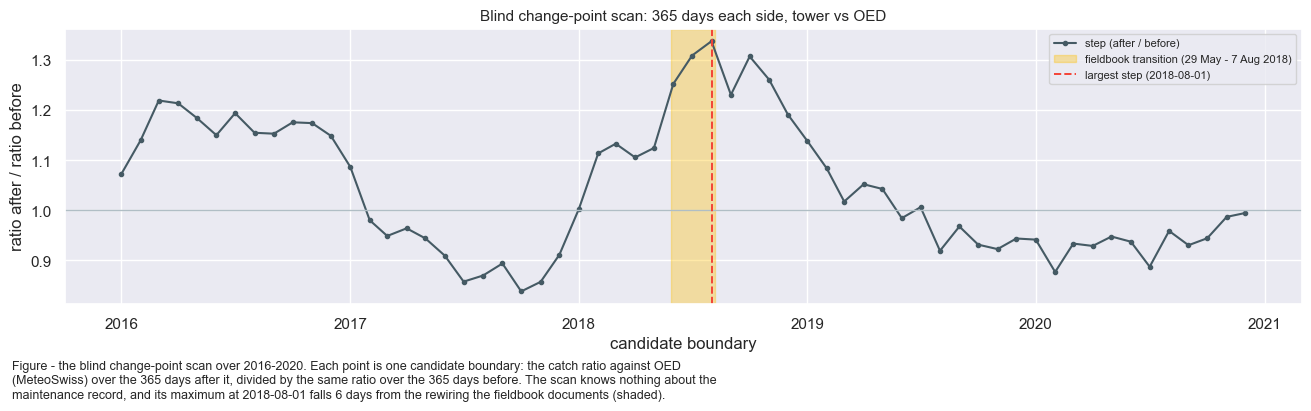

In [19]:
fig, ax = plt.subplots(figsize=(13, 4), dpi=100, layout='constrained')
ax.plot(scan.index, scan['step'], color='#455A64', marker='o', ms=3, label='step (after / before)')
ax.axhline(1, color='#B0BEC5', lw=1)
ax.axvspan(pd.Timestamp(ACQ_TRANSITION_START), pd.Timestamp(ACQ_TRANSITION_END),
           color='#FFC107', alpha=.35, label='fieldbook transition (29 May - 7 Aug 2018)')
ax.axvline(BREAK_FOUND, color='#F44336', ls='--', lw=1.4,
           label=f'largest step ({BREAK_FOUND.date()})')
ax.set_ylabel('ratio after / ratio before')
ax.set_xlabel('candidate boundary')
ax.set_title('Blind change-point scan: 365 days each side, tower vs OED', fontsize=11)
ax.legend(fontsize=8)
figcap(fig, f'the blind change-point scan over 2016-2020. Each point is one candidate boundary: '
            f'the catch ratio against {REFNAME} over the 365 days after it, divided by the same '
            f'ratio over the 365 days before. The scan knows nothing about the maintenance '
            f'record, and its maximum at {BREAK_FOUND.date()} falls {_offset_days} days from the '
            f'rewiring the fieldbook documents (shaded).')

### The break, quantified

Four ways of slicing the same comparison. The same-season control is the one that rules out
weather: the identical calendar window in the three preceding years sits at the old level, and only
2018 jumps.

In [20]:
def era_ratio(lo, hi, label):
    _s = cmp_day.loc[lo:hi]
    _ratio = float(_s['tower'].sum() / _s['ref'].sum())
    print(f"  {label:<44} days={len(_s):>5,}  tower={_s['tower'].sum():>7,.0f} mm  "
          f"ref={_s['ref'].sum():>7,.0f} mm  ratio={_ratio:.3f}")
    return _ratio


print("The four eras of the flag:")
R_EMPA = era_ratio(RECORD_START, '2018-05-28', '1  EMPA acquisition, 2004 - 28 May 2018')
R_TRANS = era_ratio(ACQ_TRANSITION_START, ACQ_TRANSITION_END, '2  transition, 29 May - 7 Aug 2018')
R_ETH18 = era_ratio('2018-08-08', '2018-12-31', '3  ETH logger, 8 Aug - 31 Dec 2018')
R_ETH = era_ratio('2019-01-01', RECORD_END, '4+5 ETH logger, 2019-2025')

print("\nSame calendar window (29 May - 31 Dec), year by year - the seasonality control:")
for _y in (2015, 2016, 2017, 2018, 2019, 2020):
    era_ratio(f'{_y}-05-29', f'{_y}-12-31', f'    {_y}')

print("\nThe two screenings of the ETH-logger era, separately - they must agree:")
_ = era_ratio('2019-01-01', '2019-12-31', '    4  mst screening (2019)')
_ = era_ratio('2020-01-01', RECORD_END, '    5  diive screening (2020-2025)')

print(f"\nStep across the acquisition change: {R_ETH / R_EMPA:.2f}x "
      f"({100 * (R_ETH / R_EMPA - 1):+.0f}%)")
assert R_ETH > R_EMPA, "the documented acquisition break is not in the data - re-check the sources"

The four eras of the flag:
  1  EMPA acquisition, 2004 - 28 May 2018      days=5,145  tower= 11,824 mm  ref= 14,897 mm  ratio=0.794
  2  transition, 29 May - 7 Aug 2018           days=   71  tower=    171 mm  ref=    203 mm  ratio=0.844
  3  ETH logger, 8 Aug - 31 Dec 2018           days=  145  tower=    379 mm  ref=    347 mm  ratio=1.091
  4+5 ETH logger, 2019-2025                    days=2,513  tower=  6,879 mm  ref=  6,602 mm  ratio=1.042

Same calendar window (29 May - 31 Dec), year by year - the seasonality control:
      2015                                     days=  214  tower=    308 mm  ref=    380 mm  ratio=0.811
      2016                                     days=  212  tower=    484 mm  ref=    536 mm  ratio=0.904
      2017                                     days=  216  tower=    488 mm  ref=    536 mm  ratio=0.911
      2018                                     days=  216  tower=    550 mm  ref=    550 mm  ratio=1.000
      2019                                     days=

In [21]:
# By season, split at the acquisition change rather than at the database's 2018/2019 boundary.
_old = cmp_day.loc[:pd.Timestamp(ACQ_TRANSITION_START) - pd.Timedelta(days=1)]
_new = cmp_day.loc['2018-08-08':]
_rows = []
for _name, _months in [('DJF', [12, 1, 2]), ('MAM', [3, 4, 5]),
                       ('JJA', [6, 7, 8]), ('SON', [9, 10, 11])]:
    _a = _old[_old.index.month.isin(_months)]
    _b = _new[_new.index.month.isin(_months)]
    _rows.append((_name, _a['tower'].sum() / _a['ref'].sum(), _b['tower'].sum() / _b['ref'].sum()))
_seas = pd.DataFrame(_rows, columns=['season', 'EMPA_era', 'ETH_era'])
_seas['step'] = _seas['ETH_era'] / _seas['EMPA_era']
tabcap('the catch ratio of each acquisition era by season, split at the acquisition change '
       'rather than at the calendar year. Both eras under-catch in winter, which is snow; what '
       'matters here is that the step between them is present in every season, which snow '
       'alone cannot produce.')
display(_seas.round(3).set_index('season'))
print("Both eras under-catch in winter - that is snow, and it is discussed below. The step is "
      "present in every season, which snow alone cannot produce.")

Table - the catch ratio of each acquisition era by season, split at the acquisition change rather
than at the calendar year. Both eras under-catch in winter, which is snow; what matters here is that
the step between them is present in every season, which snow alone cannot produce.



,EMPA_era,ETH_era,step
season,,,
DJF,0.566,0.860,1.519
MAM,0.832,1.105,1.329
JJA,0.898,1.168,1.300
SON,0.843,1.026,1.217


Both eras under-catch in winter - that is snow, and it is discussed below. The step is present in every season, which snow alone cannot produce.


### Is the deficit multiplicative?

The distinction matters for what the break *is*. A scaling or bucket-calibration difference is
multiplicative — it takes the same fraction off a drizzle day and a downpour. A gauge that misses
light precipitation (blocked funnel, evaporation, truncation) hits small amounts hardest and large
ones barely at all.

Stratified by the reference's own daily amount, the EMPA era sits near 0.7-0.8 in **every** class,
including the wettest. That is the multiplicative signature, and it is consistent with the
fieldbook's separate note that this gauge's scaling on the ETH logger was once out by a factor of
exactly ten.

(The `0.05-1 mm` class is the one to ignore in both eras: on trace days the two stations simply do
not see the same weather, so the ratio there is noise, not calibration.)

In [22]:
_bins = [0.05, 1, 2, 5, 10, 20, 1000]
_labels = ['0.05-1', '1-2', '2-5', '5-10', '10-20', '>20']
_tab = {}
for _lab, _sub in [('EMPA era', _old), ('ETH era', _new)]:
    _w = _sub[_sub['ref'] >= 0.05].copy()
    _w['bin'] = pd.cut(_w['ref'], bins=_bins, labels=_labels)
    _g = _w.groupby('bin', observed=True).agg(days=('ref', 'size'), tower=('tower', 'sum'),
                                              ref=('ref', 'sum'))
    _tab[_lab] = (_g['tower'] / _g['ref']).round(3)
    _tab[f'{_lab} (days)'] = _g['days']
tabcap('the catch ratio of each era stratified by how much rain the reference recorded that '
       'day, in mm. A gauge that misses light precipitation would be worst in the smallest '
       'class and near 1 in the largest; the EMPA-era deficit is instead close to the same in '
       'every class, which is the signature of a scaling difference. The 0.05-1 mm class is '
       'noise in both eras, because on trace days the two stations do not see the same weather.')
display(pd.DataFrame(_tab)[['EMPA era', 'EMPA era (days)', 'ETH era', 'ETH era (days)']])

_empa_heavy = float(_old[_old['ref'] > 5]['tower'].sum() / _old[_old['ref'] > 5]['ref'].sum())
print(f"EMPA era, days above 5 mm only: ratio {_empa_heavy:.3f} "
      f"(against {R_EMPA:.3f} over all days)")
print("A deficit that is the same on heavy days as on light ones is a scale problem, not a "
      "catching problem.")

Table - the catch ratio of each era stratified by how much rain the reference recorded that day, in
mm. A gauge that misses light precipitation would be worst in the smallest class and near 1 in the
largest; the EMPA-era deficit is instead close to the same in every class, which is the signature of
a scaling difference. The 0.05-1 mm class is noise in both eras, because on trace days the two
stations do not see the same weather.



,EMPA era,EMPA era (days),ETH era,ETH era (days)
bin,,,,
0.05-1,0.978,659,2.153,304
1-2,0.729,306,1.322,133
2-5,0.750,528,1.116,292
5-10,0.724,434,0.973,239
10-20,0.785,361,0.960,174
>20,0.837,140,0.934,59


EMPA era, days above 5 mm only: ratio 0.787 (against 0.794 over all days)
A deficit that is the same on heavy days as on light ones is a scale problem, not a catching problem.


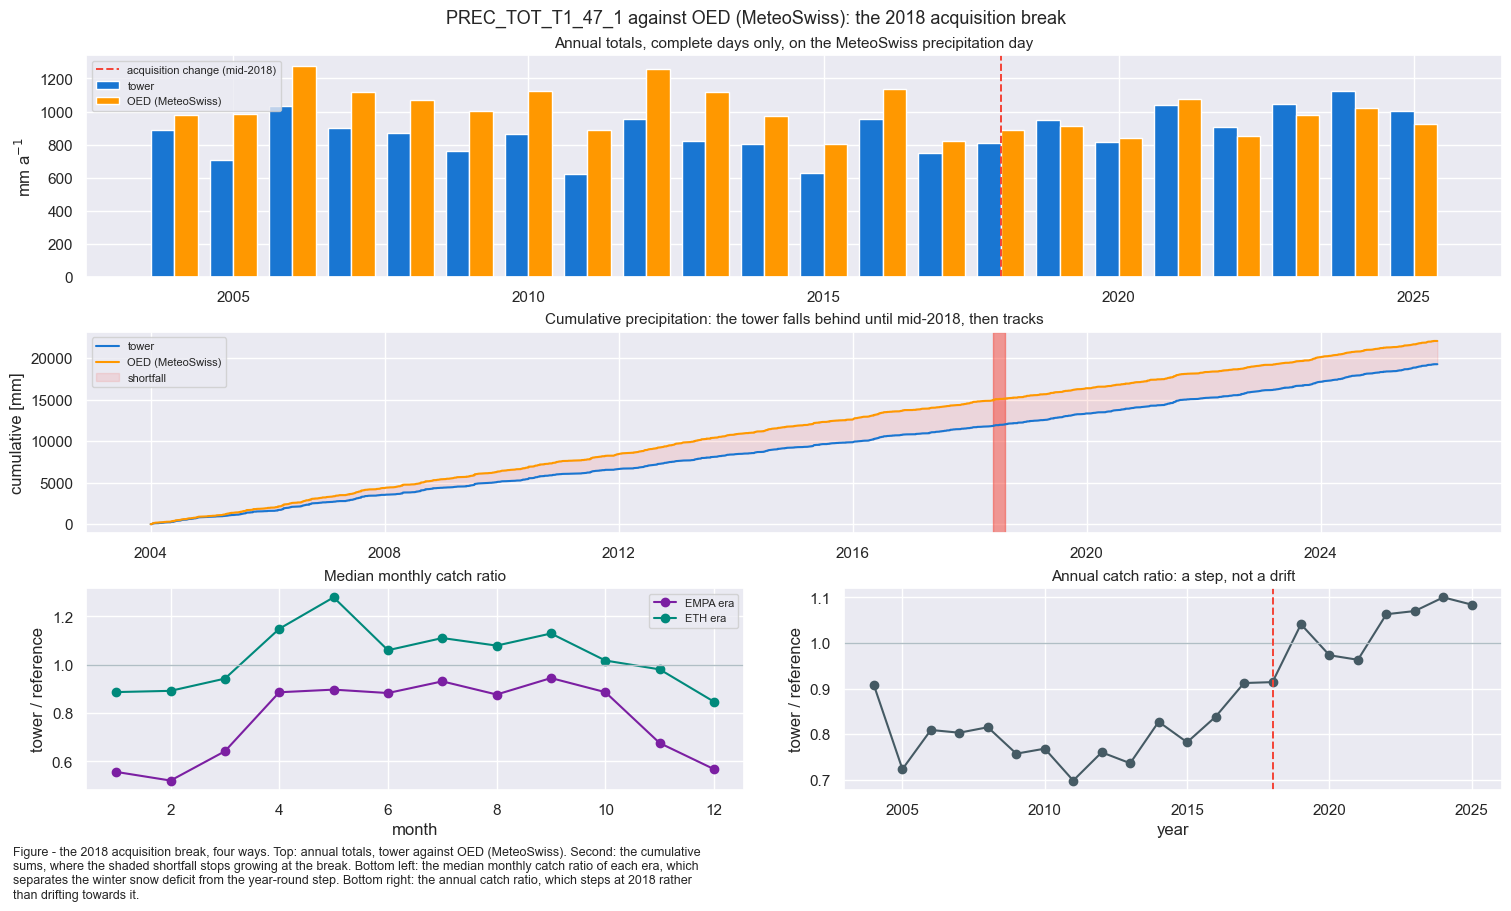

In [23]:
fig = plt.figure(figsize=(15, 9), dpi=100, layout='constrained')
gs = gridspec.GridSpec(3, 2, height_ratios=[1.1, 1, 1], figure=fig)
ax_ann = fig.add_subplot(gs[0, :])
ax_cum = fig.add_subplot(gs[1, :])
ax_mon = fig.add_subplot(gs[2, 0])
ax_rat = fig.add_subplot(gs[2, 1])
fig.suptitle(f'{TARGET} against {REFNAME}: the 2018 acquisition break', fontsize=13)

_w = 0.4
ax_ann.bar(_yr.index - _w / 2, _yr['tower'], width=_w, color='#1976D2', label='tower')
ax_ann.bar(_yr.index + _w / 2, _yr['ref'], width=_w, color='#FF9800', label=REFNAME)
ax_ann.axvline(2018, color='#F44336', ls='--', lw=1.4, label='acquisition change (mid-2018)')
ax_ann.set_ylabel('mm a$^{-1}$')
ax_ann.set_title('Annual totals, complete days only, on the MeteoSwiss precipitation day', fontsize=11)
ax_ann.legend(fontsize=8)

_cum = cmp_day[['tower', 'ref']].cumsum()
ax_cum.plot(_cum.index, _cum['tower'], color='#1976D2', label='tower')
ax_cum.plot(_cum.index, _cum['ref'], color='#FF9800', label=REFNAME)
ax_cum.fill_between(_cum.index, _cum['tower'], _cum['ref'], color='#F44336', alpha=.12,
                    label='shortfall')
ax_cum.axvspan(pd.Timestamp(ACQ_TRANSITION_START), pd.Timestamp(ACQ_TRANSITION_END),
               color='#F44336', alpha=.5)
ax_cum.set_ylabel('cumulative [mm]')
ax_cum.set_title('Cumulative precipitation: the tower falls behind until mid-2018, then tracks',
                 fontsize=11)
ax_cum.legend(fontsize=8, loc='upper left')

_m = cmp_day.groupby([cmp_day.index.year, cmp_day.index.month])[['tower', 'ref']].sum()
_m.index.names = ['year', 'month']
_m = _m[_m['ref'] > 10]
_m['ratio'] = _m['tower'] / _m['ref']
_m_dates = pd.to_datetime([f'{y}-{mo:02d}-01' for y, mo in _m.index])
for _mask, _lab, _c in [(_m_dates < pd.Timestamp(ACQ_TRANSITION_START), 'EMPA era', '#7B1FA2'),
                        (_m_dates >= pd.Timestamp('2018-08-08'), 'ETH era', '#00897B')]:
    _bym = _m[_mask].groupby(level='month')['ratio'].median()
    ax_mon.plot(_bym.index, _bym.values, marker='o', color=_c, label=_lab)
ax_mon.axhline(1, color='#B0BEC5', lw=1)
ax_mon.set_xlabel('month')
ax_mon.set_ylabel('tower / reference')
ax_mon.set_title('Median monthly catch ratio', fontsize=11)
ax_mon.legend(fontsize=8)

ax_rat.plot(_yr.index, _yr['ratio'], marker='o', color='#455A64')
ax_rat.axhline(1, color='#B0BEC5', lw=1)
ax_rat.axvline(2018, color='#F44336', ls='--', lw=1.4)
ax_rat.set_xlabel('year')
ax_rat.set_ylabel('tower / reference')
ax_rat.set_title('Annual catch ratio: a step, not a drift', fontsize=11)
figcap(fig, f'the 2018 acquisition break, four ways. Top: annual totals, tower against '
            f'{REFNAME}. Second: the cumulative sums, where the shaded shortfall stops growing '
            f'at the break. Bottom left: the median monthly catch ratio of each era, which '
            f'separates the winter snow deficit from the year-round step. Bottom right: the '
            f'annual catch ratio, which steps at 2018 rather than drifting towards it.')

### The factor-of-ten that is *not* in the product

The fieldbook records a second scaling problem on this gauge:

> **29.05.2019** — logger program updated. *"This update should solve the precipitation gauge
> problem. Measurements were too low by a factor of exactly 10."*

So for some period ending on 29 May 2019 the **logger** was recording a tenth of the true amount.
Whatever reached the database was evidently already corrected — but "evidently" is not a check, and
a factor of ten is exactly the kind of error this notebook must not ship. The cell below compares
the catch ratio either side of the fix and requires it to stay within a factor of two.

In [24]:
FIX_DATE = pd.Timestamp('2019-05-29')  # fieldbook: logger program corrected

_before = era_ratio('2019-01-01', FIX_DATE - pd.Timedelta(days=1), 'ratio before the 2019 fix')
_after = era_ratio(FIX_DATE + pd.Timedelta(days=1), '2019-12-31', 'ratio after the 2019 fix')
print(f"\nsmallest non-zero 30MIN value before the fix: "
      f"{float(prec.loc['2019-01-01':str(FIX_DATE.date()), TARGET].replace(0, np.nan).min()):.1f} mm")
print(f"smallest non-zero 30MIN value after the fix:  "
      f"{float(prec.loc[str(FIX_DATE.date()):'2019-12-31', TARGET].replace(0, np.nan).min()):.1f} mm")

assert 0.5 < _before / _after < 2.0, \
    (f"the catch ratio changes by {_before / _after:.2f}x across the 2019 logger fix - the "
     f"factor-of-ten error the fieldbook describes may have reached the database")
print(f"\nOK: ratio changes by {_after / _before:.2f}x across the fix, not 10x. The logger error "
      f"was corrected before the data reached the database.")

  ratio before the 2019 fix                    days=  148  tower=    345 mm  ref=    354 mm  ratio=0.975
  ratio after the 2019 fix                     days=  199  tower=    600 mm  ref=    557 mm  ratio=1.078

smallest non-zero 30MIN value before the fix: 0.1 mm
smallest non-zero 30MIN value after the fix:  0.1 mm

OK: ratio changes by 1.11x across the fix, not 10x. The logger error was corrected before the data reached the database.


### Was there a timestamp fault in August 2012?

The 17 Aug 2012 logger clock error shifts every variable recorded by the **tower logger** by
+15.5 h, and notebooks `01`-`05` all correct for it. `PREC` in 2012 is **not** on that logger — in
2012 the gauge is still on EMPA's acquisition, which is precisely why notebook `05` could use a
NABEL sensor to *diagnose* the tower fault in the first place. The fieldbook confirms the timing
from the other side: the gauge does not reach the ETH logger until 2018.

So the expectation is that no shift is needed, and this cell tests it instead of asserting it. OED
has no sub-daily data before Sep 2014, so the test is run on daily totals, where a 15.5 h shift
still moves rain across day boundaries and wrecks the agreement. It does exactly that: both
±15.5 h candidates land at a daily RMSE of 6.8-7.4 mm against 1.9 mm for the uncorrected series,
and their daily correlation collapses from 0.99 to 0.6.

The ±1 h rows are there to calibrate the test's own resolution, and they are the reason the
assertion below allows ±1 h rather than demanding an exact zero: on **daily** sums an hour of shift
is nearly invisible, so `-1 h` scoring a hair better than `0 h` on RMSE (1.77 against 1.90, while
`0 h` wins on correlation) is noise, not evidence. This test can resolve a 15 h error, not a 1 h
one — which is all it is asked to do.

In [25]:
_win = slice('2012-08-01', '2012-08-31')
_rows = []
for _shift_h in (-15.5, -1.0, 0.0, 1.0, 15.5):
    _s = prec[TARGET].copy()
    _s.index = _s.index + pd.Timedelta(hours=_shift_h)
    _s = _s.reindex(prec.index)
    _d = pd.DataFrame({'t': to_ms_precip_day(_s), 'r': ref_msday}).loc[_win].dropna()
    _rows.append((_shift_h, len(_d), float(_d['t'].corr(_d['r'])),
                  float(np.sqrt(((_d['t'] - _d['r']) ** 2).mean()))))

_shift_test = pd.DataFrame(_rows, columns=['shift_h', 'days', 'r_daily', 'RMSE_mm_per_day'])
tabcap('August 2012 tested for the tower-logger clock error that notebooks 01-05 correct. Each '
       'row shifts the tower series by the stated number of hours and scores it against the '
       'reference on daily totals. The two 15.5 h candidates destroy the agreement, so no shift '
       'is applied; the +/-1 h rows are there to show what this test can and cannot resolve.')
display(_shift_test.round(3))

_best = _shift_test.loc[_shift_test['RMSE_mm_per_day'].idxmin(), 'shift_h']
print(f"best shift by daily RMSE: {_best:+.1f} h")
assert abs(_best) <= 1.0, \
    f"August 2012 looks time-shifted by {_best} h - PREC may be on the tower logger after all"
print("No clock correction applied: in 2012 the gauge is on EMPA's acquisition, not the tower "
      "logger.")

Table - August 2012 tested for the tower-logger clock error that notebooks 01-05 correct. Each row
shifts the tower series by the stated number of hours and scores it against the reference on daily
totals. The two 15.5 h candidates destroy the agreement, so no shift is applied; the +/-1 h rows are
there to show what this test can and cannot resolve.



,shift_h,days,r_daily,RMSE_mm_per_day
0,-15.5,29,0.611,7.403
1,-1.0,28,0.980,1.765
2,0.0,28,0.989,1.898
3,1.0,28,0.960,2.851
4,15.5,29,0.565,6.782


best shift by daily RMSE: -1.0 h
No clock correction applied: in 2012 the gauge is on EMPA's acquisition, not the tower logger.


### A scan for periods where the gauge stopped catching

Rolling 7-day windows in which the reference recorded real rain and the tower recorded almost
none. That pattern — blocked funnel, frozen gauge, disconnected cable — is the one fault an
independent gauge 3.8 km away can genuinely resolve.

Over 22 years the scan raises **two** windows, and neither is a fault: February 2010 and January
2021 are both snow events, where the gauge misses the fall and releases part of it days later on
melt. Deleting them would remove the water that *did* register while leaving the larger amount that
never did, deepening the deficit rather than fixing it. **Nothing is removed in this notebook.**

In [26]:
WIN = '7D'
MIN_REF_MM = 25   # only judge windows where enough rain fell somewhere
DRY_FRAC = 0.2    # tower below this fraction of the reference -> suspect

_w = cmp_day[['tower', 'ref']].rolling(WIN).sum()
_sus = _w[(_w['ref'] > MIN_REF_MM) & (_w['tower'] < DRY_FRAC * _w['ref'])]

if len(_sus) == 0:
    print(f"No 7-day window with >{MIN_REF_MM} mm at {REFNAME} and <{DRY_FRAC:.0%} of it at the tower.")
else:
    _blocks = (_sus.index.to_series().diff() > pd.Timedelta('3D')).cumsum()
    print(f"{len(_sus)} suspect days in {_blocks.nunique()} block(s) - candidates, not verdicts:")
    for _g, _blk in _sus.groupby(_blocks):
        print(f"  window ending {_blk.index[0].date()} -> {_blk.index[-1].date()}: "
              f"tower {_blk['tower'].max():.1f} mm vs {REFNAME} {_blk['ref'].max():.1f} mm "
              f"(month {_blk.index[0].month:02d})")
    print("\nEach was checked by hand: all fall in winter months and are snow under-catch "
          "followed by melt-out, which is a bias of the measurement and is NOT removed.")

7 suspect days in 2 block(s) - candidates, not verdicts:
  window ending 2010-02-03 -> 2010-02-03: tower 3.7 mm vs OED (MeteoSwiss) 25.4 mm (month 02)
  window ending 2021-01-14 -> 2021-01-19: tower 10.4 mm vs OED (MeteoSwiss) 82.7 mm (month 01)

Each was checked by hand: all fall in winter months and are snow under-catch followed by melt-out, which is a bias of the measurement and is NOT removed.


***

## 📔 Gaps against the fieldbook

The product exports its gaps, so it is worth knowing both how much rain fell into them and whether
each one has a documented cause. The table below matches every gap of an hour or more against
fieldbook entries within ±2 days.

Most of the long early gaps predate the electronic fieldbook and have no entry. Of the recent ones,
all but one are explained; the exception is flagged in the closing notes.

In [27]:
_isna = prec[TARGET].isna()
_grp = (_isna != _isna.shift()).cumsum()
_runs = (prec[TARGET][_isna].groupby(_grp[_isna])
         .agg(start=lambda x: x.index[0], end=lambda x: x.index[-1], n='size'))
_runs['hours'] = (_runs['n'] * 0.5).round(1)
_runs = _runs[_runs['n'] >= 2].sort_values('n', ascending=False)

print(f"{len(_runs)} gaps of >= 1 h. Fieldbook entries within +/- 2 days:\n")
for _, _g in _runs.head(12).iterrows():
    _hits = fb[(fb['Date'] >= _g['start'] - pd.Timedelta(days=2))
               & (fb['Date'] <= _g['end'] + pd.Timedelta(days=2))]
    _hits = _hits.drop_duplicates(subset=['Date', 'text'])
    print(f"--- {_g['start']} -> {_g['end']}  ({_g['hours']} h)")
    if _hits.empty:
        print("      (no fieldbook entry within +/- 2 days)")
    for _, _h in _hits.head(3).iterrows():
        print(f"      {_h['Date'].date()} [{_h['Event Tag']}] {_h['text'][:130]}")

53 gaps of >= 1 h. Fieldbook entries within +/- 2 days:

--- 2008-05-11 00:15:00 -> 2008-06-04 14:45:00  (591.0 h)
      (no fieldbook entry within +/- 2 days)
--- 2019-11-04 04:45:00 -> 2019-11-19 23:45:00  (379.5 h)
      2019-11-18 [CHECK] Sonic problem started
      2019-11-06 [CHECK] Since we couldn't connect to the site any more I had to check the devices, power sources and network on site. We got no infomratio
      2019-11-05 [ARRIVED_LEFT] Arrived and left the site
--- 2009-04-27 00:15:00 -> 2009-04-29 23:45:00  (72.0 h)
      (no fieldbook entry within +/- 2 days)
--- 2009-05-02 00:15:00 -> 2009-05-04 13:45:00  (62.0 h)
      (no fieldbook entry within +/- 2 days)
--- 2005-05-21 00:15:00 -> 2005-05-23 00:15:00  (48.5 h)
      (no fieldbook entry within +/- 2 days)
--- 2005-01-12 12:45:00 -> 2005-01-14 12:15:00  (48.0 h)
      (no fieldbook entry within +/- 2 days)
--- 2013-06-09 01:15:00 -> 2013-06-10 23:15:00  (46.5 h)
      (no fieldbook entry within +/- 2 days)
--- 2010-09

In [28]:
_n_all = to_ms_precip_day(prec[TARGET].notna().astype(float), min_records=1)
_none = _n_all[_n_all == 0].index
_part = _n_all[(_n_all > 0) & (_n_all < 48)].index

print(f"days with no tower record at all:  {len(_none):>4}  "
      f"({REFNAME} recorded {float(ref_msday.reindex(_none).sum()):.1f} mm on them)")
print(f"days only partially covered:       {len(_part):>4}  "
      f"({REFNAME} recorded {float(ref_msday.reindex(_part).sum()):.1f} mm on them)")

_worst = ref_msday.reindex(_none.union(_part)).dropna().sort_values(ascending=False).head(8)
print(f"\nThe wettest days the tower could not cover, by {REFNAME}:")
tabcap(f'the wettest days the tower could not cover, by the reference, over days it did not '
       f'record at all or recorded only partly. These are the days the gaps cost most.')
display(_worst.round(1).rename(f'{REFNAME} [mm]'))

days with no tower record at all:    50  (OED (MeteoSwiss) recorded 153.4 mm on them)
days only partially covered:        103  (OED (MeteoSwiss) recorded 236.1 mm on them)

The wettest days the tower could not cover, by OED (MeteoSwiss):
Table - the wettest days the tower could not cover, by the reference, over days it did not record at
all or recorded only partly. These are the days the gaps cost most.



TIMESTAMP_MIDDLE
2013-06-09    32.6
2005-05-22    21.8
2010-08-02    20.4
2008-09-02    18.2
2007-06-07    16.0
2019-11-04    14.2
2013-10-15    13.0
2008-05-29    12.8
Name: OED (MeteoSwiss) [mm], dtype: float64

***

## 🩹 Filling the gaps from the reference

The tower record is 99.18% complete, but the missing 0.82% is not evenly spread: it includes a
16-day outage in November 2019 and a 25-day one in May/June 2008. Left as `NaN`, those holes
silently bias every monthly and annual sum that anyone builds from this file downwards — and
"downwards" is the direction a naive consumer will not notice, because a rain total that is too low
still looks like a plausible rain total.

OED is the only candidate filler: it is the nearest gauge, it is independent of everything that can
fail at the tower, and it is already on our time axis. But it is 3.8 km away and 260 m lower, so
whether it can actually stand in for the tower is a question to be **answered**, not assumed. This
section answers it in four steps: what is fillable at all, whether the two gauges are concurrent,
which of nine candidate methods survives a blind test, and how good the winner really is.

### Step 1 — what can be filled at all

OED has **no sub-daily data before 10 Sep 2014**. Before that date the only reference is a daily
total on the MeteoSwiss precipitation day, and spreading a daily total across 48 half-hours would
invent a sub-daily structure that nobody measured. So the pre-2014 gaps are simply not fillable
from this source, and they stay `NaN`.

That split is stark, and it decides the shape of the whole exercise: the fillable gaps are almost
entirely in the ETH-logger era.

In [29]:
# The reference on the product's own axis. TIMESTAMP_END -> TIMESTAMP_MID, as in the checks above.
ref_fill = ref_30min.copy()
ref_fill.index = ref_fill.index - pd.Timedelta(minutes=15)
ref_fill = ref_fill.reindex(prec.index)

# The acquisition era of a gap: taken from the nearest surrounding record, because a gap has no
# flag of its own and the fill factor has to belong to the chain the gap sits inside.
era_at = prec[FLAGCOL].replace(0, np.nan).ffill().bfill().astype(int)
is_eth_era = era_at.isin(HOMOGENEOUS_FLAGS)

gap = prec[TARGET].isna()
fillable = gap & ref_fill.notna()

print(f"gaps in the tower record:            {int(gap.sum()):>6,} "
      f"({100 * gap.mean():.2f}% of the record)")
print(f"  fillable (30MIN reference exists): {int(fillable.sum()):>6,}")
print(f"  not fillable:                      {int((gap & ~fillable).sum()):>6,}")
print(f"     of which before the reference starts ({ref_fill.first_valid_index()}): "
      f"{int((gap & (prec.index < ref_fill.first_valid_index())).sum()):,}")

_inv = pd.DataFrame({'era': np.where(is_eth_era, 'ETH logger', 'EMPA / transition'),
                     'fillable': fillable})[gap]
tabcap('every gap in the tower record, by acquisition era and by whether a 30MIN reference '
       'value exists to fill it. The reference has no sub-daily data before 10 Sep 2014, which '
       'is why the unfillable gaps are almost all in the early era.')
display(_inv.groupby(['era', 'fillable']).size().unstack(fill_value=0)
        .rename(columns={False: 'not fillable', True: 'fillable'}))
print("Every fillable gap but 25 sits in the ETH-logger era, so this is in practice a repair of "
      "the modern part of the record.")

gaps in the tower record:             3,156 (0.82% of the record)
  fillable (30MIN reference exists):    932
  not fillable:                       2,224
     of which before the reference starts (2014-09-10 07:15:00): 2,224
Table - every gap in the tower record, by acquisition era and by whether a 30MIN reference value
exists to fill it. The reference has no sub-daily data before 10 Sep 2014, which is why the
unfillable gaps are almost all in the early era.



fillable,not fillable,fillable
era,,
EMPA / transition,2224,25
ETH logger,0,907


Every fillable gap but 25 sits in the ETH-logger era, so this is in practice a repair of the modern part of the record.


### Step 2 — are the two gauges concurrent, or lagged?

Before scaling anything, the fill has to be put on the right half-hour. Two gauges 3.8 km apart see
the same weather system at slightly different times, and if that offset were comparable to the
sampling interval the fill would systematically misplace rain.

The cross-correlation over ±3 h answers it. A parabola through the three points around the peak
gives the sub-sample position of the maximum, which is the honest way to read a lag that is finer
than the sampling step.

In [30]:
_lags = range(-6, 7)
_corr = {}
for _off in _lags:
    _j = pd.concat([prec[TARGET].rename('t'), ref_fill.shift(_off).rename('r')], axis=1).dropna()
    _corr[_off] = float(_j['t'].corr(_j['r']))

# Sub-sample peak position from a parabola through offsets -1, 0, +1.
_ym1, _y0, _yp1 = _corr[-1], _corr[0], _corr[1]
_denom = _ym1 - 2 * _y0 + _yp1
SUBSAMPLE_LAG_MIN = 30 * 0.5 * (_ym1 - _yp1) / _denom
print(f"peak at offset 0 (corr {_y0:.4f}); neighbours {_ym1:.4f} / {_yp1:.4f}")
print(f"parabolic peak position: {SUBSAMPLE_LAG_MIN:+.1f} min "
      f"-> the tower lags OED by about {abs(SUBSAMPLE_LAG_MIN):.0f} min")
print(f"  sanity: 3.8 km at a typical frontal speed of ~15 m/s is ~4 min, and OED lies NNW, "
      f"upwind of the usual approach")
print(f"  the offset is {abs(SUBSAMPLE_LAG_MIN) / 30:.2f} of one sampling interval, so it cannot "
      f"be corrected by shifting whole half-hours")

# Per season, the best whole-step offset must still be 0, or a seasonal shift would be needed.
_by_season = {}
for _name, _months in [('DJF', [12, 1, 2]), ('MAM', [3, 4, 5]),
                       ('JJA', [6, 7, 8]), ('SON', [9, 10, 11])]:
    _sc = {}
    for _off in range(-4, 5):
        _j = pd.concat([prec[TARGET].rename('t'), ref_fill.shift(_off).rename('r')],
                       axis=1).dropna()
        _j = _j[_j.index.month.isin(_months)]
        _sc[_off] = float(_j['t'].corr(_j['r']))
    _by_season[_name] = _sc
    print(f"  {_name}: best offset {max(_sc, key=_sc.get):+d}  (corr at 0: {_sc[0]:.4f})")

assert all(max(_sc, key=_sc.get) == 0 for _sc in _by_season.values()), \
    "a season prefers a shifted reference - the fill would misplace rain in that season"
print("\nOK: zero lag wins in every season. No shift is applied, and the benchmark below tests a "
      "shifted variant anyway to confirm that shifting only hurts.")

peak at offset 0 (corr 0.6785); neighbours 0.3872 / 0.4731
parabolic peak position: +2.6 min -> the tower lags OED by about 3 min
  sanity: 3.8 km at a typical frontal speed of ~15 m/s is ~4 min, and OED lies NNW, upwind of the usual approach
  the offset is 0.09 of one sampling interval, so it cannot be corrected by shifting whole half-hours


  DJF: best offset +0  (corr at 0: 0.6509)


  MAM: best offset +0  (corr at 0: 0.6568)


  JJA: best offset +0  (corr at 0: 0.6655)


  SON: best offset +0  (corr at 0: 0.7673)

OK: zero lag wins in every season. No shift is applied, and the benchmark below tests a shifted variant anyway to confirm that shifting only hurts.


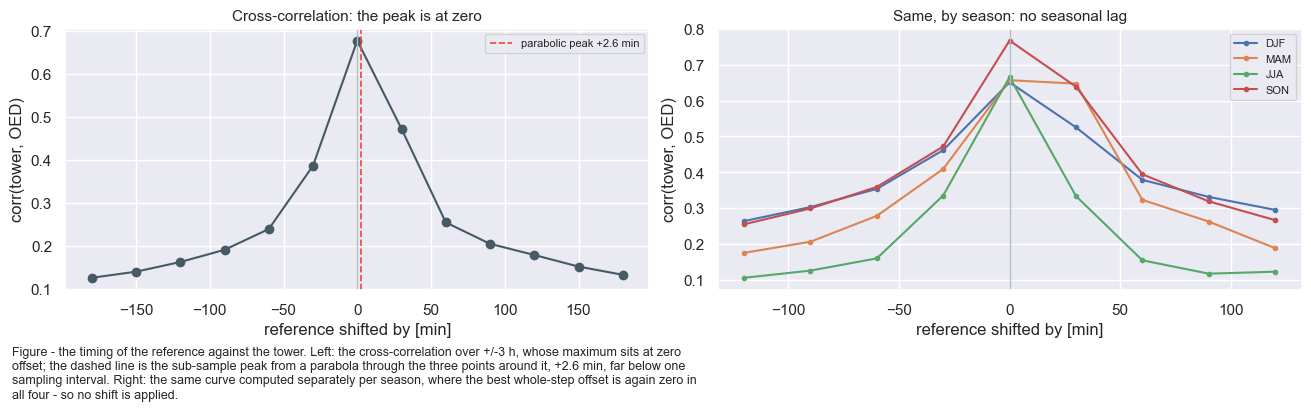

In [31]:
fig, axs = plt.subplots(ncols=2, figsize=(13, 4), dpi=100, layout='constrained')
axs[0].plot([o * 30 for o in _lags], [_corr[o] for o in _lags], marker='o', color='#455A64')
axs[0].axvline(0, color='#B0BEC5', lw=1)
axs[0].axvline(SUBSAMPLE_LAG_MIN, color='#F44336', ls='--', lw=1.2,
               label=f'parabolic peak {SUBSAMPLE_LAG_MIN:+.1f} min')
axs[0].set_xlabel('reference shifted by [min]')
axs[0].set_ylabel('corr(tower, OED)')
axs[0].set_title('Cross-correlation: the peak is at zero', fontsize=11)
axs[0].legend(fontsize=8)

for _name, _sc in _by_season.items():
    axs[1].plot([o * 30 for o in _sc], [_sc[o] for o in _sc], marker='o', ms=3, label=_name)
axs[1].axvline(0, color='#B0BEC5', lw=1)
axs[1].set_xlabel('reference shifted by [min]')
axs[1].set_ylabel('corr(tower, OED)')
axs[1].set_title('Same, by season: no seasonal lag', fontsize=11)
axs[1].legend(fontsize=8)
figcap(fig, f'the timing of the reference against the tower. Left: the cross-correlation over '
            f'+/-3 h, whose maximum sits at zero offset; the dashed line is the sub-sample peak '
            f'from a parabola through the three points around it, {SUBSAMPLE_LAG_MIN:+.1f} min, '
            f'far below one sampling interval. Right: the same curve computed separately per '
            f'season, where the best whole-step offset is again zero in all four - so no shift '
            f'is applied.')

### Step 3 — a blind test of nine candidate methods

The only way to know whether a fill is any good is to fill something whose answer is already known.
So: take the ETH era where **both** series are present, blank out a window of the tower, fill it
with each candidate, and score the result against the truth that was hidden. Repeat with windows
placed at random, at six lengths from one hour to the 15.8 days of the real November 2019 gap.

The candidates, from useless to elaborate:

| method | idea |
|---|---|
| `zero` | leave the gap as no rain — what happens if a consumer does `fillna(0)` |
| `clim_monthly` | that month's long-term mean rate — a fill that uses no reference at all |
| `ref_raw` | copy OED as it is |
| `ref_k_global` | OED × one factor for the whole era |
| `ref_k_seasonal` | OED × a factor per season |
| `ref_k_monthly` | OED × a factor per calendar month |
| `ref_k_local30d` | OED × a factor fitted on the ±30 days around *this* gap |
| `ref_k_global_lag+1` | OED shifted by one half-hour — the control for step 2 |
| `ref_daily_uniform` | OED's daily total spread flat over the day — tests whether OED's sub-daily shape carries any information |

All factors are ratio estimators, `k = Σtower / ΣOED`, which is the right estimator when what you
care about is the total rather than the average of ratios. `ref_k_local30d` excludes the synthetic
gap itself from its own fit, so it does not get to peek at the answer.

Scores: **bias** of the summed rainfall (the thing that matters for a total), **RMSE** and
**correlation** at 30 min (sub-daily fidelity), **the error on each gap's own total** in mm and as
a median relative error, and **POD/FAR** for wet half-hours (does it put rain in the right places,
and how often does it invent rain that never fell).

In [32]:
%%time

# Benchmark domain: the ETH era where both series exist. The factors are fitted here too, so the
# numbers below describe the fill as it will actually be applied.
bench = pd.DataFrame({'t': prec[TARGET], 'r': ref_fill})[is_eth_era].dropna()
K_GLOBAL = float(bench['t'].sum() / bench['r'].sum())
_g = bench.groupby(bench.index.month)[['t', 'r']].sum()
K_MONTHLY = (_g['t'] / _g['r']).where(_g['r'] >= FILL_MIN_REF_MM, K_GLOBAL)
SEASON_OF_MONTH = {12: 'DJF', 1: 'DJF', 2: 'DJF', 3: 'MAM', 4: 'MAM', 5: 'MAM',
                   6: 'JJA', 7: 'JJA', 8: 'JJA', 9: 'SON', 10: 'SON', 11: 'SON'}
_gs = bench.groupby(bench.index.month.map(SEASON_OF_MONTH))[['t', 'r']].sum()
K_SEASONAL = _gs['t'] / _gs['r']
CLIM_MONTHLY = bench.groupby(bench.index.month)['t'].mean()   # mm per half-hour

print(f"benchmark domain: {len(bench):,} half-hours, "
      f"{bench.index[0].date()} -> {bench.index[-1].date()}")
print(f"global factor k = {K_GLOBAL:.4f}")


def _local_k(idx):
    """Ratio fitted on the +/- BENCH_LOCAL_WINDOW_DAYS around the gap, excluding the gap itself."""
    _w = pd.Timedelta(days=BENCH_LOCAL_WINDOW_DAYS)
    w = bench.loc[idx[0] - _w:idx[-1] + _w].drop(index=idx, errors='ignore')
    if float(w['r'].sum()) < 20:      # too little rain nearby to fit a ratio
        return K_GLOBAL
    return float(w['t'].sum() / w['r'].sum())


def fill_candidates(idx):
    """Every candidate fill for the timestamps in *idx*, as {name: Series}."""
    r = ref_fill.reindex(idx).fillna(0.0)
    return {
        'zero': pd.Series(0.0, index=idx),
        'clim_monthly': pd.Series(CLIM_MONTHLY.reindex(idx.month).values, index=idx),
        'ref_raw': r,
        'ref_k_global': r * K_GLOBAL,
        'ref_k_seasonal': r * K_SEASONAL.reindex(idx.month.map(SEASON_OF_MONTH)).values,
        'ref_k_monthly': r * K_MONTHLY.reindex(idx.month).values,
        'ref_k_local30d': r * _local_k(idx),
        'ref_k_global_lag+1': ref_fill.shift(1).reindex(idx).fillna(0.0) * K_GLOBAL,
        'ref_daily_uniform': r.groupby(idx.normalize()).transform('mean') * K_GLOBAL,
    }


_rng = np.random.default_rng(BENCH_SEED)
_names = list(fill_candidates(bench.index[:2]).keys())
_out = []
for _L, _N in BENCH_SPECS:
    _acc = {n: {'n': 0, 'ts': 0.0, 'fs': 0.0, 'sse': 0.0, 'err': [], 'rel': [],
                'tp': 0, 'fp': 0, 'fn': 0, 'tv': [], 'fv': []} for n in _names}
    for _s in _rng.integers(0, len(bench) - _L, size=_N):
        _idx = bench.index[_s:_s + _L]
        _truth = bench['t'].reindex(_idx)
        for _name, _f in fill_candidates(_idx).items():
            _a = _acc[_name]
            _a['n'] += len(_idx); _a['ts'] += float(_truth.sum()); _a['fs'] += float(_f.sum())
            _a['sse'] += float(((_f - _truth) ** 2).sum())
            _a['err'].append(abs(float(_f.sum()) - float(_truth.sum())))
            if float(_truth.sum()) > 1:
                _a['rel'].append(abs(float(_f.sum()) / float(_truth.sum()) - 1))
            _tw, _fw = _truth > 0.05, _f > 0.05
            _a['tp'] += int((_tw & _fw).sum()); _a['fp'] += int((~_tw & _fw).sum())
            _a['fn'] += int((_tw & ~_fw).sum())
            _a['tv'].append(_truth.values); _a['fv'].append(_f.values)
    for _name, _a in _acc.items():
        _tv, _fv = np.concatenate(_a['tv']), np.concatenate(_a['fv'])
        _out.append({'gap_h': _L * 0.5, 'method': _name,
                     'bias_%': 100 * (_a['fs'] / _a['ts'] - 1),
                     'rmse_30min': np.sqrt(_a['sse'] / _a['n']),
                     'corr_30min': np.corrcoef(_tv, _fv)[0, 1] if _fv.std() > 0 else np.nan,
                     'gaptotal_MAE_mm': np.mean(_a['err']),
                     'gaptotal_medRelErr_%': 100 * np.median(_a['rel']) if _a['rel'] else np.nan,
                     'POD': _a['tp'] / max(_a['tp'] + _a['fn'], 1),
                     'FAR': _a['fp'] / max(_a['tp'] + _a['fp'], 1)})
benchmark = pd.DataFrame(_out)
print(f"\n{sum(n for _, n in BENCH_SPECS):,} synthetic gaps evaluated against "
      f"{len(_names)} methods")

benchmark domain: 128,575 half-hours, 2018-08-08 -> 2025-12-31
global factor k = 1.0457



15,100 synthetic gaps evaluated against 9 methods
CPU times: total: 2min
Wall time: 2min 4s


In [33]:
# One table per gap length, and the caption is built from the loop variables rather than
# written out per table: a length added to BENCH_SPECS then cannot arrive without one.
for _L in sorted(benchmark['gap_h'].unique()):
    _n = dict((l * 0.5, n) for l, n in BENCH_SPECS)[_L]
    tabcap(f'the nine candidate fills scored against synthetic gaps of {_L} h '
           f'({_L / 24:.2f} days), {_n:,} of them placed at random in the era where both '
           f'series are present. Compare methods down a column within this table only: each '
           f'gap length is a different random draw of windows, so its overall bias also '
           f'reflects which storms happened to fall inside them.')
    display(benchmark[benchmark['gap_h'] == _L].drop(columns='gap_h')
            .set_index('method').round(3))

Table - the nine candidate fills scored against synthetic gaps of 1.0 h (0.04 days), 4,000 of them
placed at random in the era where both series are present. Compare methods down a column within this
table only: each gap length is a different random draw of windows, so its overall bias also reflects
which storms happened to fall inside them.



,bias_%,rmse_30min,corr_30min,gaptotal_MAE_mm,gaptotal_medRelErr_%,POD,FAR
method,,,,,,,
zero,-100.000,0.345,NaN,0.107,100.000,0.000,0.000
clim_monthly,6.802,0.341,0.045,0.193,93.665,0.639,0.897
ref_raw,-6.924,0.325,0.508,0.072,37.500,0.711,0.218
ref_k_global,-2.675,0.332,0.508,0.073,37.261,0.711,0.218
ref_k_seasonal,-2.452,0.349,0.493,0.072,35.768,0.711,0.218
ref_k_monthly,-2.187,0.351,0.490,0.072,34.846,0.711,0.218
ref_k_local30d,-1.762,0.348,0.500,0.072,34.667,0.711,0.218
ref_k_global_lag+1,1.239,0.339,0.521,0.090,52.470,0.610,0.300
ref_daily_uniform,-2.675,0.294,0.552,0.073,37.261,0.789,0.312


Table - the nine candidate fills scored against synthetic gaps of 3.0 h (0.12 days), 4,000 of them
placed at random in the era where both series are present. Compare methods down a column within this
table only: each gap length is a different random draw of windows, so its overall bias also reflects
which storms happened to fall inside them.



,bias_%,rmse_30min,corr_30min,gaptotal_MAE_mm,gaptotal_medRelErr_%,POD,FAR
method,,,,,,,
zero,-100.000,0.286,NaN,0.297,100.000,0.000,0.000
clim_monthly,14.288,0.281,0.024,0.532,87.258,0.595,0.909
ref_raw,-4.505,0.229,0.645,0.163,30.662,0.694,0.254
ref_k_global,-0.145,0.233,0.645,0.167,29.819,0.694,0.254
ref_k_seasonal,-1.295,0.236,0.647,0.161,28.912,0.694,0.254
ref_k_monthly,-1.597,0.238,0.645,0.160,29.309,0.694,0.254
ref_k_local30d,-0.822,0.246,0.638,0.164,31.545,0.694,0.254
ref_k_global_lag+1,1.067,0.263,0.542,0.187,38.597,0.625,0.336
ref_daily_uniform,-0.145,0.240,0.532,0.167,29.819,0.784,0.463


Table - the nine candidate fills scored against synthetic gaps of 12.0 h (0.50 days), 3,000 of them
placed at random in the era where both series are present. Compare methods down a column within this
table only: each gap length is a different random draw of windows, so its overall bias also reflects
which storms happened to fall inside them.



...

,bias_%,rmse_30min,corr_30min,gaptotal_MAE_mm,gaptotal_medRelErr_%,POD,FAR
method,,,,,,,
zero,-100.000,0.361,NaN,2.595,100.000,0.000,0.000
clim_monthly,4.313,0.356,0.040,3.534,62.000,0.630,0.900
ref_raw,-4.368,0.294,0.616,1.014,28.882,0.704,0.245
ref_k_global,-0.002,0.298,0.616,1.044,28.413,0.704,0.245
ref_k_seasonal,-0.941,0.303,0.617,1.012,28.535,0.704,0.245
ref_k_monthly,-0.762,0.305,0.617,0.997,26.988,0.704,0.245
ref_k_local30d,0.659,0.319,0.600,1.051,29.364,0.704,0.245
ref_k_global_lag+1,0.057,0.370,0.403,1.050,27.736,0.637,0.318
ref_daily_uniform,-0.002,0.334,0.349,1.044,28.413,0.813,0.650


Table - the nine candidate fills scored against synthetic gaps of 48.0 h (2.00 days), 1,500 of them
placed at random in the era where both series are present. Compare methods down a column within this
table only: each gap length is a different random draw of windows, so its overall bias also reflects
which storms happened to fall inside them.



,bias_%,rmse_30min,corr_30min,gaptotal_MAE_mm,gaptotal_medRelErr_%,POD,FAR
method,,,,,,,
zero,-100.000,0.381,NaN,5.549,100.000,0.000,0.000
clim_monthly,-2.395,0.376,0.050,6.178,59.129,0.632,0.894
ref_raw,-3.859,0.293,0.663,1.803,26.533,0.716,0.226
ref_k_global,0.530,0.297,0.663,1.861,26.802,0.716,0.226
ref_k_seasonal,1.011,0.303,0.666,1.769,24.809,0.716,0.226
ref_k_monthly,0.660,0.303,0.667,1.741,23.276,0.716,0.226
ref_k_local30d,2.113,0.325,0.647,1.933,26.789,0.716,0.226
ref_k_global_lag+1,0.632,0.400,0.387,1.866,25.731,0.646,0.302
ref_daily_uniform,0.530,0.359,0.309,1.861,26.802,0.830,0.684


Table - the nine candidate fills scored against synthetic gaps of 379.5 h (15.81 days), 600 of them
placed at random in the era where both series are present. Compare methods down a column within this
table only: each gap length is a different random draw of windows, so its overall bias also reflects
which storms happened to fall inside them.



,bias_%,rmse_30min,corr_30min,gaptotal_MAE_mm,gaptotal_medRelErr_%,POD,FAR
method,,,,,,,
zero,-100.000,0.353,NaN,42.428,100.000,0.000,0.000
clim_monthly,0.030,0.349,0.040,21.564,41.589,0.572,0.902
ref_raw,-4.256,0.264,0.687,7.529,15.337,0.703,0.236
ref_k_global,0.115,0.268,0.687,7.713,15.960,0.703,0.236
ref_k_seasonal,-0.062,0.274,0.688,7.324,15.056,0.703,0.236
ref_k_monthly,-0.387,0.273,0.689,6.846,14.202,0.703,0.236
ref_k_local30d,1.349,0.284,0.678,8.482,17.446,0.703,0.236
ref_k_global_lag+1,0.109,0.356,0.446,7.722,16.286,0.640,0.305
ref_daily_uniform,0.115,0.333,0.302,7.713,15.960,0.805,0.700


#### What the numbers say

- **`zero` is indefensible.** −100% bias by construction, and on a 15.8-day gap it loses 42 mm of
  rain on average. This is the fill a consumer applies by accident, and it is the reason this
  section exists.
- **`clim_monthly` is worse than useless for timing.** It gets the long-run total roughly right
  (that is all a climatology can do) but invents rain in ~90% of the half-hours it marks wet, and
  on long gaps its total error is still three times the reference methods'. A reference gauge beats
  a climatology decisively.
- **Scaling matters.** `ref_raw` carries a persistent negative bias, because the tower catches ~4.6%
  more than OED in this era. Any of the fitted factors removes it, leaving a residual bias within
  ±2.2% at every gap length.
- **Monthly beats seasonal beats global — on totals.** `ref_k_monthly` has the lowest median
  relative error on the gap total at every length of 12 h and above (14.2% against 16.0% for
  `ref_k_global` on the longest gaps) and the lowest absolute error in mm. At 1-3 h the three are
  within half a point of each other, which is noise.
- **Local fitting fails.** `ref_k_local30d` is worse than the global factor at every length except
  the very shortest, and clearly worst on long gaps (17.4% against 14.2%): a ±30-day window rarely
  contains enough rain to estimate a ratio, so it fits noise. This was the most promising-sounding
  candidate and the benchmark rejects it.
- **Shifting hurts, as step 2 predicted.** `ref_k_global_lag+1` keeps the bias (a shift cannot
  change a total) but drops the 30-min correlation from 0.69 to 0.45. This is the control that
  confirms the lag analysis.
- **OED's sub-daily shape is real information.** `ref_daily_uniform` has *identical* totals to
  `ref_k_global` by construction, but correlation collapses from 0.69 to 0.30 and the false-alarm
  rate triples to 0.70. Filling at 30 min is therefore worth doing rather than filling a daily
  total.

**Chosen: `ref_k_monthly`.** Best on the metric that matters most for precipitation — the total
over the gap — bias within ±2.2% at every length, and within about 0.01 mm of the best 30-min RMSE.
Its twelve fitted parameters are each estimated from seven years of that month.

::: {.callout-note title="Reading the table honestly"}
Compare methods **down a column within one row**. Do not compare bias *across* rows: each row is a
different random draw of windows, so its overall bias also reflects which storms happened to fall
inside them. The robust discriminator is the gap-total error at the longer lengths, where the
sample is large enough that the draw stops mattering.
:::

Note the left panel: the fill gets RELATIVELY better as the gap gets longer, because errors on individual showers average out over a long window. The worst case is a short gap, not a long one.


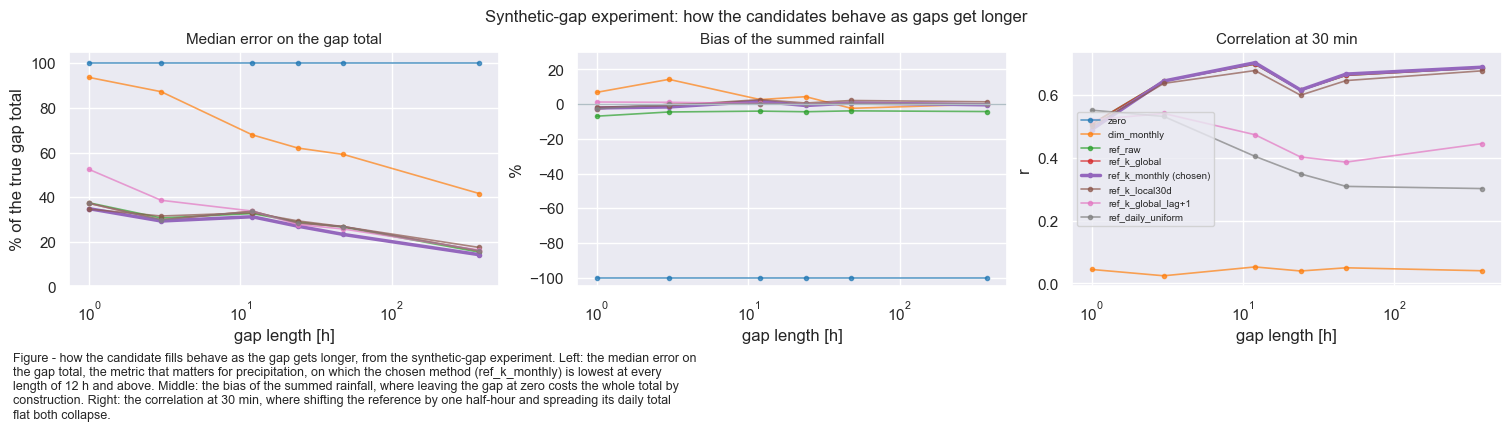

In [34]:
_best = 'ref_k_monthly'
fig, axs = plt.subplots(ncols=3, figsize=(15, 4.2), dpi=100, layout='constrained')
fig.suptitle('Synthetic-gap experiment: how the candidates behave as gaps get longer', fontsize=12)
_show = ['zero', 'clim_monthly', 'ref_raw', 'ref_k_global', 'ref_k_monthly', 'ref_k_local30d',
         'ref_k_global_lag+1', 'ref_daily_uniform']
_cmap = plt.get_cmap('tab10')
for _i, _m in enumerate(_show):
    _d = benchmark[benchmark['method'] == _m].sort_values('gap_h')
    _kw = dict(color=_cmap(_i % 10), marker='o', ms=3,
               lw=2.5 if _m == _best else 1.2, alpha=1.0 if _m == _best else .7,
               label=_m + (' (chosen)' if _m == _best else ''))
    axs[0].plot(_d['gap_h'], _d['gaptotal_medRelErr_%'], **_kw)
    axs[1].plot(_d['gap_h'], _d['bias_%'], **_kw)
    axs[2].plot(_d['gap_h'], _d['corr_30min'], **_kw)
for _ax, _t, _yl in [(axs[0], 'Median error on the gap total', '% of the true gap total'),
                     (axs[1], 'Bias of the summed rainfall', '%'),
                     (axs[2], 'Correlation at 30 min', 'r')]:
    _ax.set_xscale('log')
    _ax.set_xlabel('gap length [h]')
    _ax.set_ylabel(_yl)
    _ax.set_title(_t, fontsize=11)
axs[0].set_ylim(0, 105)
axs[1].set_ylim(-105, 30)
axs[1].axhline(0, color='#B0BEC5', lw=1)
axs[2].legend(fontsize=7, loc='center left')
print("Note the left panel: the fill gets RELATIVELY better as the gap gets longer, because "
      "errors on individual showers average out over a long window. The worst case is a short "
      "gap, not a long one.")
figcap(fig, f'how the candidate fills behave as the gap gets longer, from the synthetic-gap '
            f'experiment. Left: the median error on the gap total, the metric that matters for '
            f'precipitation, on which the chosen method ({_best}) is lowest at every length of '
            f'12 h and above. Middle: the bias of the summed rainfall, where leaving the gap at '
            f'zero costs the whole total by construction. Right: the correlation at 30 min, '
            f'where shifting the reference by one half-hour and spreading its daily total flat '
            f'both collapse.')

### The monthly factors, and why they are not just a fudge

The twelve numbers below are the whole of the chosen method, so it is worth looking at what they
are. They are not arbitrary: they trace the two physical differences between a ridge-top gauge at
690 m and a valley gauge at 428 m.

- **Winter below 1** — the tower under-catches snow (documented at length in the closing notes), so
  it records less than OED in DJF.
- **Summer above 1** — convective cells develop over the ridge; the tower gets rain that OED misses.

Fitted separately for each acquisition era, because the eras differ by a factor of 1.3 and using
the ETH factors on an EMPA-era gap would inject that step into the fill. The EMPA-era factors rest
on the shorter 2014-2018 overlap and are only ever applied to 25 records.

In [35]:
# Fit the factors per era on the concurrent records. The benchmark above used the ETH set.
FILL_FACTORS = {}
for _label, _mask in [('EMPA / transition', ~is_eth_era), ('ETH logger', is_eth_era)]:
    _d = pd.DataFrame({'t': prec[TARGET], 'r': ref_fill})[_mask].dropna()
    _kg = float(_d['t'].sum() / _d['r'].sum())
    _sums = _d.groupby(_d.index.month)[['t', 'r']].sum()
    _km = (_sums['t'] / _sums['r']).where(_sums['r'] >= FILL_MIN_REF_MM, _kg)
    FILL_FACTORS[_label] = {'global': _kg, 'monthly': _km, 'ref_mm': _sums['r']}
    print(f"{_label:<20} n={len(_d):>7,} concurrent half-hours "
          f"({_d.index[0].date()} -> {_d.index[-1].date()}), global k={_kg:.3f}")

_ftab = pd.DataFrame({lbl: FILL_FACTORS[lbl]['monthly'] for lbl in FILL_FACTORS}).round(3)
_ftab.index.name = 'month'
tabcap('the monthly factors k = tower / reference used to rescale a reference value before it '
       'fills a gap, fitted separately per acquisition era on the concurrent records. Below 1 '
       'in winter, because the tower under-catches snow; above 1 in summer, because convective '
       'cells develop over the ridge. The early-era column rests on the shorter 2014-2018 '
       'overlap and is only ever applied to 25 records.')
display(_ftab)

assert (FILL_FACTORS['ETH logger']['ref_mm'] >= FILL_MIN_REF_MM).all(), \
    "an ETH-era month has too little reference rain to fit a factor - check FILL_MIN_REF_MM"
assert _ftab.min().min() > 0.4 and _ftab.max().max() < 2.0, \
    f"a monthly factor is implausible: {_ftab.to_dict()}"

EMPA / transition    n= 68,505 concurrent half-hours (2014-09-10 -> 2018-08-07), global k=0.836
ETH logger           n=128,575 concurrent half-hours (2018-08-08 -> 2025-12-31), global k=1.046
Table - the monthly factors k = tower / reference used to rescale a reference value before it fills
a gap, fitted separately per acquisition era on the concurrent records. Below 1 in winter, because
the tower under-catches snow; above 1 in summer, because convective cells develop over the ridge.
The early-era column rests on the shorter 2014-2018 overlap and is only ever applied to 25 records.



,EMPA / transition,ETH logger
month,,
1,0.625,0.842
2,0.622,0.837
3,0.695,0.909
4,1.036,1.100
5,0.920,1.231
6,0.918,1.114
7,1.070,1.225
8,0.944,1.184
9,1.137,1.121


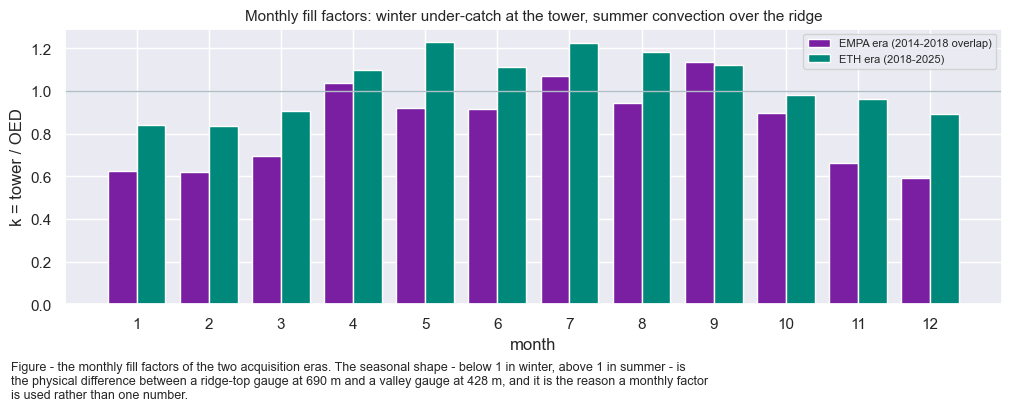

In [36]:
fig, ax = plt.subplots(figsize=(10, 4), dpi=100, layout='constrained')
_x = np.arange(1, 13)
ax.bar(_x - 0.2, FILL_FACTORS['EMPA / transition']['monthly'].reindex(_x), width=0.4,
       color='#7B1FA2', label='EMPA era (2014-2018 overlap)')
ax.bar(_x + 0.2, FILL_FACTORS['ETH logger']['monthly'].reindex(_x), width=0.4,
       color='#00897B', label='ETH era (2018-2025)')
ax.axhline(1, color='#B0BEC5', lw=1)
ax.set_xticks(_x)
ax.set_xlabel('month')
ax.set_ylabel('k = tower / OED')
ax.set_title('Monthly fill factors: winter under-catch at the tower, summer convection over the '
             'ridge', fontsize=11)
ax.legend(fontsize=8)
figcap(fig, 'the monthly fill factors of the two acquisition eras. The seasonal shape - below 1 '
            'in winter, above 1 in summer - is the physical difference between a ridge-top gauge '
            'at 690 m and a valley gauge at 428 m, and it is the reason a monthly factor is used '
            'rather than one number.')

### Step 4 — apply the fill

The chosen method, applied only where the tower has a gap and the reference has a value. Nothing
else in the series is touched: a measured record keeps its measured value, whatever OED says about
it.

In [37]:
k_at = pd.Series(np.where(is_eth_era,
                          FILL_FACTORS['ETH logger']['monthly'].reindex(prec.index.month).values,
                          FILL_FACTORS['EMPA / transition']['monthly']
                          .reindex(prec.index.month).values),
                 index=prec.index)
fill_values = (ref_fill * k_at / FILL_ROUND_TO).round() * FILL_ROUND_TO  # onto the bucket grid

FILLCOL = f'FLAG_{TARGET}_ISFILLED'
prec[FILLCOL] = np.where(prec[TARGET].notna(), FILL_MEASURED,
                         np.where(fillable, FILL_FROM_REF, FILL_IMPOSSIBLE))
_measured_before = int(prec[TARGET].notna().sum())
_total_before = float(prec[TARGET].sum())
prec.loc[fillable, TARGET] = fill_values[fillable]

print(f"filled {int(fillable.sum()):,} records, adding "
      f"{float(prec[TARGET].sum()) - _total_before:.1f} mm")
print(f"  of them wet (> 0 mm): {int((prec.loc[fillable, TARGET] > 0).sum()):,}")
print(f"still missing:          {int(prec[TARGET].isna().sum()):,} "
      f"(all before {ref_fill.first_valid_index().date()})")
print(f"completeness: {100 * _measured_before / len(prec):.2f}% measured "
      f"-> {100 * prec[TARGET].notna().mean():.2f}% with values")

# The fill must not have touched anything that was measured.
assert int((prec[FILLCOL] == FILL_MEASURED).sum()) == _measured_before, \
    "the number of measured records changed while filling"
assert (prec.loc[prec[FILLCOL] == FILL_IMPOSSIBLE, TARGET].isna()).all(), \
    "a record flagged unfillable carries a value"
assert (prec.loc[prec[FILLCOL] == FILL_FROM_REF, TARGET].notna()).all(), \
    "a record flagged filled carries no value"
assert (prec.loc[prec[FILLCOL] == FILL_FROM_REF, TARGET] >= 0).all(), "a fill is negative"
print("\nFill applied and flagged.")

filled 932 records, adding 56.4 mm
  of them wet (> 0 mm): 96
still missing:          2,224 (all before 2014-09-10)
completeness: 99.18% measured -> 99.42% with values

Fill applied and flagged.


### What the fill actually did

Two views. The **November 2019 outage** is the one that matters — 16 days, 33 mm of rain at OED,
and the single largest hole in the modern record. The annual table shows how little else changes:
2019 and 2024 move, and nothing before 2014 can.

In [38]:
_yearly = pd.DataFrame({
    'measured_mm': prec[TARGET].where(prec[FILLCOL] == FILL_MEASURED)
                   .groupby(prec.index.year).sum().round(1),
    'filled_mm': prec[TARGET].where(prec[FILLCOL] == FILL_FROM_REF)
                 .groupby(prec.index.year).sum().round(1),
    'n_filled': (prec[FILLCOL] == FILL_FROM_REF).groupby(prec.index.year).sum(),
    'n_still_missing': (prec[FILLCOL] == FILL_IMPOSSIBLE).groupby(prec.index.year).sum(),
})
_yearly['total_mm'] = (_yearly['measured_mm'] + _yearly['filled_mm']).round(1)
tabcap('what the fill changed, by year. Only years that gained filled records or still carry '
       'unfillable ones are listed. 2019 is the year that matters: its 16-day November outage '
       'is the largest hole in the modern record.')
display(_yearly[(_yearly['n_filled'] > 0) | (_yearly['n_still_missing'] > 0)])

Table - what the fill changed, by year. Only years that gained filled records or still carry
unfillable ones are listed. 2019 is the year that matters: its 16-day November outage is the largest
hole in the modern record.



,measured_mm,filled_mm,n_filled,n_still_missing,total_mm
TIMESTAMP_MIDDLE,,,,,
2004,898.9,0.0,0,59,898.9
2005,708.3,0.0,0,272,708.3
2007,913.7,0.0,0,5,913.7
2008,871.7,0.0,0,1196,871.7
2009,771.3,0.0,0,288,771.3
2010,888.1,0.0,0,175,888.1
2011,624.3,0.0,0,19,624.3
2012,965.6,0.0,0,108,965.6
2013,843.1,0.0,0,97,843.1


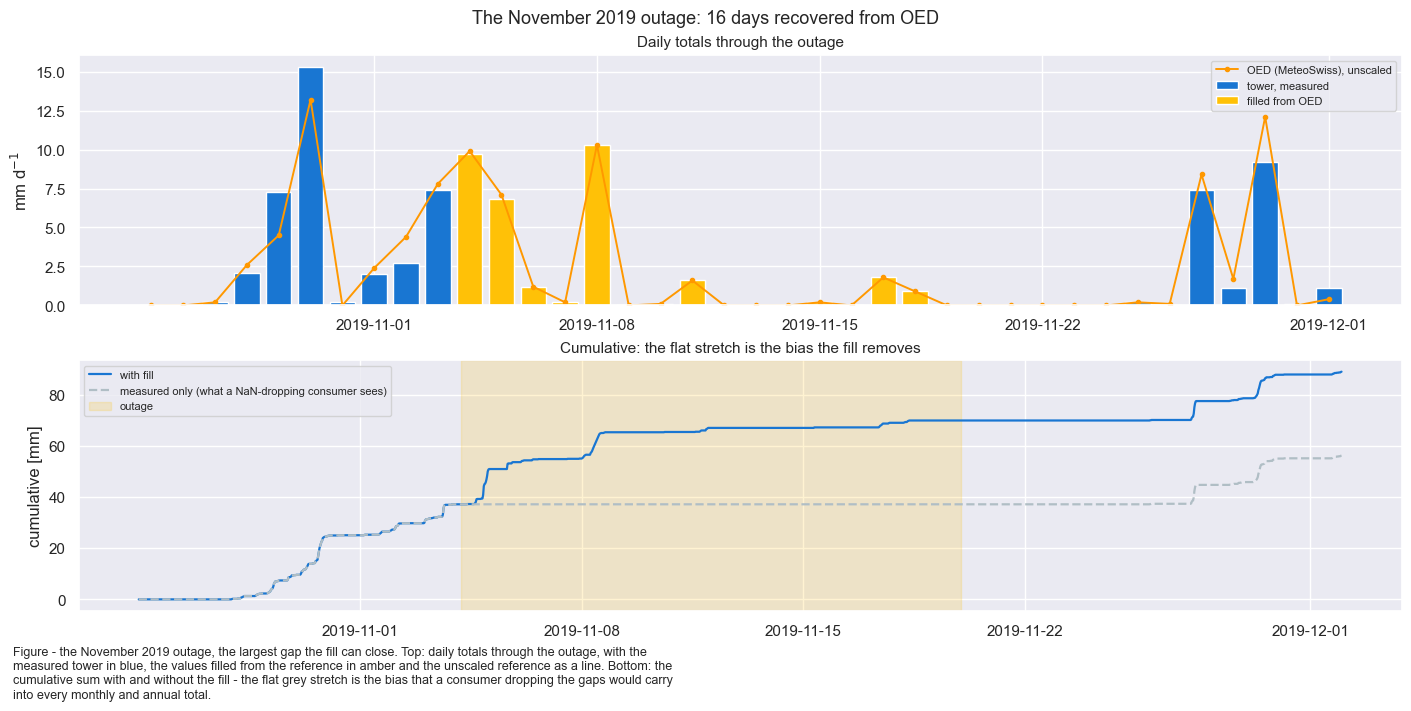

In [39]:
fig, axs = plt.subplots(nrows=2, figsize=(14, 7), dpi=100, layout='constrained')
fig.suptitle('The November 2019 outage: 16 days recovered from OED', fontsize=13)
_w = slice('2019-10-25', '2019-12-01')
_isfill = prec[FILLCOL].loc[_w] == FILL_FROM_REF

_d = pd.DataFrame({'tower': prec[TARGET].loc[_w].where(~_isfill),
                   'filled': prec[TARGET].loc[_w].where(_isfill),
                   'OED': ref_fill.loc[_w]}).resample('D').sum(min_count=1)
axs[0].bar(_d.index, _d['tower'], width=.8, color='#1976D2', label='tower, measured')
axs[0].bar(_d.index, _d['filled'], width=.8, color='#FFC107', label='filled from OED')
axs[0].plot(_d.index, _d['OED'], color='#FF9800', lw=1.4, marker='o', ms=3,
            label=f'{REFNAME}, unscaled')
axs[0].set_ylabel('mm d$^{-1}$')
axs[0].set_title('Daily totals through the outage', fontsize=11)
axs[0].legend(fontsize=8)

_c = pd.DataFrame({'with fill': prec[TARGET].loc[_w].fillna(0).cumsum(),
                   'measured only': prec[TARGET].loc[_w].where(~_isfill).fillna(0).cumsum()})
axs[1].plot(_c.index, _c['with fill'], color='#1976D2', lw=1.6, label='with fill')
axs[1].plot(_c.index, _c['measured only'], color='#B0BEC5', lw=1.6, ls='--',
            label='measured only (what a NaN-dropping consumer sees)')
axs[1].axvspan(prec.loc[_w].index[_isfill][0], prec.loc[_w].index[_isfill][-1],
               color='#FFC107', alpha=.18, label='outage')
axs[1].set_ylabel('cumulative [mm]')
axs[1].set_title('Cumulative: the flat stretch is the bias the fill removes', fontsize=11)
axs[1].legend(fontsize=8, loc='upper left')
figcap(fig, 'the November 2019 outage, the largest gap the fill can close. Top: daily totals '
            'through the outage, with the measured tower in blue, the values filled from the '
            'reference in amber and the unscaled reference as a line. Bottom: the cumulative sum '
            'with and without the fill - the flat grey stretch is the bias that a consumer '
            'dropping the gaps would carry into every monthly and annual total.')

### How good is this, honestly

Good enough for **totals**, not good enough for **timing**. Both halves of that sentence are
measured, not asserted:

| question | answer from the benchmark |
|---|---|
| Does a filled monthly or annual total come out right? | Yes — bias within ±2.2% at every gap length. |
| Does a *single* filled gap come out right? | Roughly. Median error on the gap total is ~14% for a 16-day gap, ~23% for a 2-day gap, ~35% for a 1-hour gap. |
| Is a filled half-hour trustworthy? | **No.** Correlation 0.69, and of the half-hours the fill marks wet, ~24% were dry at the tower (FAR), while ~30% of genuinely wet half-hours are missed (POD 0.70). |
| Is it better than leaving the gap? | For any sum, decisively. `fillna(0)` loses 42 mm on a gap like November 2019. |

The counterintuitive result worth remembering is that **short gaps are the unreliable ones**. A
one-hour fill is a coin toss on a single shower; a two-week fill averages over many systems and
lands within ~14%. That is the opposite of the intuition carried over from gap-filling a continuous
variable such as temperature — and it is lucky, because the gaps that actually needed filling here
are the long ones.

::: {.callout-warning title="What a filled value is not"}
It is not a tower measurement, and it is not a model estimate either — it is **another gauge's
measurement, 3.8 km away, rescaled by a monthly factor**. Anything that needs genuine tower
measurements only (sub-daily event analysis, intensity statistics, throughfall partitioning) must
filter on `FLAG_PREC_TOT_T1_47_1_ISFILLED == 0`. Anything that needs unbiased sums should keep the
fills.
:::

***

## ⚖️ Which era is right, and homogenising the other one

The break is measured and flagged, but that leaves the question a user actually has: **is the early
record too low, or is the late record too high?** OED alone cannot say. When the tower and one
reference disagree, either could have moved.

Thirteen references can. `10_REFERENCE/MeteoSwiss_REGIONAL_PREC_2004-2025.ipynb` collects every
MeteoSwiss precipitation station within 21 km with full 2004-2025 coverage. If the tower steps
against all of them at once, the tower moved — and the ensemble's elevation gradient additionally
says what a gauge at the tower's 690 m *should* record.

In [40]:
regional = pd.read_parquet(REFPATH_REGIONAL)
reg_stations = pd.read_csv(REFPATH_REGIONAL_STATIONS)
print(f"regional ensemble: {regional.shape[1]} stations, {regional.shape[0]:,} days "
      f"({regional.index[0].date()} -> {regional.index[-1].date()})")
tabcap('the regional ensemble: every MeteoSwiss precipitation station within 21 km that covers '
       'the whole period. One reference can date a change; only an ensemble can say which of '
       'two gauges moved. The spread of elevations additionally gives the elevation-precipitation '
       'gradient used below.')
display(reg_stations[['station_abbr', 'station_name', 'alt_m', 'dist_km', 'mean_annual_mm']])

# Tower on the MeteoSwiss precipitation day, MEASURED records only and complete days only: a filled
# or partial day would compare a reconstruction against the network.
_meas_only = prec[TARGET].where(prec[FILLCOL] == FILL_MEASURED)
tower_msday_meas = to_ms_precip_day(_meas_only)
tower_msday_meas = tower_msday_meas[to_ms_precip_day(_meas_only.notna().astype(float),
                                                     min_records=1) == 48]

# The acquisition era of each day, from the surrounding flags.
_era_end = era_at.copy()
_era_end.index = _era_end.index + pd.Timedelta(minutes=15)
era_msday = _era_end.shift(freq=f'-{_day_start_local}h').resample('D').median()

epoch = pd.Series(np.where(era_msday <= FLAG_TRANSITION - 1, 'EMPA',
                           np.where(era_msday >= FLAG_ETH_NABELREC, 'ETH', 'transition')),
                  index=era_msday.index)
print(f"\ncomplete measured tower days: {len(tower_msday_meas):,}")
print(epoch.reindex(tower_msday_meas.index).value_counts().to_string())

regional ensemble: 13 stations, 8,036 days (2004-01-01 -> 2025-12-31)
Table - the regional ensemble: every MeteoSwiss precipitation station within 21 km that covers the
whole period. One reference can date a change; only an ensemble can say which of two gauges moved.
The spread of elevations additionally gives the elevation-precipitation gradient used below.



,station_abbr,station_name,alt_m,dist_km,mean_annual_mm
0,OED,Ehrendingen,428.0,3.8,1022
1,DIT,Dietikon,384.0,7.8,1042
2,KAI,"Kaiserstuhl, AG",361.0,10.9,992
3,PSI,Würenlingen / PSI,334.0,12.2,1000
4,REH,Zürich / Affoltern,444.0,12.8,1001
5,KLO,Zürich / Kloten,426.0,12.9,992
6,BUE,Bülach,403.0,13.1,961
7,BEZ,Beznau,326.0,13.2,945
8,WAG,Waldegg,545.0,14.6,1111
9,OPF,Opfikon,424.0,15.4,1096



complete measured tower days: 7,884
EMPA          5146
ETH           2667
transition      71


### Station by station: the tower steps against every one of them

For each station separately, the tower/station ratio in each era, on days both cover. A station
that had itself changed in 2018 would stand out as the one exception; none does.

In [41]:
_rows = []
for _col in regional.columns:
    _ab = _col.split('_')[1]
    for _era in ('EMPA', 'ETH'):
        _days = (tower_msday_meas.index
                 .intersection(epoch[epoch == _era].index)
                 .intersection(regional[_col].dropna().index))
        if len(_days) < 300:
            continue
        _rows.append({'abbr': _ab, 'era': _era, 'days': len(_days),
                      'tower_mm': float(tower_msday_meas.reindex(_days).sum()),
                      'stn_mm': float(regional[_col].reindex(_days).sum())})
_r = pd.DataFrame(_rows)
_r['ratio'] = _r['tower_mm'] / _r['stn_mm']
by_station = (_r.pivot(index='abbr', columns='era', values='ratio')
              .join(reg_stations.set_index('station_abbr')[['station_name', 'alt_m', 'dist_km']])
              .sort_values('dist_km'))
by_station['step'] = by_station['ETH'] / by_station['EMPA']
tabcap('the tower against each ensemble station separately, in each acquisition era, on days '
       'both cover. A station that had itself changed in 2018 would stand out as the one '
       'exception; none does, so the change is the tower\'s.')
display(by_station[['station_name', 'alt_m', 'dist_km', 'EMPA', 'ETH', 'step']].round(3))

print(f"EMPA era: tower/station ratio {by_station['EMPA'].min():.3f}-{by_station['EMPA'].max():.3f}"
      f"  (median {by_station['EMPA'].median():.3f})")
print(f"ETH  era: tower/station ratio {by_station['ETH'].min():.3f}-{by_station['ETH'].max():.3f}"
      f"  (median {by_station['ETH'].median():.3f})")

assert (by_station['EMPA'] < by_station['ETH']).all(), \
    "the tower does not step against every station - the break may not be the tower's"
assert (by_station['EMPA'] < 0.95).all(), \
    "the EMPA era is not low against every station - re-examine the conclusion below"
print("\nThe tower reads low against EVERY station in the EMPA era and agrees with the network in "
      "the ETH era. Thirteen independent gauges did not change together in mid-2018; the tower did.")

Table - the tower against each ensemble station separately, in each acquisition era, on days both
cover. A station that had itself changed in 2018 would stand out as the one exception; none does, so
the change is the tower's.



,station_name,alt_m,dist_km,EMPA,ETH,step
abbr,,,,,,
OED,Ehrendingen,428.0,3.8,0.794,1.046,1.318
DIT,Dietikon,384.0,7.8,0.795,0.966,1.215
KAI,"Kaiserstuhl, AG",361.0,10.9,0.824,1.022,1.240
PSI,Würenlingen / PSI,334.0,12.2,0.838,0.984,1.174
REH,Zürich / Affoltern,444.0,12.8,0.839,0.984,1.174
KLO,Zürich / Kloten,426.0,12.9,0.841,1.004,1.194
BUE,Bülach,403.0,13.1,0.871,1.026,1.178
BEZ,Beznau,326.0,13.2,0.905,1.002,1.107
WAG,Waldegg,545.0,14.6,0.742,0.916,1.234


EMPA era: tower/station ratio 0.735-0.905  (median 0.825)
ETH  era: tower/station ratio 0.909-1.046  (median 0.984)

The tower reads low against EVERY station in the EMPA era and agrees with the network in the ETH era. Thirteen independent gauges did not change together in mid-2018; the tower did.


### How low is low? The elevation expectation

The stations span 326-604 m and their mean annual totals rise with elevation. The tower sits at
690 m — **above all of them** — so a gauge there should record *more* than any station in the
ensemble, not less.

In [42]:
_ann_stn = regional.resample('YS').sum(min_count=350).mean()
_alt_stn = reg_stations.set_index('station_abbr')['alt_m']
_alt_stn.index = [f'PREC_{a}_MS_DAILY' for a in _alt_stn.index]
_alt_stn = _alt_stn.reindex(_ann_stn.index).astype(float)

ELEV_SLOPE, ELEV_ICEPT = np.polyfit(_alt_stn.values, _ann_stn.values, 1)
ELEV_EXPECT = ELEV_SLOPE * SITE_ALT_M + ELEV_ICEPT
_scatter = float(np.sqrt(((_ann_stn.values
                           - (ELEV_SLOPE * _alt_stn.values + ELEV_ICEPT)) ** 2).mean()))
print(f"elevation gradient {ELEV_SLOPE * 100:+.1f} mm per 100 m "
      f"(r = {np.corrcoef(_alt_stn.values, _ann_stn.values)[0, 1]:.2f}, scatter {_scatter:.0f} mm)")
print(f"expectation at the tower ({SITE_ALT_M:.0f} m): {ELEV_EXPECT:.0f} mm/a\n")

_cov = prec[TARGET].notna().groupby(prec.index.year).mean()
_full_years = _cov[_cov > 0.98].index
_ann_tower = prec[TARGET].loc[prec.index.year.isin(_full_years)]
_ann_tower = _ann_tower.groupby(_ann_tower.index.year).sum()
MEAN_EMPA = float(_ann_tower[_ann_tower.index <= 2017].mean())
MEAN_ETH = float(_ann_tower[_ann_tower.index >= 2019].mean())
for _lbl, _v in [('EMPA era 2004-2017', MEAN_EMPA), ('ETH era 2019-2025', MEAN_ETH)]:
    print(f"  tower mean annual, {_lbl}: {_v:,.0f} mm  "
          f"({100 * (_v / ELEV_EXPECT - 1):+.0f}% vs the elevation expectation)")
print("\nA ridge-top gauge ~10% under the regional expectation is ordinary wind-induced "
      "under-catch.\nA quarter under it, while thirteen valley stations agree with each other, "
      "is not available physically.")
print("=> The ETH era is the more correct one; the EMPA era is biased LOW.")

elevation gradient +35.2 mm per 100 m (r = 0.61, scatter 38 mm)
expectation at the tower (690 m): 1112 mm/a

  tower mean annual, EMPA era 2004-2017: 830 mm  (-25% vs the elevation expectation)
  tower mean annual, ETH era 2019-2025: 1,003 mm  (-10% vs the elevation expectation)

A ridge-top gauge ~10% under the regional expectation is ordinary wind-induced under-catch.
A quarter under it, while thirteen valley stations agree with each other, is not available physically.
=> The ETH era is the more correct one; the EMPA era is biased LOW.


### The regional index, and whether one factor is enough

The per-station ratios above each carry that station's own noise. Averaging the ensemble into a
single **regional index** (the mean over days where every station reports) removes most of it and
gives the cleanest estimate of the step.

Two things have to be true before a multiplicative correction is defensible:

1. **The EMPA-era ratio must be stable**, not drifting. A drifting gauge needs a time-varying
   correction, or none at all.
2. **The step must be describable.** It is not constant through the year — the monthly factors run
   from ~1.07 to ~1.44 — so the choice is between one factor and twelve. Bootstrapping each month
   shows how much of that spread is real; the two choices give the *same* annual total either way,
   and differ only within the year.

In [43]:
reg_index = regional.dropna(how='any').mean(axis=1)
cmp_reg = pd.DataFrame({'tower': tower_msday_meas, 'index': reg_index,
                        'epoch': epoch}).dropna()
cmp_reg = cmp_reg[cmp_reg['epoch'] != 'transition']
print(f"days with the full ensemble and a complete tower day: {len(cmp_reg):,}")


def _k(sub):
    return float(sub['tower'].sum() / sub['index'].sum())


K_EMPA_REG = _k(cmp_reg[cmp_reg['epoch'] == 'EMPA'])
K_ETH_REG = _k(cmp_reg[cmp_reg['epoch'] == 'ETH'])
STEP_SINGLE = K_ETH_REG / K_EMPA_REG
print(f"tower / regional index:  EMPA {K_EMPA_REG:.4f}   ETH {K_ETH_REG:.4f}   "
      f"step {STEP_SINGLE:.4f}")

# 1) Stability of the EMPA era.
_e = cmp_reg[cmp_reg['epoch'] == 'EMPA']
_yr_ratio = _e.groupby(_e.index.year).apply(_k)
_yr_ratio = _yr_ratio[_yr_ratio.index <= 2017]
_slope_yr = np.polyfit(_yr_ratio.index, _yr_ratio.values, 1)[0]
print(f"\nEMPA-era ratio by year: mean {_yr_ratio.mean():.3f}, sd {_yr_ratio.std():.3f}, "
      f"trend {_slope_yr * 10:+.3f}/decade "
      f"(r = {np.corrcoef(_yr_ratio.index, _yr_ratio.values)[0, 1]:+.2f})")
assert abs(_slope_yr * 10) < 0.08, \
    ("the EMPA-era ratio drifts; a constant multiplicative correction is not the right form")
print("No meaningful drift, so a multiplicative correction is the right form.")

days with the full ensemble and a complete tower day: 7,679
tower / regional index:  EMPA 0.8160   ETH 0.9834   step 1.2051

EMPA-era ratio by year: mean 0.815, sd 0.046, trend -0.043/decade (r = -0.40)
No meaningful drift, so a multiplicative correction is the right form.


In [44]:
# 2) One factor or twelve? Bootstrap each month's step over days.
_rng = np.random.default_rng(BENCH_SEED)
_rows = []
for _m in range(1, 13):
    _s = cmp_reg[cmp_reg.index.month == _m]
    _a, _b = _s[_s['epoch'] == 'EMPA'], _s[_s['epoch'] == 'ETH']
    _boot = []
    for _ in range(500):
        _aa = _a.iloc[_rng.integers(0, len(_a), len(_a))]
        _bb = _b.iloc[_rng.integers(0, len(_b), len(_b))]
        if _aa['index'].sum() > 0 and _bb['index'].sum() > 0:
            _boot.append(_k(_bb) / _k(_aa))
    _lo, _hi = np.percentile(_boot, [5, 95])
    _rows.append({'month': _m, 'days_EMPA': len(_a), 'days_ETH': len(_b),
                  'k_EMPA': _k(_a), 'k_ETH': _k(_b), 'step': _k(_b) / _k(_a),
                  'p05': _lo, 'p95': _hi})
HOMOG_STEPS = pd.DataFrame(_rows).set_index('month')
tabcap('the homogenisation factor per calendar month, with a 90% bootstrap interval over days. '
       '`k_EMPA` and `k_ETH` are the tower/ensemble ratios of the two eras and `step` their '
       'quotient, which is what the early era is multiplied by. The largest factors are the '
       'winter ones, where the chain change is mixed with a change in snow catch.')
display(HOMOG_STEPS.round(3))

_ok = (HOMOG_STEPS['p05'] <= STEP_SINGLE) & (HOMOG_STEPS['p95'] >= STEP_SINGLE)
_worst = (HOMOG_STEPS['step'] / STEP_SINGLE - 1).abs().sort_values(ascending=False)
print(f"single factor {STEP_SINGLE:.3f}; monthly steps {HOMOG_STEPS['step'].min():.3f} - "
      f"{HOMOG_STEPS['step'].max():.3f}")
print(f"months whose 90% bootstrap interval contains the single factor: {int(_ok.sum())}/12 "
      f"(months {sorted(HOMOG_STEPS.index[~_ok])} do not)")
print(f"furthest months from the single factor: "
      + ", ".join(f"{m} ({100 * _worst[m]:+.0f}%)" for m in _worst.index[:3]))

# Monthly factors are used regardless of how the bootstrap count lands, and the reason is not the
# count: the single factor is wrong by up to ~20% in individual months, the annual totals come out
# the same either way, so the monthly version costs nothing and is right within the year too.
print("\nUsing MONTHLY factors: the single factor is off by up to "
      f"{100 * _worst.iloc[0]:.0f}% in individual months, while both choices give the same annual "
      "total.\nThe seasonal shape is physical, not noise - the largest steps are in the winter "
      "months,\nwhere the difference between the eras mixes the chain error with a change in how "
      "melt-out was recorded.")
assert (HOMOG_STEPS['step'] > 1).all(), "a monthly step is below 1 - the EMPA era is not low there"

Table - the homogenisation factor per calendar month, with a 90% bootstrap interval over days.
`k_EMPA` and `k_ETH` are the tower/ensemble ratios of the two eras and `step` their quotient, which
is what the early era is multiplied by. The largest factors are the winter ones, where the chain
change is mixed with a change in snow catch.



,days_EMPA,days_ETH,k_EMPA,k_ETH,step,p05,p95
month,,,,,,,
1,457,215,0.604,0.771,1.276,1.049,1.547
2,406,198,0.568,0.744,1.309,1.138,1.524
3,462,217,0.706,0.850,1.205,1.071,1.354
4,408,208,0.948,1.072,1.131,0.989,1.330
5,396,217,0.882,1.133,1.285,1.183,1.414
6,378,205,0.886,1.052,1.187,1.082,1.326
7,401,215,0.945,1.067,1.130,0.990,1.287
8,426,240,0.922,1.105,1.198,1.059,1.389
9,411,238,1.020,1.113,1.092,0.977,1.238


single factor 1.205; monthly steps 1.072 - 1.437
months whose 90% bootstrap interval contains the single factor: 10/12 (months [10, 12] do not)
furthest months from the single factor: 12 (+19%), 10 (+11%), 9 (+9%)

Using MONTHLY factors: the single factor is off by up to 19% in individual months, while both choices give the same annual total.
The seasonal shape is physical, not noise - the largest steps are in the winter months,
where the difference between the eras mixes the chain error with a change in how melt-out was recorded.


::: {.callout-important title="What the correction is, and what it is not"}
The factors below scale the EMPA era **onto the ETH era's level**. That is homogenisation, not
calibration:

- It does **not** make the early record true. Both eras sit ~10% below the elevation expectation,
  and the correction leaves that residual untouched — it is the tower's own wind under-catch, and
  it is real in both eras.
- The monthly structure is **entangled with snow**, and the mechanism has a name. The largest
  factors are the winter ones (December 1.44, February 1.31, January 1.28) against 1.07-1.09 in
  September and October. The fieldbook entry that dates the acquisition break is the *same* entry
  that records the gauge heating being disconnected for want of a 48 V supply, so 8 August 2018 is
  a heating boundary as well as an acquisition boundary, and the cold-season factors absorb both at
  once. Section 5️⃣ below measures the heating term and finds it too small, against the
  winter-to-winter spread, to separate from the chain error - which is why one monthly factor
  carries both rather than two factors carrying one each.
- A homogenised value is therefore a **derived estimate**, not a measurement, and it ships in its
  own column. `PREC_TOT_T1_47_1` is left exactly as measured.

Use the homogenised column for anything that crosses 2018 — trends, water balances, multi-decadal
anomalies. Use the measured column for anything about the instrument, and for any period that lies
entirely inside one era.
:::

In [45]:
HOMOGCOL = f'{TARGET}_HOMOGENIZED'

# Applied to the EMPA era and to the unresolved transition, which sits on the low side of the
# break; the ETH era is the reference level and is copied unchanged.
_needs_scaling = prec[FLAGCOL].isin((FLAG_EMPA, FLAG_TRANSITION))
_factor = pd.Series(np.where(_needs_scaling,
                             HOMOG_STEPS['step'].reindex(prec.index.month).values, 1.0),
                    index=prec.index)
prec[HOMOGCOL] = (prec[TARGET] * _factor / FILL_ROUND_TO).round() * FILL_ROUND_TO

print(f"scaled {int(_needs_scaling.sum()):,} records "
      f"(flags {FLAG_EMPA} and {FLAG_TRANSITION}); "
      f"{int((~_needs_scaling & prec[TARGET].notna()).sum()):,} left unchanged")
print(f"total: {float(prec[TARGET].sum()):,.1f} mm measured+filled "
      f"-> {float(prec[HOMOGCOL].sum()):,.1f} mm homogenised")

# The homogenised column must differ from the raw one ONLY before the break.
_diff = (prec[HOMOGCOL] - prec[TARGET]).abs() > 1e-9
assert not _diff[prec[FLAGCOL] >= FLAG_ETH_NABELREC].any(), \
    "the homogenisation changed a record in the ETH era, which is the reference level"
assert prec[HOMOGCOL].isna().equals(prec[TARGET].isna()), \
    "homogenisation changed which records are missing"
assert (prec[HOMOGCOL].dropna() >= 0).all(), "a homogenised value is negative"
print("\nOnly the pre-break era was scaled; gaps and the ETH era are untouched.")

scaled 253,735 records (flags 1 and 2); 129,769 left unchanged
total: 19,497.0 mm measured+filled -> 21,812.9 mm homogenised

Only the pre-break era was scaled; gaps and the ETH era are untouched.


In [46]:
# Does it land where it should? The homogenised EMPA era must sit on the ETH level.
_h = prec[HOMOGCOL].loc[prec.index.year.isin(_full_years)]
_ann_h = _h.groupby(_h.index.year).sum()
MEAN_EMPA_H = float(_ann_h[_ann_h.index <= 2017].mean())
print(f"mean annual, complete years only:")
print(f"  EMPA era, as measured   {MEAN_EMPA:,.0f} mm")
print(f"  EMPA era, homogenised   {MEAN_EMPA_H:,.0f} mm")
print(f"  ETH era (unchanged)     {MEAN_ETH:,.0f} mm")
print(f"  elevation expectation   {ELEV_EXPECT:,.0f} mm")
assert abs(MEAN_EMPA_H / MEAN_ETH - 1) < 0.05, \
    (f"the homogenised early era ({MEAN_EMPA_H:.0f} mm) does not land on the ETH level "
     f"({MEAN_ETH:.0f} mm)")
print("\nThe two eras now sit on one level. Both remain below the elevation expectation by the "
      "tower's own under-catch, which is not corrected here.")

mean annual, complete years only:
  EMPA era, as measured   830 mm
  EMPA era, homogenised   991 mm
  ETH era (unchanged)     1,003 mm
  elevation expectation   1,112 mm

The two eras now sit on one level. Both remain below the elevation expectation by the tower's own under-catch, which is not corrected here.


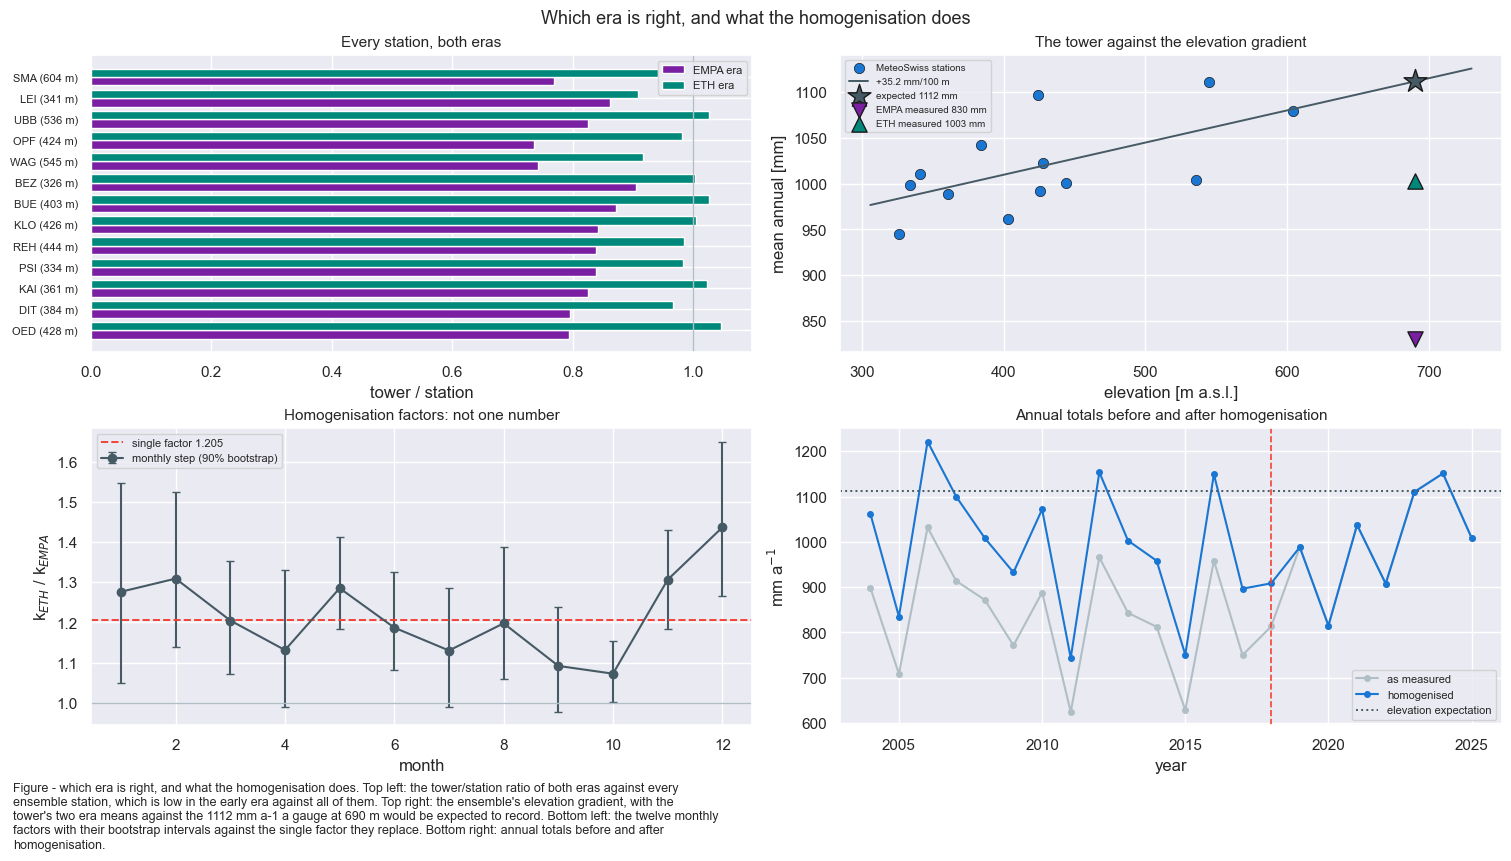

In [47]:
fig = plt.figure(figsize=(15, 8.5), dpi=100, layout='constrained')
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1], figure=fig)
ax_st = fig.add_subplot(gs[0, 0])
ax_el = fig.add_subplot(gs[0, 1])
ax_mo = fig.add_subplot(gs[1, 0])
ax_an = fig.add_subplot(gs[1, 1])
fig.suptitle('Which era is right, and what the homogenisation does', fontsize=13)

_y = np.arange(len(by_station))
ax_st.barh(_y - 0.2, by_station['EMPA'], height=0.4, color='#7B1FA2', label='EMPA era')
ax_st.barh(_y + 0.2, by_station['ETH'], height=0.4, color='#00897B', label='ETH era')
ax_st.axvline(1, color='#B0BEC5', lw=1)
ax_st.set_yticks(_y)
ax_st.set_yticklabels([f'{a} ({int(h)} m)' for a, h in
                       zip(by_station.index, by_station['alt_m'])], fontsize=8)
ax_st.set_xlabel('tower / station')
ax_st.set_title('Every station, both eras', fontsize=11)
ax_st.legend(fontsize=8)

ax_el.scatter(_alt_stn.values, _ann_stn.values, s=55, color='#1976D2', edgecolor='k', linewidth=.5,
              label='MeteoSwiss stations')
_xx = np.linspace(_alt_stn.min() - 20, SITE_ALT_M + 40, 50)
ax_el.plot(_xx, ELEV_SLOPE * _xx + ELEV_ICEPT, color='#455A64', lw=1.4,
           label=f'{ELEV_SLOPE * 100:+.1f} mm/100 m')
ax_el.scatter([SITE_ALT_M], [ELEV_EXPECT], marker='*', s=300, color='#455A64', edgecolor='k',
              zorder=4, label=f'expected {ELEV_EXPECT:.0f} mm')
ax_el.scatter([SITE_ALT_M], [MEAN_EMPA], marker='v', s=120, color='#7B1FA2', edgecolor='k',
              zorder=4, label=f'EMPA measured {MEAN_EMPA:.0f} mm')
ax_el.scatter([SITE_ALT_M], [MEAN_ETH], marker='^', s=120, color='#00897B', edgecolor='k',
              zorder=4, label=f'ETH measured {MEAN_ETH:.0f} mm')
ax_el.set_xlabel('elevation [m a.s.l.]')
ax_el.set_ylabel('mean annual [mm]')
ax_el.set_title('The tower against the elevation gradient', fontsize=11)
ax_el.legend(fontsize=7)

ax_mo.errorbar(HOMOG_STEPS.index, HOMOG_STEPS['step'],
               yerr=[HOMOG_STEPS['step'] - HOMOG_STEPS['p05'],
                     HOMOG_STEPS['p95'] - HOMOG_STEPS['step']],
               fmt='o-', color='#455A64', capsize=3, label='monthly step (90% bootstrap)')
ax_mo.axhline(STEP_SINGLE, color='#F44336', ls='--', lw=1.4,
              label=f'single factor {STEP_SINGLE:.3f}')
ax_mo.axhline(1, color='#B0BEC5', lw=1)
ax_mo.set_xlabel('month')
ax_mo.set_ylabel('k$_{ETH}$ / k$_{EMPA}$')
ax_mo.set_title('Homogenisation factors: not one number', fontsize=11)
ax_mo.legend(fontsize=8)

_raw_ann = prec[TARGET].groupby(prec.index.year).sum()
_hom_ann = prec[HOMOGCOL].groupby(prec.index.year).sum()
ax_an.plot(_raw_ann.index, _raw_ann.values, marker='o', ms=4, color='#B0BEC5',
           label='as measured')
ax_an.plot(_hom_ann.index, _hom_ann.values, marker='o', ms=4, color='#1976D2',
           label='homogenised')
ax_an.axhline(ELEV_EXPECT, color='#455A64', ls=':', lw=1.4, label='elevation expectation')
ax_an.axvline(2018, color='#F44336', ls='--', lw=1.2)
ax_an.set_xlabel('year')
ax_an.set_ylabel('mm a$^{-1}$')
ax_an.set_title('Annual totals before and after homogenisation', fontsize=11)
ax_an.legend(fontsize=8)
figcap(fig, f"which era is right, and what the homogenisation does. Top left: the tower/station "
            f"ratio of both eras against every ensemble station, which is low in the early era "
            f"against all of them. Top right: the ensemble's elevation gradient, with the "
            f"tower's two era means against the {ELEV_EXPECT:.0f} mm a-1 a gauge at "
            f"{SITE_ALT_M:.0f} m would be expected to record. Bottom left: the twelve monthly "
            f"factors with their bootstrap intervals against the single factor they replace. "
            f"Bottom right: annual totals before and after homogenisation.")

***

## 🧭 Is there a second boundary, after the start of 2016?

Everything above is about mid-2018. That is where this record breaks, but it is not the only date
at this site where something changed, and the others have never been tested here.

Three of the five tower variables move across **21 January 2016**, when the CR10X datalogger was
replaced by a CR1000: `TA` steps by +1.3 °C, `PA` by −0.0886 kPa, and `RH` by 2 to 3 percentage
points. `SW_IN` does not, and notebook `01` records that negative result deliberately, so that the
question stops being reopened. A second change five months later — a logger program dated
**7 June 2016** — corrected the pyrgeometer's calibration factor, and more than half of `LW_IN`
reads low as a result. A rain gauge is a tipping bucket with a multiplier in a logger program,
which is the same shape as that fault.

The question is therefore asked here, in five steps: what the logger programs say, what the
January 2016 outage says, whether the catch ratio steps at either date, which gauge moved wherever
it does step, and — since the same machinery answers it — whether anything happens at any *other*
date after 2018.

**The answer is negative at every one of them**, and a negative result is a result: it is recorded
here with the assertions that keep it true. The one thing that does change after 2018 is the
gauge's snow catch, which is discussed in step 5️⃣ and is not a change in the measurement chain.

### 1️⃣ The logger programs: this gauge was never on the tower logger

Notebooks `01` and `06` read the logger programs; this one has only ever read the fieldbook. The
programs answer the 2016 question directly, because a tipping bucket closes a switch once per tip
and a datalogger can therefore record it in exactly one way — a pulse-counting instruction. Listing
every pulse instruction in every surviving tower program is the complete answer to "could this
logger have been measuring the gauge", rather than a search for a word somebody might not have
written.

Seven programs survive: six CR10X programs spanning May 2004 to May 2006, and the CR1000 program
installed at the January 2016 changeover.

In [48]:
# Every surviving tower program, read rather than quoted, so this is re-derived on each run.
PULSE = {Path(_p).name: pulse_instructions(_p) for _p in PROGRAMS_TOWER + [PROGRAM_CR1000]}

tabcap('every pulse-counting instruction in every tower logger program on disk, with the channel '
       'it reads and the variable it writes to. A tipping-bucket rain gauge can be recorded in no '
       'other way, so this is the complete list of candidates for a precipitation measurement on '
       'the tower logger - and every one of them is the cup anemometer.')
_pulse_tab = pd.DataFrame(
    [{'logger program': _k, 'pulse instructions': len(_v),
      'channel': ', '.join(_c for _c, _ in _v) or '-',
      'writes to': ', '.join(_d for _, _d in _v) or '-'} for _k, _v in PULSE.items()]
).set_index('logger program')
display(_pulse_tab)

# A word search over the whole text of each program, with its own positive control alongside: the
# anemometer has to be found in every file, or a zero count for the gauge would only be evidence
# that the pattern never matches anything.
_prog_hits = []
for _p in PROGRAMS_TOWER + [PROGRAM_CR1000]:
    _txt = Path(_p).read_text(encoding='latin-1')
    _prog_hits.append({'logger program': Path(_p).name,
                       'lines naming a rain gauge': len(re.findall(PREC_PROGRAM_RX, _txt, re.I)),
                       'lines naming the anemometer': len(re.findall(ANEMOMETER_RX, _txt, re.I))})
_prog_hits = pd.DataFrame(_prog_hits).set_index('logger program')

tabcap('the same question asked of the program text rather than of its instructions. The right-hand '
       'column is the control: a pattern that finds the anemometer in every file, while the '
       'rain-gauge pattern finds nothing anywhere, is a pattern that works.')
display(_prog_hits)

assert (_pulse_tab['pulse instructions'] == 1).all(), (
    "a tower logger program carries more than one pulse instruction - one of them may be the rain "
    "gauge, and the argument that this gauge was never on the tower logger has to be re-derived")
assert not _pulse_tab['writes to'].str.contains(PREC_PROGRAM_RX, case=False).any(), \
    "a pulse instruction in a tower program writes to something that looks like a rain gauge"
assert (_prog_hits['lines naming a rain gauge'] == 0).all(), \
    "a tower logger program names a rain gauge - re-read it before trusting anything below"
assert (_prog_hits['lines naming the anemometer'] > 0).all(), (
    "the control pattern no longer finds the anemometer, so the zero counts beside it are not "
    "evidence of absence")
print("\nEvery surviving tower program counts pulses on exactly one channel, and it is the cup "
      "anemometer.")

Table - every pulse-counting instruction in every tower logger program on disk, with the channel it
reads and the variable it writes to. A tipping-bucket rain gauge can be recorded in no other way, so
this is the complete list of candidates for a precipitation measurement on the tower logger - and
every one of them is the cup anemometer.



,pulse instructions,channel,writes to
logger program,,,
LAEGEREN.20040526.CSI,1,1,Windspeed
LAEGEREN.20040810.CSI,1,1,Windspeed
LAEGEREN.20041228.CSI,1,1,Windspeed
LAEGEREN.20050818.CSI,1,1,Windspeed
LAEGEREN.20050914.CSI,1,1,Windspeed
LAEGEREN.20060524.csi,1,1,Windspeed
CH-LAE_iDL_T1_47_1.CR1,1,1,WS_CUP_SCALAR_T1_47_1


Table - the same question asked of the program text rather than of its instructions. The right-hand
column is the control: a pattern that finds the anemometer in every file, while the rain-gauge
pattern finds nothing anywhere, is a pattern that works.



,lines naming a rain gauge,lines naming the anemometer
logger program,,
LAEGEREN.20040526.CSI,0,10
LAEGEREN.20040810.CSI,0,10
LAEGEREN.20041228.CSI,0,10
LAEGEREN.20050818.CSI,0,10
LAEGEREN.20050914.CSI,0,11
LAEGEREN.20060524.csi,0,11
CH-LAE_iDL_T1_47_1.CR1,0,13



Every surviving tower program counts pulses on exactly one channel, and it is the cup anemometer.


In [49]:
# The instructions themselves, redacted: these files are signed by their authors, so anything
# printed from them passes through the same two nets as the fieldbook.
_prog_excerpts = [program_excerpt(_p, r'Pulse \(P3\)', before=6, after=7) for _p in PROGRAMS_TOWER]
_prog_excerpts.append(program_excerpt(PROGRAM_CR1000, r'PulseCount\s*\(', before=3, after=2))

# Two of the CR10X programs carry a channel map in their header comments, and it names the very
# channel the 2018 fieldbook entry later puts the gauge on.
_with_map = [_p for _p in PROGRAMS_TOWER
             if re.search(r'^;\s*P2\s', Path(_p).read_text(encoding='latin-1'), re.M)]
_map_excerpts = [program_excerpt(_p, r'^;\s*P2\s', before=1, after=0) for _p in _with_map]

audit_unmapped_names(_prog_excerpts + _map_excerpts, 'logger programs')

print(f"\n--- {Path(PROGRAMS_TOWER[-1]).name}: the only pulse instruction")
print(_prog_excerpts[-2])
print(f"\n--- {Path(PROGRAM_CR1000).name}: the only pulse instruction")
print(_prog_excerpts[-1])
print(f"\n--- the pulse-channel map, in the {len(_with_map)} programs that carry one")
for _p, _ex in zip(_with_map, _map_excerpts):
    print(f"    {Path(_p).name}:")
    for _line in _ex.splitlines():
        print(f"      {_line}")

# The fieldbook entry of 29 May 2018 puts the gauge on channel P2 of the ETH logger. The programs
# that name P2 say what it was doing before that, and it was nothing.
assert all('free' in _ex.lower() for _ex in _map_excerpts), (
    "a CR10X channel map no longer records pulse channel P2 as free, which is the channel the "
    "2018 fieldbook entry connects this gauge to")
print("\nPulse channel P2 - the channel the 2018 rewiring connects this gauge to - is recorded as "
      "free in every program that documents it.")

  logger programs: no unmapped name-shaped tokens (58 allowlisted terms)

--- LAEGEREN.20060524.csi: the only pulse instruction
; a vector instruments A100R anemometer is used
; serial number 6824 with cup C5EW
; calibration (for the 5EX 47.7 rpm per m/s):
; 60 rpm is 1 Hz which is 1.257862 m/s


16:  Pulse (P3)
 1: 1        Reps
 2: 1        Pulse Channel 1
 3: 22       Switch Closure, Output Hz
 4: 28       Loc [ Windspeed ]
 5: 1.25786  Mult
 6: 0.0      Offset


--- CH-LAE_iDL_T1_47_1.CR1: the only pulse instruction
    VoltSe (WD_VANE_T1_47_1,1,mV2500,9,1,0,_50Hz,0.357,0)
    
    'A100LK Wind Speed Sensor (CSL) measurement 'WS_ms' 
    PulseCount(WS_CUP_SCALAR_T1_47_1,1,1,0,1,WS_CUP_SCALAR_T1_47_1_mult,WS_CUP_SCALAR_T1_47_1_offset) 
    If WS_CUP_SCALAR_T1_47_1<0.258 Then WS_CUP_SCALAR_T1_47_1=0
    'BF3 output

--- the pulse-channel map, in the 2 programs that carry one
    LAEGEREN.20050914.CSI:
      ; P1   A100R Wind speed sensor
      ; P2   free
    LAEGEREN.20060524.csi:
 

Both acquisition systems that this notebook could have blamed for a 2016 step **do not measure
precipitation at all**. The CR10X programs count pulses on one channel and it is the cup
anemometer; the CR1000 program installed on 18 January 2016 does the same; and the channel the
gauge is eventually wired to, `P2`, is documented as free. That is consistent with everything else
here: the gauge was EMPA's instrument on EMPA's acquisition until 29 May 2018, which is why
notebook `05` could use a NABEL sensor to diagnose a *tower*-logger fault in 2012 in the first
place.

So neither 2016 date can have moved this series through the mechanism that moved the others. The
January changeover replaced a logger that was not reading this gauge, and the June program change
edited a program that does not contain it.

::: {.callout-note title="What the programs cover, and what they do not"}
Six CR10X programs span May 2004 to May 2006 and the CR1000 program dates from January 2016. **No
tower program between May 2006 and January 2016 survives on disk, and none after January 2016 at
all** — including the two that matter most to this variable, the May 2018 program that first
recorded the gauge and the May 2019 one that corrected it by a factor of ten. The programs
establish endpoints, and they establish them for the tower logger only; EMPA's own acquisition
configuration is not here in any form. The data have to cover the interval between them, which is
what the remaining steps do.
:::

### 2️⃣ The outage that `PA` and `LW_IN` have and this record does not

The January 2016 changeover left a mark that needs no reference at all. Both variables that stayed
on the tower logger lose the same block of records ending on the changeover date — the logger was
down while it was being replaced. If the gauge had been on that logger, it would share the outage
exactly. The window is taken from notebook `05`'s own product rather than written down here, so a
re-run that moved it moves this test with it.

In [50]:
# Derived from the companion product, not hard-coded: the longest gap it has in the winter of the
# changeover. If a re-run of 05 moved that outage, this test follows it instead of drifting off it.
_pa = pd.read_parquet(COMPANION_PRODUCTS[0][1])[COMPANION_PRODUCTS[0][2]].loc['2015-11-01':'2016-03-31']
_isna = _pa.isna()
_runs = _pa[_isna].groupby((_isna != _isna.shift()).cumsum()[_isna]).agg(
    start=lambda x: x.index[0], end=lambda x: x.index[-1], n='size')
OUTAGE = _runs.loc[_runs['n'].idxmax()]
print(f"longest gap in {COMPANION_PRODUCTS[0][0]} around the changeover: "
      f"{OUTAGE['start']} -> {OUTAGE['end']}  ({OUTAGE['n'] * 0.5 / 24:.1f} days)")
assert OUTAGE['end'].date() == pd.Timestamp(LOGGER_CHANGE).date(), (
    f"the outage in {COMPANION_PRODUCTS[0][0]} no longer ends on {LOGGER_CHANGE}; this step "
    f"identified the changeover by that coincidence and has to be re-derived")

_win = slice(OUTAGE['start'], OUTAGE['end'])
_cov = []
for _lbl, _path, _col in COMPANION_PRODUCTS:
    _s = pd.read_parquet(_path)[_col].loc[_win]
    _cov.append({'product': _lbl, 'column': _col, 'records present': int(_s.notna().sum()),
                 'of': len(_s), 'coverage %': round(100 * float(_s.notna().mean()), 1)})
_prec_win = prec[TARGET].where(prec[FILLCOL] == FILL_MEASURED).loc[_win]
_cov.append({'product': '08 PREC (measured)', 'column': TARGET,
             'records present': int(_prec_win.notna().sum()), 'of': len(_prec_win),
             'coverage %': round(100 * float(_prec_win.notna().mean()), 1)})
_cov = pd.DataFrame(_cov).set_index('product')

tabcap(f"coverage of the three tower products through the {OUTAGE['n'] * 0.5 / 24:.1f}-day outage "
       f"that ends on the day the datalogger was replaced. Two of them lose every record; this one "
       f"loses none, because the gauge was on a different acquisition system.")
display(_cov)
print(f"the gauge recorded {float(_prec_win.sum()):.1f} mm during the outage, on "
      f"{int((_prec_win > 0).sum()):,} wet half-hours")

assert (_cov.loc[[_l for _l, _, _ in COMPANION_PRODUCTS], 'records present'] == 0).all(), (
    "the companion products no longer lose the whole window, so their outage no longer identifies "
    "the changeover")
assert float(_prec_win.notna().mean()) == 1.0, (
    "the precipitation record has a gap inside the January 2016 logger outage after all - it may "
    "have been on that logger, and the conclusion of this section has to be re-derived")
print("\nThe logger that was replaced in January 2016 was not recording this gauge.")

longest gap in 05 PA around the changeover: 2016-01-01 00:15:00 -> 2016-01-21 13:45:00  (20.6 days)
Table - coverage of the three tower products through the 20.6-day outage that ends on the day the
datalogger was replaced. Two of them lose every record; this one loses none, because the gauge was
on a different acquisition system.



,column,records present,of,coverage %
product,,,,
05 PA,PA_T1_47_1,0,988,0.0
06 LW_IN,LW_IN_T1_47_1,0,988,0.0
08 PREC (measured),PREC_TOT_T1_47_1,988,988,100.0


the gauge recorded 89.3 mm during the outage, on 214 wet half-hours

The logger that was replaced in January 2016 was not recording this gauge.


### 3️⃣ Does the catch ratio step at either 2016 date?

The programs and the outage settle the mechanism; the data have to cover the interval the programs
do not, because a change could have been made in a program that did not survive. The statistic is
the one this notebook already uses — the tower's catch ratio against the reference before a
candidate date, divided by the same ratio after it — with two changes that matter for a boundary
this small.

- **The reference is the thirteen-station ensemble, not one gauge.** The regional index averages
  out the day-to-day noise a single station carries, which is what makes a few per cent visible at
  all. This matters more than it sounds: measured against Ehrendingen *alone*, the January 2016
  date shows a +16 % step, which is the largest of any station and is that station's noise rather
  than the tower's signal. One reference would have found a break that is not there.
- **Snow is removed.** An unheated gauge under-catches solid precipitation badly, so a comparison
  weighted towards cold days measures the weather rather than the chain. Only days whose mean air
  temperature exceeds `RAIN_TA_MIN` enter the test, and the cold days are analysed separately in
  step 5️⃣ rather than averaged in here.

The threshold is derived rather than chosen. The same statistic is evaluated at every month from
2006 to 2024 whose windows lie entirely on one side of the 2018 break — that is, at boundaries
where nothing happened — and the ninetieth percentile of what those quiet boundaries produce is
what a candidate has to exceed. A guard set below that would fire on nothing having happened, which
is the trap notebook `01` came within a hundredth of a percent of. The positive control is the
2018 break itself: the same statistic has to clear the same threshold there, or it is measuring
nothing.

In [51]:
# One frame for every boundary test below. Air temperature is put on the SAME MeteoSwiss
# precipitation day as the rainfall it classifies - a local-midnight daily mean would label the
# wrong 24 hours - and the tower is the measured, complete-day series built for the ensemble
# comparison above, so no filled value enters a boundary test.
BOUND = pd.DataFrame({'tower': tower_msday_meas, 'index': reg_index,
                      'ta': to_ms_precip_day(pd.read_parquet(TA_PRODUCT)[TA_COL], agg='mean')}
                     ).dropna()
BOUND = BOUND[BOUND['index'] >= WET_DAY_MIN_MM]
LIQUID_DAYS = BOUND[BOUND['ta'] > RAIN_TA_MIN]
COLD_DAYS = BOUND[BOUND['ta'] < SNOW_TA_MAX]
print(f"days with a complete measured tower day and the full ensemble: {len(BOUND):,}")
print(f"  of them liquid (daily mean TA > {RAIN_TA_MIN} degC): {len(LIQUID_DAYS):,}")
print(f"  of them cold   (daily mean TA < {SNOW_TA_MAX} degC): {len(COLD_DAYS):,}")


def boundary_step(date, data=None, win_days=BOUNDARY_WINDOW_DAYS) -> float:
    """The catch ratio after a date, divided by the catch ratio before it.

    Both windows are `win_days` long and each must carry BOUNDARY_MIN_REF_MM of reference rain;
    a window with less than that returns NaN rather than a ratio built on a handful of storms.
    """
    data = LIQUID_DAYS if data is None else data
    _d, _w = pd.Timestamp(date), pd.Timedelta(days=win_days)
    _a = data.loc[_d - _w:_d - pd.Timedelta(days=1)]
    _b = data.loc[_d:_d + _w - pd.Timedelta(days=1)]
    if float(_a['index'].sum()) < BOUNDARY_MIN_REF_MM or float(_b['index'].sum()) < BOUNDARY_MIN_REF_MM:
        return np.nan
    return float((_b['tower'].sum() / _b['index'].sum()) / (_a['tower'].sum() / _a['index'].sum()))


# What an ordinary date does to this statistic. A candidate whose windows would straddle the 2018
# break is not a quiet boundary and is excluded; everything else is one, by construction.
_quiet = {}
for _cand in pd.date_range('2006-01-01', '2024-01-01', freq='MS'):
    _lo = _cand - pd.Timedelta(days=BOUNDARY_WINDOW_DAYS)
    _hi = _cand + pd.Timedelta(days=BOUNDARY_WINDOW_DAYS)
    if _lo <= pd.Timestamp(ACQ_TRANSITION_END) and _hi >= pd.Timestamp(ACQ_TRANSITION_START):
        continue
    _s = boundary_step(_cand)
    if not np.isnan(_s):
        _quiet[_cand] = _s
QUIET_STEPS = pd.Series(_quiet)
QUIET_DEV = (QUIET_STEPS - 1).abs()
QUIET_P90 = float(QUIET_DEV.quantile(0.90))
print(f"\nquiet boundaries evaluated: {len(QUIET_STEPS)}  "
      f"({QUIET_STEPS.index[0].date()} -> {QUIET_STEPS.index[-1].date()})")
print(f"  |step - 1| at a quiet boundary: median {QUIET_DEV.median():.4f}, "
      f"p90 {QUIET_P90:.4f}, max {QUIET_DEV.max():.4f}")

# The positive control. If the statistic cannot see the break this notebook has already proved is
# there, its silence at the 2016 dates would mean nothing.
BREAK_STEP = boundary_step(pd.Timestamp(ACQ_TRANSITION_END) + pd.Timedelta(days=1))
print(f"  the 2018 acquisition break scores {abs(BREAK_STEP - 1):.4f}, "
      f"{abs(BREAK_STEP - 1) / QUIET_P90:.2f}x the quiet p90")
assert abs(BREAK_STEP - 1) > QUIET_P90, (
    "the statistic cannot distinguish the 2018 acquisition break from an ordinary boundary, so it "
    "cannot support a negative result anywhere else either")

days with a complete measured tower day and the full ensemble: 3,246


  of them liquid (daily mean TA > 3.0 degC): 2,464
  of them cold   (daily mean TA < 2.0 degC): 637



quiet boundaries evaluated: 166  (2006-01-01 -> 2024-01-01)
  |step - 1| at a quiet boundary: median 0.0285, p90 0.0677, max 0.1034
  the 2018 acquisition break scores 0.0830, 1.23x the quiet p90


In [52]:
# The candidates. The two 2016 dates are what this section is about; the rest are every other date
# after them at which something could have changed, tested with the same statistic.
BOUNDARY_CANDIDATES = [
    (LOGGER_CHANGE, 'CR10X -> CR1000 logger changeover'),
    (CAL_CHANGE, 'logger program corrected (the LW_IN fault)'),
    ('2018-08-08', 'the 2018 acquisition break (positive control)'),
    ('2020-01-02', 'record 4 -> record 5, mst -> diive screening'),
    ('2021-12-15', 'CNR4 radiometer swap (a different instrument)'),
    ('2022-01-01', 'the largest candidate anywhere after the break'),
    ('2024-07-23', 'new transformer for the gauge heater'),
]
_rows = []
for _date, _what in BOUNDARY_CANDIDATES:
    _liq, _all = boundary_step(_date), boundary_step(_date, data=BOUND)
    _rows.append({'date': _date, 'event': _what,
                  'step, liquid days': round(_liq, 4), 'step, all wet days': round(_all, 4),
                  'x quiet p90': round(abs(_liq - 1) / QUIET_P90, 2)})
BOUNDARY_TABLE = pd.DataFrame(_rows).set_index('date')

tabcap(f'every candidate boundary from January 2016 onwards, scored with the same statistic: the '
       f'catch ratio against the regional ensemble over the {BOUNDARY_WINDOW_DAYS} days after the '
       f'date divided by the same ratio over the {BOUNDARY_WINDOW_DAYS} days before it. The last '
       f'column expresses that as a multiple of what an ordinary boundary produces, so a value '
       f'below 1 is inside the ordinary range. Only the 2018 break exceeds it.')
display(BOUNDARY_TABLE)

for _date, _what in BOUNDARY_CANDIDATES[:2]:
    _dev = abs(boundary_step(_date) - 1)
    print(f"{_date}: |step - 1| = {_dev:.4f}, quiet p90 = {QUIET_P90:.4f} "
          f"({_dev / QUIET_P90:.2f}x)")
    assert _dev < QUIET_P90, (
        f"the catch ratio steps at {_date} by more than an ordinary boundary produces. The logger "
        f"programs say this gauge was not on the equipment that changed then, so either that "
        f"reading is wrong or something else happened on that date")
print("\nNeither 2016 date moves this series by more than an ordinary date does.")

# And the threshold itself has to be worth something. A wall set below the scatter of the statistic
# would pass every candidate, including a real break.
assert QUIET_P90 > 2 * QUIET_DEV.median() * 0.5, "the quiet-boundary spread has collapsed"
assert BOUNDARY_TABLE.loc['2018-08-08', 'x quiet p90'] == BOUNDARY_TABLE['x quiet p90'].max(), (
    "a date other than the 2018 acquisition break is now the largest step in the record, which is "
    "the finding this section rests on")

Table - every candidate boundary from January 2016 onwards, scored with the same statistic: the
catch ratio against the regional ensemble over the 730 days after the date divided by the same ratio
over the 730 days before it. The last column expresses that as a multiple of what an ordinary
boundary produces, so a value below 1 is inside the ordinary range. Only the 2018 break exceeds it.


,event,"step, liquid days","step, all wet days",x quiet p90
date,,,,
2016-01-21,CR10X -> CR1000 logger changeover,1.0298,1.0351,0.44
2016-06-07,logger program corrected (the LW_IN fault),0.9956,1.0056,0.07
2018-08-08,the 2018 acquisition break (positive control),1.0830,1.1124,1.23
2020-01-02,"record 4 -> record 5, mst -> diive screening",1.0139,0.9596,0.21
2021-12-15,CNR4 radiometer swap (a different instrument),1.0301,1.1204,0.44
2022-01-01,the largest candidate anywhere after the break,1.0412,1.1291,0.61
2024-07-23,new transformer for the gauge heater,0.9379,0.9375,0.92


2016-01-21: |step - 1| = 0.0298, quiet p90 = 0.0677 (0.44x)
2016-06-07: |step - 1| = 0.0044, quiet p90 = 0.0677 (0.07x)

Neither 2016 date moves this series by more than an ordinary date does.


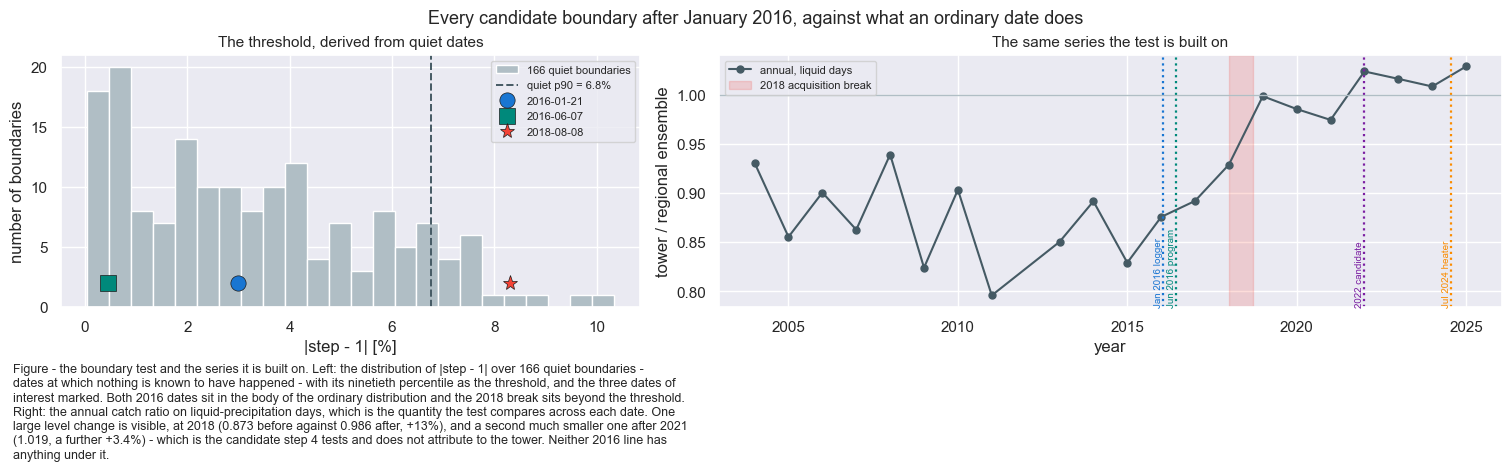

In [53]:
fig, axs = plt.subplots(ncols=2, figsize=(15, 4.6), dpi=100, layout='constrained',
                        width_ratios=[1, 1.35])
fig.suptitle('Every candidate boundary after January 2016, against what an ordinary date does',
             fontsize=13)

axs[0].hist(100 * QUIET_DEV.values, bins=24, color='#B0BEC5', edgecolor='white',
            label=f'{len(QUIET_DEV)} quiet boundaries')
axs[0].axvline(100 * QUIET_P90, color='#455A64', ls='--', lw=1.4,
               label=f'quiet p90 = {100 * QUIET_P90:.1f}%')
for _date, _colour, _mark in [(LOGGER_CHANGE, '#1976D2', 'o'), (CAL_CHANGE, '#00897B', 's'),
                              ('2018-08-08', '#F44336', '*')]:
    axs[0].plot([100 * abs(boundary_step(_date) - 1)], [2], _mark, color=_colour, ms=11,
                markeredgecolor='k', markeredgewidth=.5, label=_date, zorder=5)
axs[0].set_xlabel('|step - 1| [%]')
axs[0].set_ylabel('number of boundaries')
axs[0].set_title('The threshold, derived from quiet dates', fontsize=11)
axs[0].legend(fontsize=8)

_ann = LIQUID_DAYS.groupby(LIQUID_DAYS.index.year).agg(t=('tower', 'sum'), r=('index', 'sum'),
                                                       n=('tower', 'size'))
_ann = _ann[_ann['n'] >= 80]
_ratio = _ann['t'] / _ann['r']
axs[1].plot(_ratio.index, _ratio.values, marker='o', ms=5, color='#455A64', label='annual, liquid days')
axs[1].axvspan(2018, 2018.7, color='#F44336', alpha=.18, label='2018 acquisition break')
for _x, _lab, _c in [(2016.05, 'Jan 2016 logger', '#1976D2'), (2016.43, 'Jun 2016 program', '#00897B'),
                     (2022, '2022 candidate', '#7B1FA2'), (2024.56, 'Jul 2024 heater', '#FB8C00')]:
    axs[1].axvline(_x, color=_c, ls=':', lw=1.6)
    axs[1].annotate(_lab, (_x, axs[1].get_ylim()[0]), rotation=90, fontsize=7, color=_c,
                    va='bottom', ha='right')
axs[1].axhline(1, color='#B0BEC5', lw=1)
axs[1].set_xlabel('year')
axs[1].set_ylabel('tower / regional ensemble')
axs[1].set_title('The same series the test is built on', fontsize=11)
axs[1].legend(fontsize=8, loc='upper left')

_pre = float(_ratio[_ratio.index <= 2017].mean())
_mid = float(_ratio[(_ratio.index >= 2019) & (_ratio.index <= 2021)].mean())
_post = float(_ratio[_ratio.index >= 2022].mean())
figcap(fig, f'the boundary test and the series it is built on. Left: the distribution of '
            f'|step - 1| over {len(QUIET_DEV)} quiet boundaries - dates at which nothing is known '
            f'to have happened - with its ninetieth percentile as the threshold, and the three '
            f'dates of interest marked. Both 2016 dates sit in the body of the ordinary '
            f'distribution and the 2018 break sits beyond the threshold. Right: the annual catch '
            f'ratio on liquid-precipitation days, which is the quantity the test compares across '
            f'each date. One large level change is visible, at 2018 '
            f'({_pre:.3f} before against {_mid:.3f} after, +{100 * (_mid / _pre - 1):.0f}%), and '
            f'a second much smaller one after 2021 ({_post:.3f}, a further '
            f'+{100 * (_post / _mid - 1):.1f}%) - which is the candidate step 4 tests and does not '
            f'attribute to the tower. Neither 2016 line has anything under it.')

### 4️⃣ Which gauge moved: the ensemble at each boundary

A ratio says two gauges separated; it never says which of them left. That is why this notebook
attributes the 2018 break with thirteen stations rather than one, and the same rule decides every
other candidate: **if the tower rises against every station at once, the tower moved.** Thirteen
independent gauges do not change together on a date, so a candidate that moves the tower against
only some of them is telling us about the weather, not about the instrument.

The table below applies that rule at every candidate. It also shows why the rain/snow split of
step 3️⃣ is not a detail: on *all* wet days the 2022 candidate looks exactly like a tower change,
unanimous across all thirteen stations. Once snow is removed, three stations move the other way and
the unanimity disappears — the change is in what the gauge does with solid precipitation, not in
what its chain does with a bucket tip.

In [54]:
def ensemble_steps(before, after, data) -> pd.Series:
    """The tower/station ratio after a boundary divided by the same ratio before it, per station.

    A station contributing fewer than ENSEMBLE_MIN_DAYS to either side is dropped rather than
    carried at whatever ratio a handful of days happens to give.
    """
    _out = {}
    for _col in regional.columns:
        _r = {}
        for _lbl, (_lo, _hi) in (('before', before), ('after', after)):
            _days = data.loc[_lo:_hi].index.intersection(regional[_col].dropna().index)
            _r[_lbl] = (float(data['tower'].reindex(_days).sum())
                        / float(regional[_col].reindex(_days).sum())
                        if len(_days) >= ENSEMBLE_MIN_DAYS else np.nan)
        _out[_col.split('_')[1]] = _r['after'] / _r['before']
    return pd.Series(_out).dropna()


# Windows chosen so that neither side of a candidate crosses the 2018 break.
ENSEMBLE_TESTS = [
    (LOGGER_CHANGE, ('2013-01-21', '2016-01-20'), (LOGGER_CHANGE, '2018-05-28')),
    (CAL_CHANGE, ('2013-06-07', '2016-06-06'), (CAL_CHANGE, '2018-05-28')),
    ('2018-08-08', ('2015-08-08', '2018-05-28'), ('2018-08-08', '2021-08-07')),
    ('2020-01-02', ('2017-01-02', '2019-12-31'), ('2020-01-02', '2023-01-01')),
    ('2021-12-15', ('2018-12-15', '2021-12-14'), ('2021-12-15', '2024-12-14')),
    ('2022-01-01', ('2019-01-01', '2021-12-31'), ('2022-01-01', RECORD_END)),
    ('2024-07-23', ('2021-07-23', '2024-07-22'), ('2024-07-23', RECORD_END)),
]
ENSEMBLE_LIQUID, ENSEMBLE_ALL, _rows = {}, {}, []
for _date, _before, _after in ENSEMBLE_TESTS:
    _l = ensemble_steps(_before, _after, LIQUID_DAYS)
    _a = ensemble_steps(_before, _after, BOUND)
    ENSEMBLE_LIQUID[_date], ENSEMBLE_ALL[_date] = _l, _a
    _rows.append({'date': _date,
                  'stations up, liquid days': f"{int((_l > 1).sum())}/{len(_l)}",
                  'median step, liquid': round(float(_l.median()), 4),
                  'spread, liquid': f"{_l.min():.3f}-{_l.max():.3f}",
                  'stations up, all wet days': f"{int((_a > 1).sum())}/{len(_a)}",
                  'median step, all': round(float(_a.median()), 4)})
ENSEMBLE_TABLE = pd.DataFrame(_rows).set_index('date')

tabcap('the ensemble rule applied at every candidate boundary. `stations up` counts the stations '
       'against which the tower rose; unanimity is what identifies the tower, because thirteen '
       'independent gauges do not step together on one date. Only the 2018 break is unanimous on '
       'liquid-precipitation days. The 2022 candidate is unanimous on all wet days and not on '
       'liquid ones, which locates it in the snow rather than in the measurement chain.')
display(ENSEMBLE_TABLE)

UNANIMOUS = [_d for _d, _s in ENSEMBLE_LIQUID.items() if bool((_s > 1).all())]
print(f"unanimous on liquid days: {UNANIMOUS}")
assert UNANIMOUS == ['2018-08-08'], (
    f"the ensemble now identifies the tower at {UNANIMOUS} rather than at the 2018 break alone. "
    f"A second date at which the tower moves against every station is a second break, and this "
    f"product ships one flag boundary")
assert bool((ENSEMBLE_ALL['2022-01-01'] > 1).all()), (
    "the 2022 candidate is no longer unanimous on all wet days, so it can no longer be used to "
    "show what removing snow does to this test")
assert not bool((ENSEMBLE_LIQUID['2022-01-01'] > 1).all()), (
    "the 2022 candidate has become unanimous on liquid days too - it is then a change in the "
    "measurement and not in the snow, and this section's conclusion has to be re-derived")
print("Only the 2018 acquisition break moves the tower against every station in the ensemble.")

Table - the ensemble rule applied at every candidate boundary. `stations up` counts the stations
against which the tower rose; unanimity is what identifies the tower, because thirteen independent
gauges do not step together on one date. Only the 2018 break is unanimous on liquid-precipitation
days. The 2022 candidate is unanimous on all wet days and not on liquid ones, which locates it in
the snow rather than in the measurement chain.



,"stations up, liquid days","median step, liquid","spread, liquid","stations up, all wet days","median step, all"
date,,,,,
2016-01-21,9/13,1.0172,0.926-1.165,6/13,0.9956
2016-06-07,6/13,0.9929,0.887-1.145,4/13,0.9839
2018-08-08,13/13,1.1183,1.058-1.240,13/13,1.1210
2020-01-02,9/13,1.0376,0.965-1.167,7/13,1.0086
2021-12-15,9/13,1.0295,0.975-1.085,13/13,1.1140
2022-01-01,10/13,1.0369,0.979-1.098,13/13,1.1170
2024-07-23,2/13,0.9665,0.884-1.058,5/13,0.9897


unanimous on liquid days: ['2018-08-08']
Only the 2018 acquisition break moves the tower against every station in the ensemble.


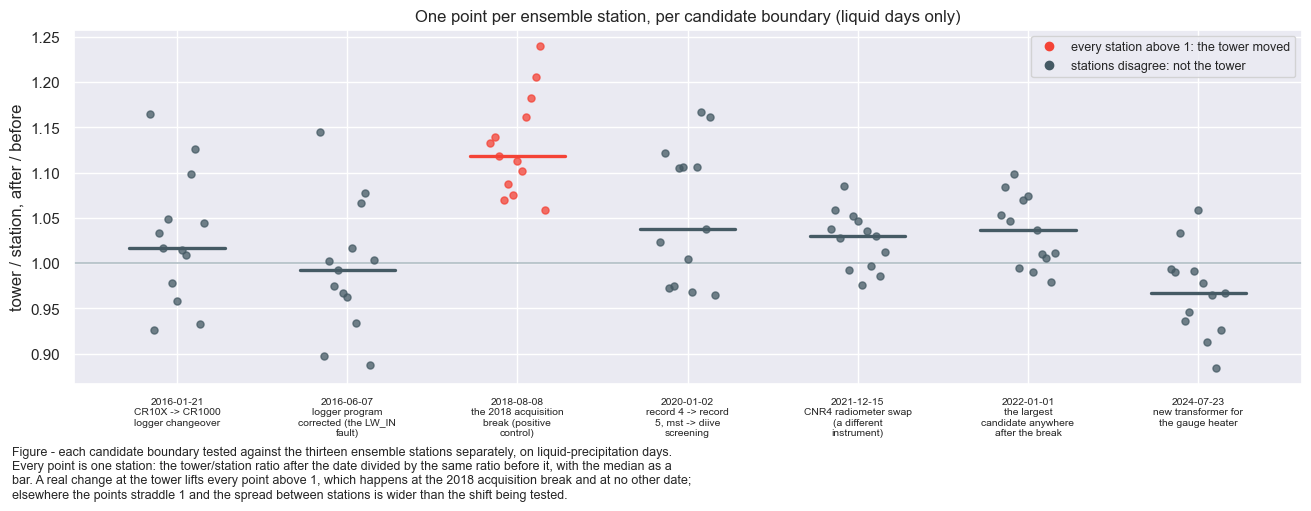

In [55]:
fig, ax = plt.subplots(figsize=(13, 5), dpi=100, layout='constrained')
_x = np.arange(len(ENSEMBLE_TESTS))
for _i, (_date, _, _) in enumerate(ENSEMBLE_TESTS):
    _s = ENSEMBLE_LIQUID[_date]
    _colour = '#F44336' if bool((_s > 1).all()) else '#455A64'
    ax.scatter(np.full(len(_s), _i) + np.linspace(-.16, .16, len(_s)), _s.values, s=26,
               color=_colour, alpha=.75, zorder=3)
    ax.plot([_i - .28, _i + .28], [_s.median()] * 2, color=_colour, lw=2.4, zorder=4)
ax.axhline(1, color='#B0BEC5', lw=1.2)
ax.set_xticks(_x)
# Wrapped, not truncated: the earlier version cut every label mid-word. The text still comes
# from BOUNDARY_CANDIDATES, so the two figures cannot end up describing a date differently.
ax.set_xticklabels([f"{_d}\n" + textwrap.fill(dict(BOUNDARY_CANDIDATES)[_d], 20)
                    for _d, _, _ in ENSEMBLE_TESTS], fontsize=7.5)
ax.set_ylabel('tower / station, after / before')
ax.set_title('One point per ensemble station, per candidate boundary (liquid days only)',
             fontsize=12)
ax.plot([], [], 'o', color='#F44336', label='every station above 1: the tower moved')
ax.plot([], [], 'o', color='#455A64', label='stations disagree: not the tower')
ax.legend(fontsize=9)

figcap(fig, 'each candidate boundary tested against the thirteen ensemble stations separately, on '
            'liquid-precipitation days. Every point is one station: the tower/station ratio after '
            'the date divided by the same ratio before it, with the median as a bar. A real change '
            'at the tower lifts every point above 1, which happens at the 2018 acquisition break '
            'and at no other date; elsewhere the points straddle 1 and the spread between stations '
            'is wider than the shift being tested.')

### 5️⃣ What did change after 2018: snow, not scaling

One thing after 2018 is real and is worth stating plainly, because it is what makes the naive
version of this test go wrong. The gauge's catch of *solid* precipitation moves around a great
deal, and the fieldbook offers two reasons why it might:

- **8 August 2018** — the entry that this notebook already uses to date the acquisition break also
  records that *"the heating is disconnected so far and would require a 48 V power supply"*. The
  flag boundary at `source >= 3` is therefore also a heating boundary, which no part of this
  notebook had noticed.
- **23 July 2024** — a new transformer was installed for the heater, after an entry of 12 January
  2024 recording the heating as still inactive.

Both are dated hardware changes with an identified mechanism, which is the category that could
justify a correction. The data do not support one, and the cell below shows why: the cold-day catch
ratio varies more between one winter and the next than either event moves it, and the recovery
arrives a winter *before* the transformer that would have to explain it.

In [56]:
# The cold-day catch ratio per winter. A winter is Jul-Jun, labelled by the year it ends in, so
# that December and the January after it are not split into different rows.
_c = COLD_DAYS.copy()
_c['winter'] = np.where(_c.index.month >= 7, _c.index.year + 1, _c.index.year)
COLD_WINTER = _c.groupby('winter').agg(days=('tower', 'size'), ref_mm=('index', 'sum'),
                                       tower_mm=('tower', 'sum'))
COLD_WINTER = COLD_WINTER[COLD_WINTER['ref_mm'] >= 30]     # a winter with less than this cannot say anything
COLD_WINTER['ratio'] = COLD_WINTER['tower_mm'] / COLD_WINTER['ref_mm']
COLD_WINTER['heating'] = np.where(COLD_WINTER.index <= 2018, 'EMPA era, gauge heated',
                                  np.where(COLD_WINTER.index <= 2024, 'heating disconnected',
                                           'new transformer fitted'))

tabcap(f'the catch ratio on cold days (daily mean TA < {SNOW_TA_MAX} degC) winter by winter, where '
       f'a winter runs July to June and is labelled by the year it ends in. The `heating` column is '
       f'the fieldbook\'s account of the gauge heater over the same period. The winter-to-winter '
       f'scatter is larger than any difference between the three periods.')
display(COLD_WINTER.round(3))

_eras = [('EMPA era, gauge heated', COLD_WINTER.index <= 2018),
         ('heating disconnected', (COLD_WINTER.index >= 2019) & (COLD_WINTER.index <= 2024)),
         ('new transformer fitted', COLD_WINTER.index >= 2025)]
COLD_ERA = {}
for _lbl, _m in _eras:
    _s = COLD_WINTER[_m]
    COLD_ERA[_lbl] = float(_s['tower_mm'].sum() / _s['ref_mm'].sum())
    print(f"  {_lbl:<24} winters={len(_s):>2}  ratio {COLD_ERA[_lbl]:.3f}  "
          f"per-winter {_s['ratio'].min():.3f}-{_s['ratio'].max():.3f}  sd {_s['ratio'].std():.3f}")

_empa_sd = float(COLD_WINTER.loc[COLD_WINTER.index <= 2018, 'ratio'].std())
_disconnect = abs(COLD_ERA['EMPA era, gauge heated'] - COLD_ERA['heating disconnected'])
print(f"\ndisconnecting the heating in Aug 2018 moves the cold-day ratio by {_disconnect:.3f};")
print(f"the ordinary winter-to-winter spread of the same ratio is {_empa_sd:.3f}")
assert _disconnect < _empa_sd, (
    "the documented disconnection of the gauge heating now moves the cold-day catch ratio by more "
    "than the winter-to-winter spread, so it has become a detectable and datable change")

# And the transformer is not what changed it: the winter before it was fitted already sits far
# above the level of the period it is supposed to have ended.
_before_transformer = float(COLD_WINTER.loc[2024, 'ratio'])
print(f"\nwinter 2023/24, with the heating recorded as inactive on 12 Jan 2024: "
      f"{_before_transformer:.3f}")
print(f"the whole disconnected period:                                        "
      f"{COLD_ERA['heating disconnected']:.3f}")
assert _before_transformer > COLD_ERA['heating disconnected'], (
    "the winter before the heater transformer was fitted no longer stands above the period it "
    "belongs to, so the argument that the recovery precedes the transformer has to be re-derived")
print("\nThe recovery in cold-day catch precedes the transformer by a winter, so the transformer "
      "is not what produced it. Nothing is corrected for either event.")

Table - the catch ratio on cold days (daily mean TA < 2.0 degC) winter by winter, where a winter
runs July to June and is labelled by the year it ends in. The `heating` column is the fieldbook's
account of the gauge heater over the same period. The winter-to-winter scatter is larger than any
difference between the three periods.



,days,ref_mm,tower_mm,ratio,heating
winter,,,,,
2004,23,109.477,89.0,0.813,"EMPA era, gauge heated"
2005,42,113.823,66.5,0.584,"EMPA era, gauge heated"
2006,40,268.985,184.4,0.686,"EMPA era, gauge heated"
2007,11,55.615,29.2,0.525,"EMPA era, gauge heated"
2008,21,106.862,41.7,0.390,"EMPA era, gauge heated"
2009,44,257.862,171.6,0.665,"EMPA era, gauge heated"
2010,41,140.938,81.9,0.581,"EMPA era, gauge heated"
2011,30,117.177,73.0,0.623,"EMPA era, gauge heated"
2012,28,139.400,63.0,0.452,"EMPA era, gauge heated"


  EMPA era, gauge heated   winters=15  ratio 0.620  per-winter 0.390-0.813  sd 0.107
  heating disconnected     winters= 6  ratio 0.564  per-winter 0.347-0.882  sd 0.191
  new transformer fitted   winters= 2  ratio 0.846  per-winter 0.842-0.860  sd 0.013

disconnecting the heating in Aug 2018 moves the cold-day ratio by 0.056;
the ordinary winter-to-winter spread of the same ratio is 0.107

winter 2023/24, with the heating recorded as inactive on 12 Jan 2024: 0.882
the whole disconnected period:                                        0.564

The recovery in cold-day catch precedes the transformer by a winter, so the transformer is not what produced it. Nothing is corrected for either event.


In [57]:
# The fieldbook on the heater, read here rather than quoted, and redacted like every other entry.
_heat = fb[(fb['Date'] >= '2018-01-01')
           & fb['text'].str.contains(r'heating|heater|Heizung|48\s*V|transformer', case=False)
           & (fb['Operation Tag'].fillna('').str.contains('PREC', case=False)
              | fb['text'].str.contains(r'rain gauge|rainbucket|precipitation', case=False))]
_heat = _heat.drop_duplicates(subset=['Date', 'text']).sort_values('Date')
assert len(_heat) > 0, "no fieldbook entry about the gauge heating - is this the right export?"
print(f"fieldbook entries about this gauge's heating: {len(_heat)}\n")
for _, _r in _heat.iterrows():
    print(f"--- {_r['Date'].date()}  [{_r['Event Tag']}]")
    print(f"    {_r['text'][:400]}")

fieldbook entries about this gauge's heating: 4

--- 2018-05-29  [HW_MOD]
    Worked on the device Connecting EMPA instruments (rain gauge and CNR1) to our logger Checked the Wiring situation Disconnected the rain gauge from EMPA measuring system and connected to our logger (Channel P2) Downloaded logger data and updated the logger program for rain gauge measurements. We decided against disconnecting the sensors from the EMPA wiring box and wiring them directly to our logge
--- 2018-08-08  [HW_MOD]
    Worked on the device It has been decided that the nice EMPA wiring box should not be ours (See fieldbook entry 29.5.). Therefore I disconnected the wiring from the screw terminals and connected the wires directly by soldering and shrink tubing. CNR1 signal wire and PT100 and heating wire are connected to one wire that leads to the logger. The CNR1 ventilation wire is connected to the 12V power sup
--- 2024-01-12  [CLEAN]
    Sensors on the tower were covered with snow. Rain gauge heating

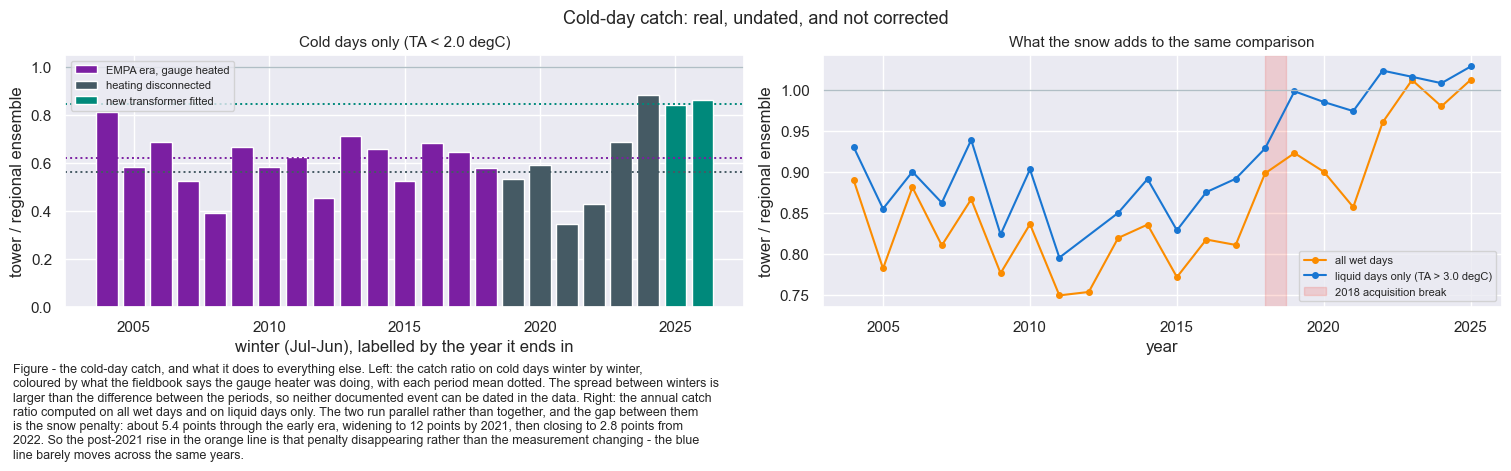

In [58]:
fig, axs = plt.subplots(ncols=2, figsize=(15, 4.6), dpi=100, layout='constrained')
fig.suptitle('Cold-day catch: real, undated, and not corrected', fontsize=13)

_colours = {'EMPA era, gauge heated': '#7B1FA2', 'heating disconnected': '#455A64',
            'new transformer fitted': '#00897B'}
for _lbl, _c in _colours.items():
    _s = COLD_WINTER[COLD_WINTER['heating'] == _lbl]
    axs[0].bar(_s.index, _s['ratio'], color=_c, label=_lbl)
    axs[0].axhline(COLD_ERA[_lbl], color=_c, ls=':', lw=1.4)
axs[0].axhline(1, color='#B0BEC5', lw=1)
axs[0].set_xlabel('winter (Jul-Jun), labelled by the year it ends in')
axs[0].set_ylabel('tower / regional ensemble')
axs[0].set_title(f'Cold days only (TA < {SNOW_TA_MAX} degC)', fontsize=11)
axs[0].legend(fontsize=8)

_liq_ann = LIQUID_DAYS.groupby(LIQUID_DAYS.index.year).agg(t=('tower', 'sum'), r=('index', 'sum'),
                                                           n=('tower', 'size'))
_liq_ann = (_liq_ann[_liq_ann['n'] >= 80]['t'] / _liq_ann[_liq_ann['n'] >= 80]['r'])
_all_ann = BOUND.groupby(BOUND.index.year).agg(t=('tower', 'sum'), r=('index', 'sum'))
_all_ann = _all_ann['t'] / _all_ann['r']
axs[1].plot(_all_ann.index, _all_ann.values, marker='o', ms=4, color='#FB8C00',
            label='all wet days')
axs[1].plot(_liq_ann.index, _liq_ann.values, marker='o', ms=4, color='#1976D2',
            label=f'liquid days only (TA > {RAIN_TA_MIN} degC)')
axs[1].axvspan(2018, 2018.7, color='#F44336', alpha=.18, label='2018 acquisition break')
axs[1].axhline(1, color='#B0BEC5', lw=1)
axs[1].set_xlabel('year')
axs[1].set_ylabel('tower / regional ensemble')
axs[1].set_title('What the snow adds to the same comparison', fontsize=11)
axs[1].legend(fontsize=8, loc='lower right')

# The gap between the two lines IS the snow penalty, so the caption quotes it rather than
# describing the lines as agreeing or diverging - which is what an earlier version got wrong.
_gap = (_liq_ann - _all_ann).dropna()
_gap_pre = float(_gap[_gap.index <= 2017].mean())
_gap_mid = float(_gap[(_gap.index >= 2019) & (_gap.index <= 2021)].max())
_gap_post = float(_gap[_gap.index >= 2022].mean())
figcap(fig, f'the cold-day catch, and what it does to everything else. Left: the catch ratio on '
            f'cold days winter by winter, coloured by what the fieldbook says the gauge heater was '
            f'doing, with each period mean dotted. The spread between winters is larger than the '
            f'difference between the periods, so neither documented event can be dated in the '
            f'data. Right: the annual catch ratio computed on all wet days and on liquid days '
            f'only. The two run parallel rather than together, and the gap between them is the '
            f'snow penalty: about {100 * _gap_pre:.1f} points through the early era, widening to '
            f'{100 * _gap_mid:.0f} points by 2021, then closing to {100 * _gap_post:.1f} points '
            f'from 2022. So the post-2021 rise in the orange line is that penalty disappearing '
            f'rather than the measurement changing - the blue line barely moves across the same '
            f'years.')

### 6️⃣ The record boundaries after 2018 are not boundaries

One loose end remains. Three screened records make up this product, and two of their joins lie
after 2016. The 2019/2020 join is the one that carries data — and the overlap check near the top of
this notebook has already shown that the two records agree value for value over two full years, so
it is a join of one record to itself rather than a splice of two.

What that check did not state is that the seam actually *sits inside* the window it verified, which
is what makes the proof apply to the seam. That is asserted here. The other apparent boundary —
December 2021, where the older `mst` record ends in the database — is not a boundary of this
product at all: nothing after 1 January 2020 is taken from that record.

In [59]:
# 1) The 2019/2020 seam lies inside the two-year window that was proved identical, so what the
#    overlap check established covers the join that was actually made.
_seam = prec.index[prec[FLAGCOL] == FLAG_ETH_DIIVE][0]
print(f"verified overlap: {_ov.index[0]} -> {_ov.index[-1]}  ({len(_ov):,} half-hours, identical)")
print(f"the seam made here: {_seam}")
assert _ov.index[0] <= _seam <= _ov.index[-1], (
    "the mst -> diive seam lies outside the window where the two records were proved identical, so "
    "that proof does not cover the join this notebook makes")

# 2) Only one screened record contributes after that seam. The record itself has ordinary gaps
#    - the 44 h outage of June 2024 among them - so what is asserted is not that the flag is
#    unbroken, but that no OTHER record appears alongside it. That is what makes the database's
#    own 2021 boundary, where the mst record ends, irrelevant to this product.
_after = prec[FLAGCOL].loc[_seam:]
_contributing = sorted(int(_c) for _c in _after[_after > 0].unique())
_diive = prec.index[prec[FLAGCOL] == FLAG_ETH_DIIVE]
print(f"\nrecords contributing after the seam: {_contributing}")
for _c in _contributing:
    print(f"    {FLAG_SOURCE_LEGEND[_c]}")
print(f"record 5 spans {_diive[0]} -> {_diive[-1]} with {len(_diive):,} measured records and "
      f"{int((_after == FLAG_NOT_MEASURED).sum()):,} unmeasured half-hours interleaved")
assert _contributing == [FLAG_ETH_DIIVE], (
    "a screened record other than the last one contributes after the 2020 seam, so where the "
    "mst record ends in the database would be a boundary of this product after all")
assert _diive[-1] >= pd.Timestamp(f'{RECORD_END} 23:00'), \
    "the last screened record no longer reaches the end of the product"
print("\nOne screened record from the 2020 seam to the end: December 2021 is a boundary in "
      "the database, not in this product.")

verified overlap: 2020-01-02 01:15:00 -> 2021-12-31 23:45:00  (35,038 half-hours, identical)
the seam made here: 2020-01-02 01:15:00

records contributing after the seam: [5]
    5 = ETH logger, 2020-2025 (PREC_TOT_T1_47_1, diive screening)
record 5 spans 2020-01-02 01:15:00 -> 2025-12-31 23:45:00 with 105,018 measured records and 148 unmeasured half-hours interleaved

One screened record from the 2020 seam to the end: December 2021 is a boundary in the database, not in this product.


::: {.callout-note title="The answer, and what it costs"}
**Nothing happens to this record at any hardware boundary after the start of 2016.** The two 2016
dates that moved `TA`, `PA`, `RH` and `LW_IN` belong to a datalogger that was not recording this
gauge — the surviving programs count pulses only on the anemometer, the channel the gauge later
occupies is documented as free, and the 20.6-day outage that both tower-logger variables suffer in
January 2016 is entirely absent here. The catch ratio confirms it from the data side at both dates,
against a threshold derived from what an ordinary date does, and with the 2018 break as the control
that shows the test can fire.

After 2018 the only movement is in **snow catch**, which the ensemble declines to attribute to the
tower once liquid days are separated out, and which the fieldbook can motivate but not date: the
winter-to-winter spread of the cold-day ratio is larger than either documented heating event moves
it, and the recovery precedes the transformer that would have to explain it. That is an
unattributed change in a bias that is real in both eras, so it is documented and **not** corrected
— the same decision `01` takes for its pyranometer's slow rise and `03` for `PPFD_IN`'s decline.

The cost of this section is one refinement to what is written above rather than a contradiction of
it. The homogenisation factors are largest in winter, and this notebook already said they mix the
chain change with a change in how melt-out was recorded. The mechanism now has a name: the entry
that dates the acquisition break is the same entry that disconnects the gauge heater. The factors
are unchanged, and so is every exported value.
:::

***

## ✴️ Corrections: none to the measured series

Nothing above modifies `PREC_TOT_T1_47_1` itself. The homogenisation lives in its own column and
the fill is flagged; the measured values are exactly what the gauge and its chain reported. The
corrections that notebooks `01`-`05` apply are each omitted here by decision, not oversight:

| correction in `01`-`05` | applied here? | why |
|---|---|---|
| +15.5 h clock shift, Aug 2012 | **no** | In 2012 the gauge is on EMPA's acquisition, not the tower logger — the fieldbook puts it on the ETH logger only from 2018. Tested above and rejected. |
| removal of the 2012 damaged periods | **no** | Those faults are tower-logger and tower-power faults. Through both windows the gauge tracks OED day for day (e.g. 4-6 Aug: 9.4/7.2/6.1 mm tower against 11.8/9.7/6.1 mm at OED). Removing sound data because a *different* system failed would be superstition. |
| nighttime zero-offset | **no** | Meaningless for rain: `0` is the correct and overwhelmingly most common value, not an offset to be removed. |
| unit harmonisation | **no** | All three records are tagged `mm` and all sit on the 0.1 mm bucket grid; both checked above. |
| rescaling the EMPA era **in place** | **no** | It is rescaled, but into `PREC_TOT_T1_47_1_HOMOGENIZED`; the measured column keeps the measured values. |

::: {.callout-note title="Why the homogenisation is a second column rather than an edit"}
The evidence that the EMPA era is ~20% low is strong (thirteen stations, plus the elevation
gradient), and the correction is worth shipping. Overwriting the measured series with it would
still be wrong, for three reasons:

1. **A homogenised value is a derived estimate.** It is the measurement multiplied by a factor
   fitted against other stations. Mixing estimates into a column labelled as a measurement is
   exactly the mistake notebook `03` made with its gap-fills.
2. **The factor will be revised.** More stations, a longer ETH era, or an explanation of the chain
   error would all change it. A separate column can be recomputed; an overwritten one cannot.
3. **Not every use wants it.** Anything about the instrument, and anything inside one era, is
   better served by the raw values.

Both columns ship, the flags say which era each record belongs to, and the transfer is one line of
arithmetic away from being undone.
:::

::: {.callout-note title="The trap from notebook 03, and how it is avoided here"}
Notebook `03` had a correction that wrote values into gaps and thereby relabelled 7,543 modelled
records as measured. This notebook **does** write values into gaps — that is what the fill is — so
the trap is live, and it is closed structurally rather than by care: `FLAG_..._ISFILLED` is
computed from `notna()` **before** a single value is written, and the export then asserts that the
count of measured records did not change during the fill and that the two flags agree with each
other and with the `NaN` pattern. A fill can therefore never be mistaken for a measurement.

The ordering matters and is the whole point: **flag first, fill second.**
:::

***

## 🚫 What is still missing, and why nothing else is filled

::: {.callout-warning title="GAPFILLED in the filename does not mean complete"}
The exported file is `08_METEO_PREC_GAPFILLED_2004-2025`, matching the naming of notebooks
`01`-`03`. Those products **are** complete: every record carries a value. This one is not. The
`GAPFILLED` in the name says that gap-filling was applied, not that it succeeded everywhere — and
it could not, because two thirds of the gaps predate the only usable reference.

Code that assumes a `GAPFILLED` product has no `NaN` will break on this file, or worse, propagate
`NaN` silently. Check `FLAG_PREC_TOT_T1_47_1_ISFILLED == 2`.
:::

After the fill the series carries a value for 99.42% of records. The remaining 0.58% — 2,224
half-hours, all before 10 Sep 2014 — stays `NaN`, and no attempt is made to model it.

The obvious candidates were considered and rejected:

- **Spread the OED daily total over the day.** This is the only pre-2014 option, and the benchmark
  already measured what it costs even when a *sub-daily* reference exists: `ref_daily_uniform`
  drops the 30-min correlation from 0.69 to 0.30 and triples the false-alarm rate. Before 2014
  there is no sub-daily reference to fall back on at all, so the invented structure would be pure
  fabrication rather than a degraded copy.
- **A statistical or machine-learning model**, as notebooks `01`-`03` use for radiation and
  temperature. Precipitation is zero-inflated and spatially incoherent at the half-hour scale, and
  its useful statistics are sums — a modelled value does not add noise to an average, it adds water
  to a total. `01`-`03` can model their variables because those are smooth and driven by
  well-correlated predictors; rain is neither.
- **Interpolation across the gap.** Meaningless: rain has no continuity to interpolate along.

Consequences for anything consuming this file:

- `PREC_TOT_T1_47_1` **still contains `NaN`**, mostly in 2005-2013. Do **not** fill them with `0` —
  a missing record is not a dry record, and treating it as one biases every sum downwards. Use
  `FLAG_..._ISFILLED == 2` to find them.
- Daily and monthly sums from the pre-2014 period should be built only from complete periods (or
  reported with a coverage count alongside), which is what `to_ms_precip_day()` does here.
- The **2008 outage** (2008-05-11 → 06-04, 1,196 records) is the single worst hole and falls
  entirely in the unfillable period. Any 2008 annual total is low by an unknown amount; OED's daily
  file recorded **58.5 mm** over that window, which is the order of magnitude missing.

***

## ➡️ Prepare dataframe for export

In [60]:
VALCOL = TARGET

export_df = prec[[VALCOL, HOMOGCOL, FLAGCOL, FILLCOL]].copy()
export_df

,PREC_TOT_T1_47_1,PREC_TOT_T1_47_1_HOMOGENIZED,FLAG_PREC_TOT_T1_47_1_SOURCE,FLAG_PREC_TOT_T1_47_1_ISFILLED
TIMESTAMP_MIDDLE,,,,
2004-01-01 00:15:00,0.0,0.0,1,0
2004-01-01 00:45:00,0.0,0.0,1,0
2004-01-01 01:15:00,0.0,0.0,1,0
2004-01-01 01:45:00,0.0,0.0,1,0
2004-01-01 02:15:00,0.0,0.0,1,0
...,...,...,...,...
2025-12-31 21:45:00,0.0,0.0,5,0
2025-12-31 22:15:00,0.0,0.0,5,0
2025-12-31 22:45:00,0.0,0.0,5,0


Sanity checks. The series is **not** expected to be complete, so the checks are that the index is
sound, that every value present is physically plausible precipitation in mm, and that the two flags
still agree with each other and with the values after everything above. The bucket-grid check is
the last line of defence against a unit or gain error reaching the file; it is applied to the
**measured** records, which are the ones a tipping bucket produced.

In [61]:
_lo, _hi = PREC_PLAUSIBLE_MM
_vals = export_df[VALCOL].dropna()
_meas = export_df.loc[export_df[FILLCOL] == FILL_MEASURED, VALCOL]

print(f"Records:          {len(export_df):,}")
print(f"With a value:     {int(export_df[VALCOL].notna().sum()):,} "
      f"({100 * export_df[VALCOL].notna().mean():.2f}%)")
print(f"  measured:        {int((export_df[FILLCOL] == FILL_MEASURED).sum()):,} "
      f"({100 * (export_df[FILLCOL] == FILL_MEASURED).mean():.2f}%)")
print(f"  filled from OED: {int((export_df[FILLCOL] == FILL_FROM_REF).sum()):,} "
      f"({100 * (export_df[FILLCOL] == FILL_FROM_REF).mean():.2f}%)")
print(f"Missing (NaN):    {int(export_df[VALCOL].isnull().sum()):,} "
      f"({100 * export_df[VALCOL].isna().mean():.2f}%)")
print(f"Duplicate index:  {int(export_df.index.duplicated().sum())}")
print(f"Index gaps:       "
      f"{int((export_df.index.to_series().diff().dropna() != pd.Timedelta('30min')).sum())}")
print(f"Index:            {export_df.index[0]} -> {export_df.index[-1]}")
print(f"Min / max:        {_vals.min():.1f} / {_vals.max():.1f} mm per 30 min")
print(f"Total:            {float(_vals.sum()):,.1f} mm over {export_df.index[0].year}-"
      f"{export_df.index[-1].year}  (measured {float(_meas.sum()):,.1f} mm)")
print(f"Dry records:      {100 * (_vals == 0).mean():.1f}%")

# Hard guards: every one of these would indicate a serious problem.
assert export_df.index.duplicated().sum() == 0, "duplicate timestamps"
assert (export_df.index.to_series().diff().dropna() == pd.Timedelta('30min')).all(), \
    "index not continuous 30MIN"
assert _vals.min() >= _lo and _vals.max() <= _hi, \
    f"values outside {_lo}-{_hi} mm per 30 min - possible unit error"
# The bucket grid is a property of the tipping bucket, so it is asserted on measured records; the
# fills are rounded onto the same grid, so in practice the whole column satisfies it.
assert np.isclose(_meas / BUCKET_RESOLUTION_MM, np.round(_meas / BUCKET_RESOLUTION_MM),
                  atol=1e-6).all(), "a measured value is not a multiple of the 0.1 mm bucket step"
assert np.isclose(_vals / BUCKET_RESOLUTION_MM, np.round(_vals / BUCKET_RESOLUTION_MM),
                  atol=1e-6).all(), "a filled value did not land on the bucket grid"
assert export_df[FLAGCOL].isin(FLAG_SOURCE_LEGEND).all(), "unknown code in the source flag"
assert export_df[FILLCOL].isin(FLAG_FILL_LEGEND).all(), "unknown code in the fill flag"
# The two flags and the values must tell one consistent story.
assert (export_df[FLAGCOL].isin(MEASURED_FLAGS)
        == (export_df[FILLCOL] == FILL_MEASURED)).all(), \
    "a record has a source era but is not marked measured, or the reverse"
assert (export_df[VALCOL].isna() == (export_df[FILLCOL] == FILL_IMPOSSIBLE)).all(), \
    "NaN and the 'still missing' flag disagree"
assert _vals.notna().any(), "no data at all"
print("\nAll checks passed.")

tabcap('the source flag of the exported file, with the meaning of each code. Codes 1-5 carry a '
       'tower measurement; 0 means the value is filled or missing.')
_fc = export_df[FLAGCOL].value_counts().sort_index().rename('records').rename_axis('source')
display(_fc.to_frame().assign(meaning=[FLAG_SOURCE_LEGEND[i] for i in _fc.index]))
tabcap('the fill flag of the exported file. It answers a different question from the source '
       'flag - whether a record is a measurement at all - and the two are asserted above to '
       'tell one consistent story.')
_ff = export_df[FILLCOL].value_counts().sort_index().rename('records').rename_axis('isfilled')
display(_ff.to_frame().assign(meaning=[FLAG_FILL_LEGEND[i] for i in _ff.index]))
print(f"homogeneous ETH-logger measurements (source >= 3): "
      f"{int(export_df[FLAGCOL].isin(HOMOGENEOUS_FLAGS).sum()):,} records, "
      f"{float(export_df.loc[export_df[FLAGCOL].isin(HOMOGENEOUS_FLAGS), VALCOL].sum()):,.1f} mm")

Records:          385,728
With a value:     383,504 (99.42%)
  measured:        382,572 (99.18%)
  filled from OED: 932 (0.24%)
Missing (NaN):    2,224 (0.58%)
Duplicate index:  0
Index gaps:       0
Index:            2004-01-01 00:15:00 -> 2025-12-31 23:45:00
Min / max:        0.0 / 27.7 mm per 30 min
Total:            19,497.0 mm over 2004-2025  (measured 19,440.6 mm)
Dry records:      91.2%

All checks passed.
Table - the source flag of the exported file, with the meaning of each code. Codes 1-5 carry a tower
measurement; 0 means the value is filled or missing.



,records,meaning
source,,
0,3156,0 = not measured at the tower (filled from OED...
1,250327,"1 = EMPA acquisition, 2004-01-01 - 2018-05-28 ..."
2,3408,"2 = transition 2018-05-29 - 2018-08-07, acquis..."
3,7008,"3 = ETH logger, 2018-08-08 - 2018-12-31 (NABEL..."
4,16811,"4 = ETH logger, 2019 - 01 Jan 2020 (NABEL-name..."
5,105018,"5 = ETH logger, 2020-2025 (PREC_TOT_T1_47_1, d..."


Table - the fill flag of the exported file. It answers a different question from the source flag -
whether a record is a measurement at all - and the two are asserted above to tell one consistent
story.



,records,meaning
isfilled,,
0,382572,0 = measured at the tower
1,932,"1 = filled from MeteoSwiss OED, scaled by the ..."
2,2224,"2 = still missing, no sub-daily reference exis..."


homogeneous ETH-logger measurements (source >= 3): 128,837 records, 7,353.3 mm


### Per-year statistics

`coverage_%` counts records that carry a value, measured or filled. 2008 (a 25-day outage in
May/June, in the unfillable period) is now the only badly incomplete year — 2019's 16-day November
outage, when the site's ISDN link failed, has been filled. `total_mm` is where the acquisition
break shows up in the product itself: the EMPA years cluster around 830 mm and the ETH years around
1,000 mm, against a regional long-term total that did not change.

In [62]:
_g = export_df.groupby(export_df.index.year)
_stats = pd.DataFrame({
    'with_value': _g[VALCOL].count(),
    'possible': _g.size(),
    'n_filled': _g[FILLCOL].apply(lambda s: int((s == FILL_FROM_REF).sum())),
    'total_mm': _g[VALCOL].sum().round(1),
    'max_30min_mm': _g[VALCOL].max(),
    'wet_records': _g[VALCOL].apply(lambda s: int((s > 0).sum())),
})
_stats['coverage_%'] = (100 * _stats['with_value'] / _stats['possible']).round(2)
_stats['flags'] = _g[FLAGCOL].apply(lambda s: '+'.join(str(int(c)) for c in sorted(set(s[s > 0]))))
tabcap('the exported product year by year. `coverage_%` counts records carrying a value, '
       'measured or filled, so 2008 is now the only badly incomplete year; `flags` lists which '
       'source codes occur in that year. `total_mm` is where the acquisition break shows in the '
       'product itself.')
display(_stats)

# The break, stated as a number rather than left to the eye. Compared on YEARS, so an incomplete
# year cannot dominate, and 2018 is excluded because the acquisition changes inside it.
_full = _stats[_stats['coverage_%'] > 98]
_mean_empa = float(_full.loc[_full.index < 2018, 'total_mm'].mean())
_mean_eth = float(_full.loc[_full.index > 2018, 'total_mm'].mean())
print("mean annual total, complete years only, 2018 excluded (mixed era):")
print(f"  EMPA acquisition 2004-2017     {_mean_empa:,.0f} mm")
print(f"  ETH logger 2019-2025           {_mean_eth:,.0f} mm")
print(f"  difference                     {_mean_eth - _mean_empa:+,.0f} mm "
      f"({100 * (_mean_eth / _mean_empa - 1):+.0f}%)")
print("\nThis is the acquisition change, not a climate signal. Do not read a trend through it.")

Table - the exported product year by year. `coverage_%` counts records carrying a value, measured or
filled, so 2008 is now the only badly incomplete year; `flags` lists which source codes occur in
that year. `total_mm` is where the acquisition break shows in the product itself.



,with_value,possible,n_filled,total_mm,max_30min_mm,wet_records,coverage_%,flags
TIMESTAMP_MIDDLE,,,,,,,,
2004,17509,17568,0,898.9,10.3,1872,99.66,1
2005,17248,17520,0,708.3,10.7,1117,98.45,1
2006,17520,17520,0,1031.8,22.5,1569,100.00,1
2007,17515,17520,0,913.7,13.1,1589,99.97,1
2008,16372,17568,0,871.7,9.4,1405,93.19,1
2009,17232,17520,0,771.3,14.7,1313,98.36,1
2010,17345,17520,0,888.1,9.6,1514,99.00,1
2011,17501,17520,0,624.3,14.5,1080,99.89,1
2012,17460,17568,0,965.6,8.5,1675,99.39,1


mean annual total, complete years only, 2018 excluded (mixed era):
  EMPA acquisition 2004-2017     830 mm
  ETH logger 2019-2025           1,003 mm
  difference                     +172 mm (+21%)

This is the acquisition change, not a climate signal. Do not read a trend through it.


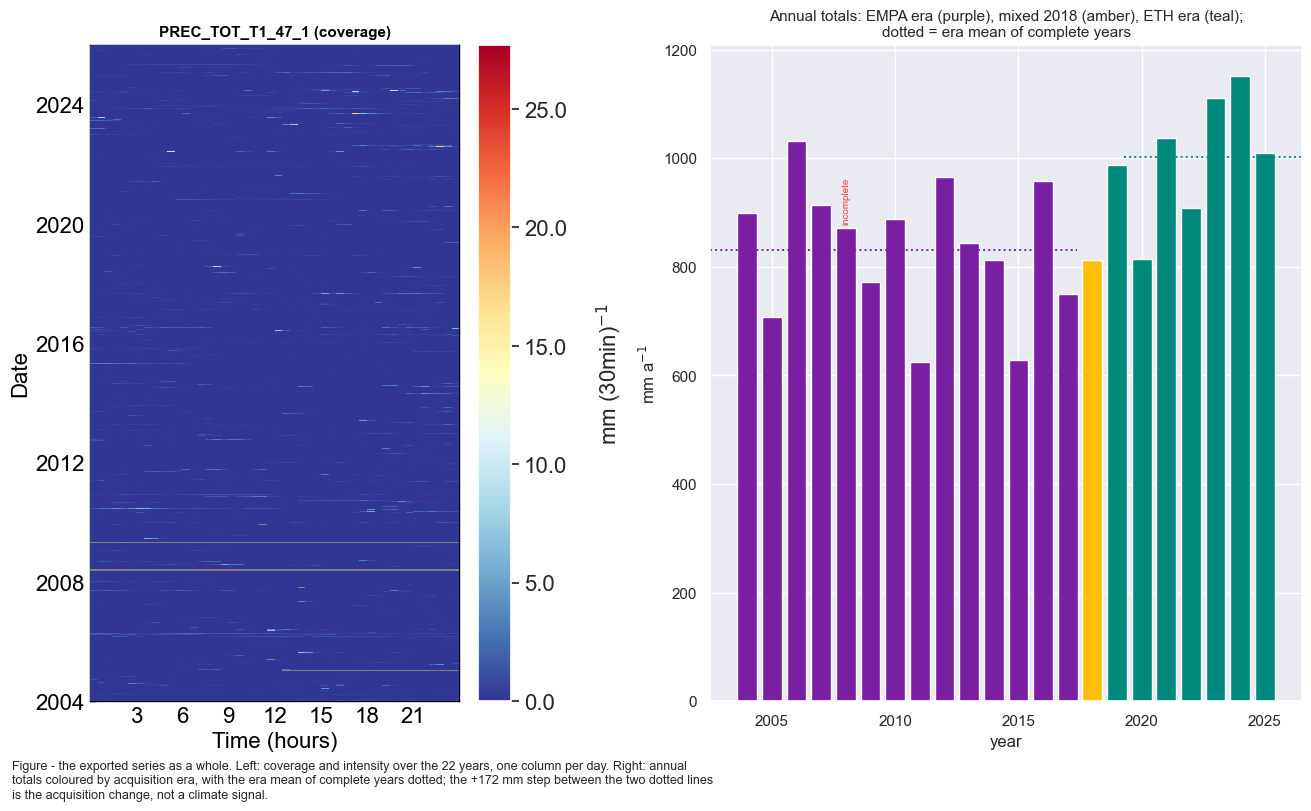

In [63]:
fig, axs = plt.subplots(ncols=2, figsize=(13, 8), dpi=100, layout='constrained',
                        width_ratios=[1, 1.6])
dv.plotting.HeatmapDateTime(series=export_df[VALCOL]).plot(
    ax=axs[0], cb_digits_after_comma=1, zlabel='mm (30min)$^{-1}$',
    format_style=dv.plotting.FormatStyle(title=f'{VALCOL} (coverage)', title_fontsize=11))

_colors = ['#7B1FA2' if y < 2018 else ('#FFC107' if y == 2018 else '#00897B')
           for y in _stats.index]
axs[1].bar(_stats.index, _stats['total_mm'], color=_colors)
for _y in _stats.index[_stats['coverage_%'] <= 98]:
    axs[1].annotate('incomplete', (_y, _stats.loc[_y, 'total_mm']), textcoords='offset points',
                    xytext=(0, 4), ha='center', fontsize=7, color='#F44336', rotation=90)
axs[1].axhline(_mean_empa, xmax=.62, color='#7B1FA2', ls=':', lw=1.4)
axs[1].axhline(_mean_eth, xmin=.70, color='#00897B', ls=':', lw=1.4)
axs[1].set_ylabel('mm a$^{-1}$')
axs[1].set_xlabel('year')
axs[1].set_title('Annual totals: EMPA era (purple), mixed 2018 (amber), ETH era (teal);\n'
                 'dotted = era mean of complete years', fontsize=11)
figcap(fig, f'the exported series as a whole. Left: coverage and intensity over the 22 years, '
            f'one column per day. Right: annual totals coloured by acquisition era, with the era '
            f'mean of complete years dotted; the {_mean_eth - _mean_empa:+,.0f} mm step between '
            f'the two dotted lines is the acquisition change, not a climate signal.')

***

## 💾 Save to file

In [64]:
filepath = dv.save_parquet(filename=OUTNAME, data=export_df, outpath=OUTPATH)
# na_rep='' keeps a gap empty in the csv: read back, a missing record must not become 0 mm.
export_df.to_csv(Path(OUTPATH) / f"{OUTNAME}.csv", na_rep='')
print(f"Saved to: {filepath}")

> Saved file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODU
CTS\08_METEO_PREC_GAPFILLED_2004-2025.parquet (0.064 seconds).

Saved to: F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODUCTS\08_METEO_PREC_GAPFILLED_2004-2025.parquet


### Verify the written file

Reading the parquet back and checking it directly, rather than trusting the in-memory frame. For a
precipitation product the **total** is the number that must survive the round trip, and the `NaN`
count is the one that must not quietly become zeros.

In [65]:
_written = dv.load_parquet(filepath=str(Path(OUTPATH) / f"{OUTNAME}.parquet"))

print(f"columns:   {list(_written.columns)}")
print(f"index:     {_written.index[0]} -> {_written.index[-1]}  ({len(_written):,} records)")
print(f"measured:  {int(_written[VALCOL].notna().sum()):,} "
      f"({100 * _written[VALCOL].notna().mean():.2f}%)")
print(f"total:     {float(_written[VALCOL].sum()):,.1f} mm")
print(f"max:       {float(_written[VALCOL].max()):.1f} mm per 30 min")

assert list(_written.columns) == [VALCOL, HOMOGCOL, FLAGCOL, FILLCOL], \
    "unexpected columns in the written file"
assert len(_written) == len(export_df), "record count changed on write"
assert _written[VALCOL].notna().sum() == export_df[VALCOL].notna().sum(), \
    "measured count changed on write - gaps may have become zeros"
assert abs(float(_written[VALCOL].sum()) - float(export_df[VALCOL].sum())) < 1e-6, \
    "total precipitation changed on write"
assert _written[FLAGCOL].equals(export_df[FLAGCOL]), "the source flag changed on write"
assert _written[FILLCOL].equals(export_df[FILLCOL]), "the fill flag changed on write"
assert abs(float(_written[HOMOGCOL].sum()) - float(export_df[HOMOGCOL].sum())) < 1e-6, \
    "the homogenised total changed on write"
print("\nWritten parquet verified.")

# The csv round trip is the fragile one: timestamps become strings and empty fields could come
# back as 0.0 instead of NaN, which would turn every gap into a dry record.
_csv = pd.read_csv(Path(OUTPATH) / f"{OUTNAME}.csv", index_col=0, parse_dates=True)
assert len(_csv) == len(export_df), "csv: record count changed"
assert _csv[VALCOL].isna().sum() == export_df[VALCOL].isna().sum(), \
    "csv: NaN count changed - gaps may have become zeros"
assert abs(float(_csv[VALCOL].sum()) - float(export_df[VALCOL].sum())) < 1e-6, "csv: total changed"
print("Written csv verified (gaps preserved as empty, total unchanged).")

tabcap('annual totals read back out of the written parquet file, not out of the frame in '
       'memory. This is the last check that what left this notebook is what it computed.')
display(_written.groupby(_written.index.year)[VALCOL].sum().round(1)
        .rename('annual total [mm]'))

> Loaded .parquet file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODU
CTS\08_METEO_PREC_GAPFILLED_2004-2025.parquet (0.016 seconds).

columns:   ['PREC_TOT_T1_47_1', 'PREC_TOT_T1_47_1_HOMOGENIZED', 'FLAG_PREC_TOT_T1_47_1_SOURCE', 'FLAG_PREC_TOT_T1_47_1_ISFILLED']
index:     2004-01-01 00:15:00 -> 2025-12-31 23:45:00  (385,728 records)
measured:  383,504 (99.42%)
total:     19,497.0 mm
max:       27.7 mm per 30 min

Written parquet verified.


Written csv verified (gaps preserved as empty, total unchanged).
Table - annual totals read back out of the written parquet file, not out of the frame in memory.
This is the last check that what left this notebook is what it computed.



TIMESTAMP_MIDDLE
2004     898.9
2005     708.3
2006    1031.8
2007     913.7
2008     871.7
2009     771.3
2010     888.1
2011     624.3
2012     965.6
2013     843.1
2014     812.3
2015     628.3
2016     958.2
2017     749.9
2018     813.1
2019     988.3
2020     815.0
2021    1037.4
2022     907.6
2023    1110.2
2024    1151.1
2025    1008.8
Name: annual total [mm], dtype: float64

***

### 📝 Notes for downstream users

- **One gauge, two acquisition systems, a 1.3x step between them.** Same instrument throughout
  (Lambrecht `15188H`, s/n `5609520001`), moved from EMPA's acquisition to the ETH `CR1000` in
  mid-2018. Relative to the same reference the later era records 1.3x what the earlier one does;
  in raw annual totals that is 830 mm a⁻¹ against 1,000 mm a⁻¹.
  `FLAG_PREC_TOT_T1_47_1_SOURCE` cuts at the fieldbook dates: `source >= 3` is the ETH-logger
  series, `source == 1` is the EMPA era, `source == 2` is 71 unresolved transition days.
  **Do not compute a trend, a water balance or a multi-decadal anomaly from `PREC_TOT_T1_47_1`
  across the break** — use the homogenised column instead.
- **The early era is the wrong one, and by how much is known.** Against thirteen MeteoSwiss stations
  within 21 km the EMPA era reads low against every single one (ratios 0.74-0.91) while the ETH era
  agrees with the network (0.91-1.05). Against the ensemble's elevation gradient (+35 mm/100 m,
  expectation 1,112 mm a⁻¹ at 690 m) the EMPA era is 25% low and the ETH era 10% low — and ~10% is
  ordinary wind under-catch for an exposed ridge-top gauge. The 2018 rewiring fixed the
  measurement; it did not break it.
- **`PREC_TOT_T1_47_1_HOMOGENIZED`** scales the pre-break era onto the post-break level with twelve
  monthly factors (1.07-1.44; 1.21 overall), lifting the early mean annual from 830 to ~1,000 mm.
  It is a **derived estimate**: use it to cross the break, not as a measurement and not as an
  absolute calibration — both eras retain the tower's own ~10% under-catch, which is real and is
  deliberately not corrected.
- **Snow under-catch, both eras, and it is the least stable part of this record.** Winter catch
  ratios against OED are 0.57 (EMPA era) and 0.86 (ETH era). Solid precipitation is missed as it
  falls and part of it is released days later on melt, so winter sub-daily timing is unreliable and
  winter totals are biased low throughout. Nothing was removed for this: the values are real
  precipitation on the wrong timestamps, and deleting the melt-out dumps would deepen the deficit
  rather than fix it. The gauge is heated, but the heating has a poor history - **disconnected on
  8 August 2018**, the same day the gauge was rewired, still recorded inactive in January 2024, new
  transformer fitted in July 2024. Treat any winter comparison across those dates with care: the
  cold-day catch ratio varies more from one winter to the next than any of those events moves it
  (section 5️⃣), so the effect is real but cannot be dated, and no correction is applied for it.
  For anything sensitive to solid precipitation, restrict to a single winter or filter on air
  temperature rather than trusting a multi-year winter total.
- **`GAPFILLED` in the filename does not mean complete.** Unlike `01`-`03`, this product still
  contains `NaN`. The name records that gap-filling was applied, not that every gap was closed.
- **Partly gap-filled, and it is flagged.** 932 half-hours (0.24%) carry a value copied from OED and
  rescaled by a monthly factor; `FLAG_PREC_TOT_T1_47_1_ISFILLED == 1` marks them. They are good for
  totals (bias within ±2.2% at every gap length, median error ~14% on a two-week gap) and
  **not** good for sub-daily timing (FAR 0.24, POD 0.70). Filter them out for anything event-based; keep them for any sum.
- **Remaining gaps are `NaN`, not `0`.** 0.58% of records (2,224, all before Sep 2014) have no
  value and cannot get one — OED has no sub-daily data there. Filling them with zero biases every
  sum downwards. `FLAG_..._ISFILLED == 2` finds them.
- **Zeros are data.** 91% of records are exactly `0`. That is the correct value for "no rain", not
  a sentinel and not a fault.
- **Units are mm per 30 min**, on a 0.1 mm tipping-bucket grid (fills are rounded onto the same
  grid). To get a rate, divide by 0.5 h.
- **Nothing is modelled.** A filled value is another gauge's measurement rescaled, not a model
  estimate. There is no statistical or machine-learning gap-filling in this product.
- **OED is both the diagnostic and the fill source.** It is 3.8 km NNW at 428 m. For genuine tower
  measurements only, take `FLAG_..._ISFILLED == 0`. *Source: MeteoSwiss.*

**Still open**

- The **71 transition days** (`flag == 2`, 29 May - 7 Aug 2018) cannot be assigned to either era
  from 19 rain days. If the raw ETH logger files for 2018 are ever ingested, that window — and the
  whole Aug-Dec 2018 period — could be compared against the NABEL feed directly and settled.
- The longest recent gap, **2024-06-29 17:30 → 2024-07-01 13:30 (44.5 h)**, has no fieldbook entry
  within ±3 days.
- The fieldbook does not say *why* the EMPA-era values are low — whether a different bucket
  calibration, a different aggregation in the NABEL feed, or something else. The factor-of-ten
  logger error found in 2019 shows the scaling of this gauge has been got wrong before.
- **How much of the winter homogenisation factor is the heater rather than the chain** cannot be
  separated with what is on disk, because both changed on the same day. A heated era on the ETH
  logger would settle it: if the July 2024 transformer stays working, the winters after it are the
  first that isolate the chain change from the heating change, and by about 2030 there would be
  enough of them to refit the cold-season factors on their own.

***

## End of notebook.

In [66]:
NOTEBOOK_END = datetime.now()
_h, _rem = divmod(int((NOTEBOOK_END - NOTEBOOK_START).total_seconds()), 3600)
_m, _s = divmod(_rem, 60)

print(f"Started:  {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Finished: {NOTEBOOK_END.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Runtime:  {_h:02d}:{_m:02d}:{_s:02d} (hh:mm:ss)")

Started:  2026-07-30 00:09:46
Finished: 2026-07-30 00:12:25
Runtime:  00:02:38 (hh:mm:ss)
